<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Open_Microchip_Layout_Demonstrator_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# Open Microchip Layout Demonstrator
**Onri Jay Benally · September 11, 2026**

A two-metal crossing connects intended terminal memberships to generated geometry, independently extracted connections, and deliberately injected faults. Run the cells in order with a CPU runtime. The notebook writes its complete companion implementation, creates an isolated Python environment, and packages the resulting GDSII, configuration, reports, figures, and meshes.

**Execution scope of the distributed files.** The accompanying reference report contains executed offline results with 26 passing regression tests. The native PHIDL and GDSTK path is the default below and awaits its first run with package access. PyVista rendering and Colab browser interaction have separate pending status. Every generated report records the backend actually used.

The bounded rule profile follows Sections 7.2 and 8 of the attached manuscript, *Designing a Microchip with Open Source Tools* [1]. A complete PDK revision and compatible manufacturing deck have yet to be assigned. These results concern this crossing structure and the implemented predicates.

## 1. Control knobs

Conductor width and terminal coordinates change the physical layout. The terminals stay fixed across all fault cases; each intervention is derived independently from the selected baseline. The current topology supports a horizontal terminal pair A and a vertical terminal pair B on M1, with their intervals containing the crossing.

Keep the default low via cost for the five-case suite. A separate cost experiment explores legal detours without changing the suite's baseline. A 0.100 µm routing lattice reduces search size; the 0.005 µm construction grid governs final edges. These two grids have different roles.

`DEPENDENCY_LOCK_FILE` can point to the `environment.lock.txt` saved by an earlier accepted run. Assigning that path reuses the recorded package set. The default virtual environment isolates project packages from Colab's preloaded libraries and avoids kernel-restart dependencies.

In [1]:
"""Configure the crossing, the isolated runtime, and the optional inspection scene."""

# ---- Execution controls ----
BACKEND = "native"  # "native" uses PHIDL and GDSTK; "reference" is explicitly separate.
INSTALL_DEPENDENCIES = True
PROJECT_PYTHON_VERSION = "3.11"
ENABLE_PYVISTA = True
RUN_REGRESSION_TESTS = True
RUN_FRESH_PROCESS_REPLAY = True
DEPENDENCY_LOCK_FILE = ""  # Path to an earlier environment.lock.txt, or an empty string.
PROJECT_DIRECTORY = "open_microchip_project"
OUTPUT_DIRECTORY = "layout_outputs"

# ---- Physical geometry controls, in micrometres ----
WIRE_WIDTH_UM = 0.200
VIA_CUT_UM = 0.150
VIA_PAD_UM = 0.320
TERMINAL_PAD_UM = 0.320
CONSTRUCTION_GRID_UM = 0.005
ROUTING_STEP_UM = 0.100
ROUTING_WINDOW_UM = [-2.5, -2.5, 2.5, 2.5]
TERMINALS_UM = {
    "A_L": [-2.0, 0.0],
    "A_R": [2.0, 0.0],
    "B_B": [0.0, -2.0],
    "B_T": [0.0, 2.0],
}

# ---- Route preference controls ----
VIA_PENALTY = 0.250
BEND_PENALTY = 0.150
UPPER_LAYER_LENGTH_MULTIPLIER = 1.15
MAX_SPATIAL_NODES = 15000

# ---- Independent fault controls ----
CLEARANCE_SHIFT_UM = 0.100
EXPORT_SCALE_FACTOR = 2.0

# ---- Viewer controls ----
FIGURE_DPI = 250
VERTICAL_EXAGGERATION = 4.0
CLIP_Y_UM = 0.0
LAYER_VISIBILITY = {"M1": True, "VIA12": True, "M2": True}


## 2. Primer and measurable obligations

A net specifies intended electrical membership. For this design, the target terminal partition is

$$
\mathcal{P}_{\mathrm{intent}}=
\big\{\{A_L,A_R\},\{B_B,B_T\}\big\}.
$$

Here $\mathcal{P}_{\mathrm{intent}}$ denotes the set of required terminal groups. Extraction obtains a separate partition from physical metal and via cuts; equality of the two partitions requires every intended pair to connect and every unrelated pair to stay separate.

For a via side length $v$ and a conservative all-side enclosure $e$, the square-pad side length $p$ is

$$
p=v+2e=0.150+2(0.085)=0.320\;\mu\mathrm{m}.
$$

The physical layer map assigns M1 to 68/20, VIA12 to 68/44, and M2 to 69/20. Overlap between M1 and M2 supplies no interlayer edge by itself; an accepted cut must be covered by a conducting region on both layers.

The legal search graph filters finite-width wire footprints and both landing pads against the obstacle and local bounds. For a candidate route $P$, this implementation minimizes

$$
C(P)=\alpha\left[L_1(P)+\eta L_2(P)\right]
+\beta N_v(P)+\gamma N_b(P).
$$

The quantities $L_1$ and $L_2$ denote routed lengths on M1 and M2, $N_v$ counts transitions, and $N_b$ counts direction changes. The coefficients $\alpha$, $\beta$, and $\gamma$ control length, via, and bend preferences, respectively; $\eta=1.15$ supplies a declared M2 length preference without assigning material resistance. Only geometrically legal candidates enter this optimization. The preceding movement axis is part of the search state so that each bend receives its cost exactly once.

### Bounded numerical rules

| Rule | Implemented condition | Value |
| --- | --- | --- |
| m1.1 | M1 minimum width | 0.140 µm |
| m1.2 | Separate-region M1 spacing | 0.140 µm |
| m1.6 | M1 merged-region area | 0.083 µm² |
| via.1a | Selected AL square cut | 0.150 µm |
| via.2 | Via-cut spacing | 0.170 µm |
| via.4a | Basic M1 enclosure | 0.055 µm |
| via.5a | Conservative all-side stronger M1 enclosure | 0.085 µm |
| m2.1 | M2 minimum width | 0.140 µm |
| m2.2 | Separate-region M2 spacing | 0.140 µm |
| m2.4 | Selected P/AL basic M2 enclosure | 0.055 µm |
| m2.5 | Conservative all-side stronger M2 enclosure | 0.085 µm |
| m2.6 | M2 merged-region area | 0.0676 µm² |

The selected stronger enclosure condition in [1] is implemented conservatively on every side. Merged-region area, orthogonal chord width, and isotropic spacing are bounded definitions. Internal slots, wide-metal contexts, density, antenna rules, electrical parasitics, device recognition, and full process qualification require separate implementations or an accepted deck.

## 3. Inspectable companion files

The following cells write plain Python modules and dependency records from their complete contents. `layout_demo.py` owns the application; `reference_gds.py` provides an explicitly named reference writer and a separately implemented bounded reader. Native execution constructs actual PHIDL `Device` objects, exports their GDSII and ports, imports the cells into GDSTK, and streams out the final hierarchy.

The reference parser supports the BOUNDARY/SREF subset used here, including reference transforms. It rejects unsupported record types. Native readback is additionally checked with a fresh GDSTK library, so the reference parser is compared against the native reader for the same saved file.

In [2]:
from pathlib import Path

PROJECT_PATH = Path(PROJECT_DIRECTORY).resolve()
PROJECT_PATH.mkdir(parents=True, exist_ok=True)
print(f"Project directory: {PROJECT_PATH}")


Project directory: /content/open_microchip_project


In [3]:
%%writefile {PROJECT_PATH}/reference_gds.py
"""Read and write the bounded BOUNDARY/SREF subset used by this demonstrator.

This independent, offline reference codec supports rectangles or simple polygons,
translation, rotation, reflection, and magnification. It rejects unsupported
geometry elements instead of silently discarding them. PHIDL and GDSTK own the
native workflow; this codec provides separately labeled offline fixtures and an
additional byte-level readback check. Dimensions returned by the reader use um.
"""

from __future__ import annotations

import math
import struct
from pathlib import Path
from typing import Any

import numpy as np

FIXED_DATE = (2026, 9, 11, 0, 0, 0)


def _record(code: int, kind: int, payload: bytes = b"") -> bytes:
    """Pack an even-length GDSII record."""
    payload += b"\0" * (len(payload) % 2)
    return struct.pack(">HBB", len(payload) + 4, code, kind) + payload


def _real8(value: float) -> bytes:
    """Encode the GDSII sign, base-16 exponent, and 56-bit mantissa."""
    if value == 0:
        return bytes(8)
    sign = 0x80 if value < 0 else 0
    fraction = abs(float(value))
    exponent = 64
    while fraction >= 1:
        fraction /= 16
        exponent += 1
    while fraction < 1 / 16:
        fraction *= 16
        exponent -= 1
    if exponent < 0 or exponent > 127:
        raise ValueError("GDSII real exponent exceeds its representable range.")
    mantissa = int(round(fraction * 2**56))
    if mantissa == 2**56:
        mantissa //= 16
        exponent += 1
    return bytes([sign | exponent]) + mantissa.to_bytes(7, "big")


def _decode_real8(data: bytes) -> float:
    """Decode one GDSII eight-byte real."""
    if len(data) != 8:
        raise ValueError("An eight-byte real requires eight bytes.")
    if data == bytes(8):
        return 0.0
    sign = -1 if data[0] & 0x80 else 1
    return sign * (int.from_bytes(data[1:], "big") / 2**56) * 16.0 ** (
        (data[0] & 0x7F) - 64
    )


def _ascii(value: str) -> bytes:
    """Encode names and property values without ambiguous character replacement."""
    return value.encode("ascii")


def _property(attribute: int, value: str) -> bytes:
    """Pack a GDSII property pair."""
    return _record(0x2B, 2, struct.pack(">h", attribute)) + _record(
        0x2C, 6, _ascii(value)
    )


def write_reference_gds(
    spec: dict[str, Any], path: Path, unit_m: float, precision_m: float
) -> None:
    """Write a deterministic hierarchical fixture using the bounded codec.

    Args:
        spec: Leaf cells and top-level instances in micrometre user coordinates.
        path: Destination for a separately identified reference fixture.
        unit_m: Metres per numerical user unit.
        precision_m: Metres per database coordinate.
    """
    multiplier = unit_m / precision_m
    date = struct.pack(">12h", *(FIXED_DATE + FIXED_DATE))
    chunks = [
        _record(0x00, 2, struct.pack(">h", 600)),
        _record(0x01, 2, date),
        _record(0x02, 6, b"OPEN_LAYOUT_REFERENCE"),
        _record(0x03, 5, _real8(precision_m / unit_m) + _real8(precision_m)),
    ]
    for cell_name in sorted(spec["cells"]):
        cell = spec["cells"][cell_name]
        chunks.extend([_record(0x05, 2, date), _record(0x06, 6, _ascii(cell_name))])
        for index, poly in enumerate(cell["polygons"]):
            points = np.asarray(poly["points"], dtype=float)
            points = np.vstack((points, points[0]))
            coordinates = np.rint(points * multiplier).astype(np.int64)
            if np.any(np.abs(coordinates) > 2**31 - 1):
                raise ValueError("A layout coordinate exceeds the GDSII range.")
            chunks.extend([
                _record(0x08, 0),
                _record(0x0D, 2, struct.pack(">h", poly["layer"])),
                _record(0x0E, 2, struct.pack(">h", poly["datatype"])),
                _record(0x10, 3, coordinates.astype(">i4").tobytes()),
                _property(126, f"{cell_name}.p{index}"),
                _record(0x11, 0),
            ])
        chunks.append(_record(0x07, 0))
    chunks.extend([
        _record(0x05, 2, date),
        _record(0x06, 6, _ascii(spec["top_cell"])),
    ])
    for instance in spec["instances"]:
        chunks.extend([
            _record(0x0A, 0),
            _record(0x12, 6, _ascii(instance["cell"])),
        ])
        angle = float(instance.get("rotation_deg", 0.0))
        scale = float(instance.get("magnification", 1.0))
        reflected = bool(instance.get("x_reflection", False))
        if angle or scale != 1 or reflected:
            chunks.append(_record(0x1A, 1, struct.pack(">H", 0x8000 if reflected else 0)))
            if scale != 1:
                chunks.append(_record(0x1B, 5, _real8(scale)))
            if angle:
                chunks.append(_record(0x1C, 5, _real8(angle)))
        origin = np.rint(np.asarray(instance["origin_um"]) * multiplier).astype(">i4")
        chunks.extend([
            _record(0x10, 3, origin.tobytes()),
            _property(125, instance["id"]),
            _record(0x11, 0),
        ])
    chunks.extend([_record(0x07, 0), _record(0x04, 0)])
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(b"".join(chunks))


def read_reference_gds(path: Path, top_cell: str = "CROSSING") -> dict[str, Any]:
    """Parse a fresh byte stream and resolve supported hierarchy into polygons.

    Electrical net names and planned routes are absent from this interface.
    Unsupported element types raise an error, preserving bounded reader scope.
    """
    data = path.read_bytes()
    offset = 0
    cells: dict[str, list[dict[str, Any]]] = {}
    current_cell = None
    element = None
    attribute = None
    unit_m = precision_m = None
    ended = False
    harmless = {0x00, 0x01, 0x02, 0x05, 0x2F}
    while offset < len(data):
        if offset + 4 > len(data):
            raise ValueError("Truncated GDSII record header.")
        size, code, kind = struct.unpack(">HBB", data[offset:offset + 4])
        if size < 4 or size % 2 or offset + size > len(data):
            raise ValueError("Invalid GDSII record length.")
        payload = data[offset + 4:offset + size]
        offset += size
        if code == 0x03:
            database_in_user = _decode_real8(payload[:8])
            precision_m = _decode_real8(payload[8:16])
            unit_m = precision_m / database_in_user
        elif code == 0x06:
            current_cell = payload.rstrip(b"\0").decode("ascii")
            if current_cell in cells:
                raise ValueError("Duplicate cell name in GDSII.")
            cells[current_cell] = []
        elif code in (0x08, 0x0A):
            element = {"kind": "polygon" if code == 0x08 else "reference", "properties": {}}
        elif code in (0x09, 0x0B, 0x0C, 0x15, 0x2D):
            raise ValueError("The reference reader supports BOUNDARY and SREF only.")
        elif code == 0x0D:
            element["layer"] = struct.unpack(">h", payload)[0]
        elif code == 0x0E:
            element["datatype"] = struct.unpack(">h", payload)[0]
        elif code == 0x10:
            element["xy"] = np.frombuffer(payload, dtype=">i4").reshape(-1, 2).copy()
        elif code == 0x12:
            element["cell"] = payload.rstrip(b"\0").decode("ascii")
        elif code == 0x1A:
            flags = struct.unpack(">H", payload)[0]
            if flags & 0x0006:
                raise ValueError("Absolute-angle and absolute-scale flags exceed reader scope.")
            element["x_reflection"] = bool(flags & 0x8000)
        elif code == 0x1B:
            element["magnification"] = _decode_real8(payload)
        elif code == 0x1C:
            element["rotation_deg"] = _decode_real8(payload)
        elif code == 0x2B:
            attribute = struct.unpack(">h", payload)[0]
        elif code == 0x2C:
            element["properties"][attribute] = payload.rstrip(b"\0").decode("ascii")
        elif code == 0x11:
            if element is None or current_cell is None:
                raise ValueError("Element closure lacks an open element or cell.")
            cells[current_cell].append(element)
            element = None
        elif code == 0x07:
            current_cell = None
        elif code == 0x04:
            ended = True
        elif code in harmless:
            pass
        else:
            raise ValueError(f"Unsupported GDSII record 0x{code:02X}, type {kind}.")
    if ended is False or unit_m is None or top_cell not in cells:
        raise ValueError("Missing library termination, units, or requested top cell.")
    polygons: list[dict[str, Any]] = []
    hierarchy: list[dict[str, Any]] = []

    def walk(name: str, transform: np.ndarray, shift: np.ndarray, trail: tuple[str, ...]) -> None:
        """Expand one cell using accumulated affine transformations."""
        if name in trail:
            raise ValueError("Cyclic hierarchy exceeds reader scope.")
        for index, item in enumerate(cells[name]):
            if item["kind"] == "polygon":
                local = item["xy"][:-1].astype(float) * precision_m * 1e6
                points = local @ transform.T + shift
                polygon_id = item["properties"].get(126, f"{name}.p{index}")
                polygons.append({
                    "id": "/".join(trail + (name, polygon_id)),
                    "cell": name,
                    "layer": item["layer"],
                    "datatype": item["datatype"],
                    "points": np.round(points, 9).tolist(),
                })
            else:
                angle = math.radians(item.get("rotation_deg", 0.0))
                scale = item.get("magnification", 1.0)
                rotation = np.array([[math.cos(angle), -math.sin(angle)],
                                     [math.sin(angle), math.cos(angle)]])
                reflection = np.diag([1.0, -1.0 if item.get("x_reflection", False) else 1.0])
                local_transform = scale * rotation @ reflection
                origin = item["xy"][0].astype(float) * precision_m * 1e6
                instance_id = item["properties"].get(125, f"sref{index}")
                hierarchy.append({"parent": name, "instance_id": instance_id, "cell": item["cell"]})
                walk(item["cell"], transform @ local_transform,
                     shift + transform @ origin, trail + (name, instance_id))

    walk(top_cell, np.eye(2), np.zeros(2), ())
    referenced = {item["cell"] for objects in cells.values() for item in objects
                  if item["kind"] == "reference"}
    return {
        "top_cell": top_cell,
        "top_cells": sorted(set(cells) - referenced),
        "unit_m": unit_m,
        "precision_m": precision_m,
        "polygons": polygons,
        "cells": sorted(cells),
        "hierarchy": hierarchy,
        "reader": "independent-bounded-reference-codec",
    }


Writing /content/open_microchip_project/reference_gds.py


In [4]:
%%writefile {PROJECT_PATH}/layout_demo.py
"""Connect electrical intent to a checked two-metal crossing and controlled faults.

NetworkX owns intent and legal route search. The native backend constructs
reusable PHIDL cells, exchanges them as GDSII, and gives GDSTK ownership of the
final hierarchy. Independent polygon analysis determines continuity, geometric
rule outcomes, and stream-out integrity. A separate offline reference backend
supports local detector tests without impersonating PHIDL or GDSTK execution.
All dimensions use micrometres unless their field name specifies another unit.
"""

from __future__ import annotations

# ---- Control knobs ----
DEFAULT_CONFIG = {
    "schema_version": "1.0.0",
    "project": "Open Microchip Layout Demonstrator",
    "author": "Onri Jay Benally",
    "date": "2026-09-11",
    "backend": "native",
    "top_cell": "CROSSING",
    "unit_m": 1e-6,
    "precision_m": 1e-9,
    "geometry": {
        "grid_um": 0.005,
        "wire_width_um": 0.200,
        "via_cut_um": 0.150,
        "via_pad_um": 0.320,
        "terminal_pad_um": 0.320,
        "window_um": [-2.5, -2.5, 2.5, 2.5],
        "ports": {
            "A_L": {"xy_um": [-2.0, 0.0], "layer": "M1", "orientation_deg": 180},
            "A_R": {"xy_um": [2.0, 0.0], "layer": "M1", "orientation_deg": 0},
            "B_B": {"xy_um": [0.0, -2.0], "layer": "M1", "orientation_deg": 270},
            "B_T": {"xy_um": [0.0, 2.0], "layer": "M1", "orientation_deg": 90},
        },
    },
    "intent": {"A": ["A_L", "A_R"], "B": ["B_B", "B_T"]},
    "layers": {"M1": [68, 20], "VIA12": [68, 44], "M2": [69, 20]},
    "rules": {
        "profile_id": "manuscript-bounded-sky130-example-2026-09-11",
        "scope": "Ordinary metals; selected AL via outside areaid.mt; selected P/AL M2 enclosure.",
        "enclosure_policy": "Conservative 0.085 um enclosure on all four sides.",
        "pdk_revision": None,
        "compatible_deck": None,
        "process_qualification": "UNASSIGNED",
        "M1": {
            "width": {"id": "m1.1", "value": 0.140, "units": "um"},
            "spacing": {"id": "m1.2", "value": 0.140, "units": "um"},
            "area": {"id": "m1.6", "value": 0.083, "units": "um^2"},
            "basic_enclosure": {"id": "via.4a", "value": 0.055, "units": "um"},
            "strong_enclosure": {"id": "via.5a", "value": 0.085, "units": "um"},
        },
        "M2": {
            "width": {"id": "m2.1", "value": 0.140, "units": "um"},
            "spacing": {"id": "m2.2", "value": 0.140, "units": "um"},
            "area": {"id": "m2.6", "value": 0.0676, "units": "um^2"},
            "basic_enclosure": {"id": "m2.4", "value": 0.055, "units": "um"},
            "strong_enclosure": {"id": "m2.5", "value": 0.085, "units": "um"},
        },
        "VIA12": {
            "size": {"id": "via.1a", "value": 0.150, "units": "um"},
            "spacing": {"id": "via.2", "value": 0.170, "units": "um"},
        },
    },
    "routing": {
        "step_um": 0.100,
        "length_weight": 1.0,
        "upper_layer_length_multiplier": 1.15,
        "via_penalty": 0.250,
        "bend_penalty": 0.150,
        "max_spatial_nodes": 15000,
        "run_penalty_experiments": True,
        "require_two_vias_for_fault_suite": True,
    },
    "faults": {"via_shift_toward_crossing_um": 0.100, "export_scale_factor": 2.0},
    "display": {
        "dpi": 250,
        "figure_inches": [6.4, 6.4],
        "vertical_exaggeration": 4.0,
        "clip_y_um": 0.0,
        "interactive_backend": "html",
        "layer_visibility": {"M1": True, "VIA12": True, "M2": True},
    },
    "stack": {
        "provenance": "Entirely synthetic inspection stack; manuscript Table 16.",
        "M1": {"z0_um": 0.0, "thickness_um": 0.2},
        "VIA12": {"z0_um": 0.2, "thickness_um": 0.3},
        "M2": {"z0_um": 0.5, "thickness_um": 0.2},
    },
    "checks": {"linear_epsilon_um": 1e-8, "area_epsilon_um2": 1e-10},
    "provenance": {
        "basis_file": "Open_Source_Semiconductor_Microchip_Design.pdf",
        "basis_title": "Designing a Microchip with Open Source Tools",
        "basis_sha256": "da6d102c1debdfd011a97f913b1f14c58d8dc98d11f3cc4748390873cec6b7c5",
        "basis_sections": ["7.2", "8", "9", "11", "12.2"],
        "implementation_choices": "Terminal coordinates, routing lattice, costs, fault sizes, and test algorithms.",
    },
}

# ---- Imports and records ----
import argparse
import copy
import hashlib
import os
import importlib.metadata
import io
import itertools
import json
import math
import platform
import sys
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any

# Colab can export its inline backend through MPLBACKEND. This script runs in
# a separate interpreter and writes static report figures, so force a headless
# backend before Matplotlib reads environment configuration.
os.environ["MPLBACKEND"] = "Agg"
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import shapely
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Polygon as PolygonPatch
from shapely.geometry import GeometryCollection, LineString, Point, Polygon, box
from shapely.ops import nearest_points, unary_union

from reference_gds import read_reference_gds, write_reference_gds


@dataclass
class Region:
    """One connected same-layer metal region with originating polygon IDs."""

    id: str
    role: str
    polygon: Polygon
    members: list[str]


@dataclass
class Analysis:
    """Geometry-derived regions, connectivity, and geometric measurements."""

    polygons: list[dict[str, Any]]
    regions: list[Region]
    graph: nx.Graph
    report: dict[str, Any]


def json_hash(value: Any) -> str:
    """Hash a canonical JSON representation."""
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(",", ":"),
                                     allow_nan=False).encode()).hexdigest()


def file_hash(path: Path) -> str:
    """Return the SHA-256 checksum of a file."""
    return hashlib.sha256(path.read_bytes()).hexdigest()


def save_json(path: Path, value: Any) -> None:
    """Write readable UTF-8 JSON without accepting NaN or infinity."""
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, indent=2, sort_keys=True, allow_nan=False) + "\n",
                    encoding="utf-8")


def validate_config(config: dict[str, Any]) -> None:
    """Reject unsupported topology, illegal construction coordinates, and resource risks."""
    geometry = config["geometry"]
    routing = config["routing"]
    grid = geometry["grid_um"]
    epsilon = config["checks"]["linear_epsilon_um"]
    if config["backend"] not in {"native", "reference"}:
        raise ValueError("Select native or reference backend explicitly.")
    if config["unit_m"] != 1e-6 or config["precision_m"] != 1e-9:
        raise ValueError("The design coordinate schema uses um with 1 nm database precision.")
    if grid <= 0 or routing["step_um"] < grid:
        raise ValueError("Grid and routing step must be positive and ordered.")
    for name in ("wire_width_um", "via_cut_um", "via_pad_um", "terminal_pad_um"):
        value = geometry[name]
        if value <= 0 or abs(value / (2 * grid) - round(value / (2 * grid))) > epsilon:
            raise ValueError(f"{name} must be a positive multiple of twice the construction grid.")
    if abs(routing["step_um"] / grid - round(routing["step_um"] / grid)) > epsilon:
        raise ValueError("Routing step must be a multiple of the construction grid.")
    for name in ("length_weight", "via_penalty", "bend_penalty"):
        if routing[name] < 0:
            raise ValueError(f"{name} must be nonnegative.")
    if routing["length_weight"] <= 0 or routing["upper_layer_length_multiplier"] < 1:
        raise ValueError("Positive length cost and an upper-layer multiplier >= 1 are required.")
    ports = geometry["ports"]
    left, right, bottom, top = [ports[name]["xy_um"] for name in ("A_L", "A_R", "B_B", "B_T")]
    if left[1] != right[1] or bottom[0] != top[0]:
        raise ValueError("The bounded topology requires horizontal A terminals and vertical B terminals.")
    if (left[0] < bottom[0] < right[0] and bottom[1] < left[1] < top[1]) is False:
        raise ValueError("Terminal intervals must contain their intended crossing.")
    window = box(*geometry["window_um"])
    for name, port in ports.items():
        if port["layer"] != "M1":
            raise ValueError("The bounded terminal interface uses M1.")
        point = np.asarray(port["xy_um"], dtype=float)
        if not bool(np.isfinite(point).all()):
            raise ValueError("Terminal coordinates must be finite.")
        for step in (grid, routing["step_um"]):
            if np.max(np.abs(point / step - np.rint(point / step))) > epsilon:
                raise ValueError(f"Terminal {name} must lie on the construction and routing grids.")
        half = geometry["terminal_pad_um"] / 2
        if window.covers(box(point[0] - half, point[1] - half,
                             point[0] + half, point[1] + half)) is False:
            raise ValueError(f"Terminal {name} extends beyond the routing window.")
    members = sorted(itertools.chain.from_iterable(config["intent"].values()))
    if members != sorted(ports):
        raise ValueError("Every terminal must belong to exactly one intended net.")
    if config["intent"] != {"A": ["A_L", "A_R"], "B": ["B_B", "B_T"]}:
        raise ValueError("The bounded fault suite requires the declared A and B terminal pairs.")
    if geometry["via_cut_um"] != config["rules"]["VIA12"]["size"]["value"]:
        raise ValueError("Via cut control disagrees with the selected rule profile.")
    if config["display"]["vertical_exaggeration"] <= 0:
        raise ValueError("Vertical exaggeration must be positive.")
    if config["faults"]["via_shift_toward_crossing_um"] <= 0:
        raise ValueError("Clearance-fault displacement must be positive.")
    if config["faults"]["export_scale_factor"] <= 0 or config["faults"]["export_scale_factor"] == 1:
        raise ValueError("A scale fault requires a positive factor different from one.")
    for name, interval in config["stack"].items():
        if isinstance(interval, dict) and interval["thickness_um"] <= 0:
            raise ValueError(f"{name} needs a positive display thickness.")
    if config["rules"]["pdk_revision"] or config["rules"]["compatible_deck"]:
        raise ValueError("This implementation executes bounded predicates only; a PDK needs a separate adapter.")


def make_intent_graph(config: dict[str, Any]) -> nx.Graph:
    """Build pin-to-net membership independently of geometric extraction."""
    graph = nx.Graph()
    for name, members in config["intent"].items():
        graph.add_node(f"net:{name}", kind="net", bipartite=1)
        for pin in members:
            graph.add_node(pin, kind="pin", bipartite=0,
                           xy_um=config["geometry"]["ports"][pin]["xy_um"])
            graph.add_edge(f"net:{name}", pin)
    return graph


def _segment_box(start: tuple[float, float], end: tuple[float, float], width: float) -> Polygon:
    """Construct a finite-width Manhattan segment with flat end faces."""
    x0, y0 = start
    x1, y1 = end
    half = width / 2
    if abs(y1 - y0) < 1e-10:
        return box(min(x0, x1), y0 - half, max(x0, x1), y0 + half)
    if abs(x1 - x0) < 1e-10:
        return box(x0 - half, min(y0, y1), x0 + half, max(y0, y1))
    raise ValueError("Only Manhattan segments are supported.")


def fixed_net_geometry(config: dict[str, Any]) -> Polygon:
    """Construct the fixed B conductor used as a routing obstacle."""
    geometry = config["geometry"]
    bottom = geometry["ports"]["B_B"]["xy_um"]
    top = geometry["ports"]["B_T"]["xy_um"]
    half = geometry["terminal_pad_um"] / 2
    pieces = [_segment_box(tuple(bottom), tuple(top), geometry["wire_width_um"])]
    for x, y in (bottom, top):
        pieces.append(box(x - half, y - half, x + half, y + half))
    return unary_union(pieces)


def build_route_graph(config: dict[str, Any]) -> tuple[nx.DiGraph, dict[str, Any]]:
    """Filter legal motion and augment state so bend costs have edge-local meaning.

    States carry (ix, iy, phase, previous_axis). Phase zero denotes M1 ahead
    of the first via, phase one denotes M2, and phase two denotes M1 after
    the return via. Two separated via banks bound possible transitions and
    guarantee via-to-via clearance in this small topology. An all-M1 detour
    is also permitted. State expansion prevents a bend penalty from being
    incorrectly attached to a coordinate-only edge.
    """
    geometry = config["geometry"]
    routing = config["routing"]
    step = routing["step_um"]
    width = geometry["wire_width_um"]
    wire_half = width / 2
    pad_half = geometry["via_pad_um"] / 2
    spacing = config["rules"]["M1"]["spacing"]["value"]
    epsilon = config["checks"]["linear_epsilon_um"]
    xmin, ymin, xmax, ymax = geometry["window_um"]
    indices_x = range(math.ceil((xmin + wire_half) / step - epsilon), math.floor((xmax - wire_half) / step + epsilon) + 1)
    indices_y = range(math.ceil((ymin + wire_half) / step - epsilon), math.floor((ymax - wire_half) / step + epsilon) + 1)
    if len(indices_x) * len(indices_y) * 3 > routing["max_spatial_nodes"]:
        raise ValueError("Routing domain exceeds max_spatial_nodes; enlarge the step or reduce the window.")
    obstacle = fixed_net_geometry(config)
    window = box(xmin, ymin, xmax, ymax)
    crossing_x = geometry["ports"]["B_B"]["xy_um"][0]
    bank_distance = pad_half + wire_half + spacing
    minimum_cut_gap = 2 * bank_distance - geometry["via_cut_um"]
    if minimum_cut_gap + epsilon < config["rules"]["VIA12"]["spacing"]["value"]:
        raise ValueError("Separated via banks fail the configured cut-spacing requirement.")
    legal_m1: set[tuple[int, int]] = set()
    legal_m2: set[tuple[int, int]] = set()
    legal_vias: set[tuple[int, int]] = set()
    for ix in indices_x:
        for iy in indices_y:
            x, y = round(ix * step, 9), round(iy * step, 9)
            square = box(x - wire_half, y - wire_half, x + wire_half, y + wire_half)
            if window.covers(square):
                legal_m2.add((ix, iy))
                if square.distance(obstacle) + epsilon >= spacing:
                    legal_m1.add((ix, iy))
            pad = box(x - pad_half, y - pad_half, x + pad_half, y + pad_half)
            if window.covers(pad) and pad.distance(obstacle) + epsilon >= spacing:
                legal_vias.add((ix, iy))
    graph = nx.DiGraph()
    for phase in (0, 1, 2):
        legal = legal_m2 if phase == 1 else legal_m1
        for ix, iy in sorted(legal):
            for previous in (0, 1, 2):
                state = (ix, iy, phase, previous)
                graph.add_node(state)
                for dx, dy, axis in ((1, 0, 1), (-1, 0, 1), (0, 1, 2), (0, -1, 2)):
                    if (ix + dx, iy + dy) not in legal:
                        continue
                    # Whole swept segment legality supplements endpoint checks.
                    segment = _segment_box((round(ix * step, 9), round(iy * step, 9)),
                                           (round((ix + dx) * step, 9), round((iy + dy) * step, 9)), width)
                    if window.covers(segment) is False:
                        continue
                    if phase != 1 and segment.distance(obstacle) + epsilon < spacing:
                        continue
                    bend = int(previous != 0 and previous != axis)
                    graph.add_edge(state, (ix + dx, iy + dy, phase, axis),
                                   length_um=step, upper_length_um=step if phase == 1 else 0.0,
                                   via_count=0, bend_count=bend)
                if (ix, iy) in legal_vias:
                    x = ix * step
                    if phase == 0 and x <= crossing_x - bank_distance + epsilon:
                        graph.add_edge(state, (ix, iy, 1, previous), length_um=0.0,
                                       upper_length_um=0.0, via_count=1, bend_count=0)
                    elif phase == 1 and x >= crossing_x + bank_distance - epsilon:
                        graph.add_edge(state, (ix, iy, 2, previous), length_um=0.0,
                                       upper_length_um=0.0, via_count=1, bend_count=0)
    source_xy = geometry["ports"]["A_L"]["xy_um"]
    target_xy = geometry["ports"]["A_R"]["xy_um"]
    source = (round(source_xy[0] / step), round(source_xy[1] / step), 0, 0)
    target_index = (round(target_xy[0] / step), round(target_xy[1] / step))
    sink = "sink"
    if source not in graph:
        raise ValueError("A_L lacks a legal finite-width escape from its terminal.")
    for phase in (0, 2):
        for axis in (1, 2):
            node = (*target_index, phase, axis)
            if node in graph:
                graph.add_edge(node, sink, length_um=0.0, upper_length_um=0.0,
                               via_count=0, bend_count=0)
    return graph, {
        "source": source, "sink": sink, "step_um": step,
        "spatial_nodes": len(legal_m1) * 2 + len(legal_m2),
        "state_nodes": graph.number_of_nodes(), "state_edges": graph.number_of_edges(),
        "minimum_via_bank_separation_um": 2 * bank_distance,
        "topology_scope": "One fixed vertical M1 obstacle, a single M2 excursion, or an M1 detour.",
    }


def solve_route(graph: nx.DiGraph, meta: dict[str, Any], costs: dict[str, Any]) -> dict[str, Any]:
    """Select a minimum-cost route within the already filtered finite graph."""
    def weight(_u: Any, _v: Any, edge: dict[str, Any]) -> float:
        """Evaluate a nonnegative additive length, via, and bend cost."""
        length = edge["length_um"] + (costs["upper_layer_length_multiplier"] - 1) * edge["upper_length_um"]
        return (costs["length_weight"] * length + costs["via_penalty"] * edge["via_count"]
                + costs["bend_penalty"] * edge["bend_count"])

    try:
        path = nx.dijkstra_path(graph, meta["source"], meta["sink"], weight=weight)
    except nx.NetworkXNoPath as error:
        raise ValueError("The configured legal routing graph contains no terminal-to-terminal path.") from error
    measures = {key: 0.0 for key in ("length_um", "upper_length_um", "via_count", "bend_count")}
    cost = 0.0
    for u, v in zip(path[:-1], path[1:]):
        edge = graph[u][v]
        cost += weight(u, v, edge)
        for key in measures:
            measures[key] += edge[key]
    step = meta["step_um"]
    points = [[round(node[0] * step, 9), round(node[1] * step, 9),
               "M2" if node[2] == 1 else "M1"] for node in path[:-1]]
    # Retain every layer transition and every direction-changing coordinate.
    compact = [points[0]]
    for index in range(1, len(points) - 1):
        a, b, c = points[index - 1:index + 2]
        collinear = (a[2] == b[2] == c[2] and
                     (a[0] == b[0] == c[0] or a[1] == b[1] == c[1]))
        if collinear is False:
            compact.append(b)
    compact.append(points[-1])
    return {"points": compact, "cost": round(cost, 9),
            **{key: round(value, 9) for key, value in measures.items()},
            "cost_parameters": {key: costs[key] for key in ("length_weight",
                "upper_layer_length_multiplier", "via_penalty", "bend_penalty")}}

# ---- Reusable geometry and native library exchange ----
def rectangle_points(width: float, height: float) -> list[list[float]]:
    """Return a centered rectangular boundary with fixed vertex order."""
    x, y = width / 2, height / 2
    return [[-x, -y], [x, -y], [x, y], [-x, y]]


def make_spec(config: dict[str, Any], route: dict[str, Any]) -> dict[str, Any]:
    """Translate a route into reusable, port-bearing cell specifications."""
    geometry = config["geometry"]
    spec: dict[str, Any] = {"top_cell": config["top_cell"], "cells": {}, "instances": []}
    layers = config["layers"]

    def polygon(points: list[list[float]], role: str) -> dict[str, Any]:
        """Assign drawing purpose to a local cell polygon."""
        return {"points": points, "layer": layers[role][0], "datatype": layers[role][1]}

    def add_wire(identifier: str, start: list[Any], end: list[Any]) -> None:
        """Place a reusable horizontal cell with a possible 90-degree reference rotation."""
        length = round(abs(end[0] - start[0]) + abs(end[1] - start[1]), 9)
        if length <= 0:
            return
        role = start[2]
        name = f"W_{role}_{json_hash([length, geometry['wire_width_um']])[:10]}"
        if name not in spec["cells"]:
            width = geometry["wire_width_um"]
            spec["cells"][name] = {
                "kind": "wire", "parameters": {"length_um": length, "width_um": width, "role": role},
                "polygons": [polygon(rectangle_points(length, width), role)],
                "ports": {
                    "west": {"xy_um": [-length / 2, 0], "width_um": width, "orientation_deg": 180},
                    "east": {"xy_um": [length / 2, 0], "width_um": width, "orientation_deg": 0},
                },
            }
        spec["instances"].append({
            "id": identifier, "cell": name,
            "origin_um": [round((start[0] + end[0]) / 2, 9), round((start[1] + end[1]) / 2, 9)],
            "rotation_deg": 90 if start[0] == end[0] else 0,
        })

    cut = geometry["via_cut_um"]
    pad = geometry["via_pad_um"]
    if route["via_count"]:
        spec["cells"]["VIA12"] = {
            "kind": "via", "parameters": {"cut_um": cut, "pad_um": pad},
            "polygons": [polygon(rectangle_points(pad, pad), "M1"),
                         polygon(rectangle_points(pad, pad), "M2"),
                         polygon(rectangle_points(cut, cut), "VIA12")],
            "ports": {
                "M1": {"xy_um": [0, 0], "width_um": pad, "orientation_deg": 0},
                "M2": {"xy_um": [0, 0], "width_um": pad, "orientation_deg": 0},
            },
        }
    via_index = 0
    wire_index = 0
    for start, end in zip(route["points"][:-1], route["points"][1:]):
        if start[2] != end[2]:
            if start[:2] != end[:2]:
                raise ValueError("Layer transitions require coincident coordinates.")
            spec["instances"].append({"id": f"A_VIA_{via_index}", "cell": "VIA12",
                                      "origin_um": start[:2], "rotation_deg": 0})
            via_index += 1
        else:
            add_wire(f"A_WIRE_{wire_index}", start, end)
            wire_index += 1
    bottom = geometry["ports"]["B_B"]["xy_um"]
    top = geometry["ports"]["B_T"]["xy_um"]
    add_wire("B_WIRE_0", [*bottom, "M1"], [*top, "M1"])
    terminal_pad = geometry["terminal_pad_um"]
    spec["cells"]["TERMINAL_M1"] = {
        "kind": "terminal", "parameters": {"pad_um": terminal_pad},
        "polygons": [polygon(rectangle_points(terminal_pad, terminal_pad), "M1")],
        "ports": {"center": {"xy_um": [0, 0], "width_um": terminal_pad, "orientation_deg": 0}},
    }
    for name, port in sorted(geometry["ports"].items()):
        spec["instances"].append({"id": name, "cell": "TERMINAL_M1",
                                  "origin_um": port["xy_um"], "rotation_deg": 0})
    return spec


def spec_polygons(spec: dict[str, Any]) -> list[dict[str, Any]]:
    """Resolve a construction specification for the pre-export dimensional comparison."""
    records = []
    for instance in spec["instances"]:
        angle = math.radians(instance.get("rotation_deg", 0))
        rotation = np.array([[math.cos(angle), -math.sin(angle)],
                             [math.sin(angle), math.cos(angle)]])
        reflection = np.diag([1.0, -1.0 if instance.get("x_reflection", False) else 1.0])
        transform = instance.get("magnification", 1.0) * rotation @ reflection
        for index, polygon in enumerate(spec["cells"][instance["cell"]]["polygons"]):
            points = np.asarray(polygon["points"]) @ transform.T + np.asarray(instance["origin_um"])
            records.append({"id": f"{spec['top_cell']}/{instance['id']}/{instance['cell']}/{instance['cell']}.p{index}",
                            "cell": instance["cell"], "layer": polygon["layer"],
                            "datatype": polygon["datatype"], "points": np.round(points, 9).tolist()})
    return records


def inject_fault(baseline: dict[str, Any], case: str, config: dict[str, Any]) -> tuple[dict[str, Any], dict[str, Any]]:
    """Apply one identified intervention to an independent baseline copy."""
    spec = copy.deepcopy(baseline)
    change: dict[str, Any] = {"case": case, "intervention": "none", "affected_objects": []}
    first_via = next((item for item in spec["instances"] if item["id"] == "A_VIA_0"), None)
    if case == "open_connection":
        if first_via is None:
            raise ValueError("Open injection requires the bridged baseline.")
        cell = copy.deepcopy(spec["cells"]["VIA12"])
        layer = config["layers"]["VIA12"]
        cell["polygons"] = [polygon for polygon in cell["polygons"]
                            if [polygon["layer"], polygon["datatype"]] != layer]
        spec["cells"]["VIA12_OPEN"] = cell
        first_via["cell"] = "VIA12_OPEN"
        change.update(intervention="Remove the first via cut; retain both metal landing pads.",
                      affected_objects=["A_VIA_0/VIA12.p2"])
    elif case == "shorted_crossing":
        affected = []
        for instance in spec["instances"]:
            cell = spec["cells"][instance["cell"]]
            if cell["kind"] == "wire" and cell["parameters"]["role"] == "M2":
                name = instance["cell"] + "_M1FAULT"
                changed = copy.deepcopy(cell)
                changed["parameters"]["role"] = "M1"
                for polygon in changed["polygons"]:
                    polygon["layer"], polygon["datatype"] = config["layers"]["M1"]
                spec["cells"][name] = changed
                instance["cell"] = name
                affected.append(instance["id"])
        change.update(intervention="Change the upper bridge drawing layer to M1; retain vias and pads.",
                      affected_objects=affected)
    elif case == "via_clearance_fault":
        if first_via is None:
            raise ValueError("Clearance injection requires the bridged baseline.")
        prior = copy.deepcopy(first_via["origin_um"])
        first_via["origin_um"][0] = round(prior[0] + config["faults"]["via_shift_toward_crossing_um"], 9)
        change.update(intervention="Translate one complete via assembly toward B; all wire polygons stay fixed.",
                      affected_objects=["A_VIA_0"], prior_origin_um=prior,
                      new_origin_um=first_via["origin_um"])
    elif case == "export_integrity_fault":
        change.update(intervention="Scale only the diagnostic file's user unit and precision; preserve design coordinates.",
                      affected_objects=["GDSII/UNITS"], scale_factor=config["faults"]["export_scale_factor"])
    elif case != "baseline":
        raise ValueError(f"Unknown case {case}.")
    used = {instance["cell"] for instance in spec["instances"]}
    spec["cells"] = {name: cell for name, cell in spec["cells"].items() if name in used}
    return spec, change


def write_native_gds(spec: dict[str, Any], config: dict[str, Any], path: Path,
                     interchange: Path, scale: float = 1.0) -> dict[str, Any]:
    """Build PHIDL cells, exchange GDSII, and stream out the GDSTK-owned hierarchy."""
    try:
        import gdstk
        from phidl import Device
    except ImportError as error:
        raise RuntimeError("Native execution requires PHIDL, gdspy, and GDSTK. Run the installation cell.") from error
    wrapper = Device("PHIDL_BLOCKS")
    sidecar = {}
    for name in sorted(spec["cells"]):
        recipe = spec["cells"][name]
        device = Device(name)
        for polygon in recipe["polygons"]:
            device.add_polygon(polygon["points"], layer=(polygon["layer"], polygon["datatype"]))
        for port_name, port in recipe["ports"].items():
            device.add_port(name=port_name, midpoint=port["xy_um"], width=port["width_um"],
                            orientation=port["orientation_deg"])
        wrapper.add_ref(device)
        sidecar[name] = {
            "parameters": recipe["parameters"],
            "ports": {str(key): {"xy_um": value.midpoint.tolist(), "width_um": float(value.width),
                                 "orientation_deg": float(value.orientation)}
                      for key, value in device.ports.items()},
        }
    interchange.parent.mkdir(parents=True, exist_ok=True)
    wrapper.write_gds(str(interchange), unit=config["unit_m"], precision=config["precision_m"],
                      auto_rename=False, cellname="PHIDL_BLOCKS")
    save_json(interchange.with_suffix(".ports.json"), sidecar)
    imported = gdstk.read_gds(str(interchange), unit=config["unit_m"])
    imported_cells = {cell.name: cell for cell in imported.cells}
    library = gdstk.Library(name="OPEN_LAYOUT_NATIVE", unit=config["unit_m"], precision=config["precision_m"])
    for name in sorted(spec["cells"]):
        cell = imported_cells[name]
        for index, polygon in enumerate(cell.polygons):
            polygon.set_gds_property(126, f"{name}.p{index}")
        library.add(cell)
    top = library.new_cell(spec["top_cell"])
    for item in spec["instances"]:
        reference = gdstk.Reference(imported_cells[item["cell"]], origin=item["origin_um"],
                                    rotation=math.radians(item.get("rotation_deg", 0)),
                                    magnification=item.get("magnification", 1.0),
                                    x_reflection=item.get("x_reflection", False))
        reference.set_gds_property(125, item["id"])
        top.add(reference)
    # The physical scale fault changes serialization metadata only.
    library.unit *= scale
    library.precision *= scale
    library.write_gds(str(path), timestamp=datetime(2026, 9, 11))
    fresh = gdstk.read_gds(str(path))
    fresh_top = {cell.name: cell for cell in fresh.top_level()}[spec["top_cell"]]
    records = [{"id": f"native.p{index}", "cell": spec["top_cell"], "layer": polygon.layer,
                "datatype": polygon.datatype,
                "points": np.round(polygon.points * fresh.unit * 1e6, 9).tolist()}
               for index, polygon in enumerate(fresh_top.get_polygons())]
    return {"reader": "GDSTK-fresh-library", "unit_m": fresh.unit,
            "precision_m": fresh.precision, "top_cells": sorted(cell.name for cell in fresh.top_level()),
            "polygons": records,
            "interchange": str(interchange.name), "port_sidecar": str(interchange.with_suffix('.ports.json').name)}


# ---- Independent polygon measurements and connectivity ----
def role_from_pair(config: dict[str, Any], layer: int, datatype: int) -> str:
    """Resolve an allowed physical drawing layer without consulting net labels."""
    for role, pair in config["layers"].items():
        if pair == [layer, datatype]:
            return role
    return "UNKNOWN"


def _parts(geometry: Any) -> list[Polygon]:
    """Return polygon components without converting lower-dimensional contacts into metal."""
    if geometry.is_empty:
        return []
    if geometry.geom_type == "Polygon":
        return [geometry]
    if geometry.geom_type in {"MultiPolygon", "GeometryCollection"}:
        return [part for component in geometry.geoms for part in _parts(component)]
    return []


def metal_regions(polygons: list[dict[str, Any]], config: dict[str, Any]) -> list[Region]:
    """Union physical same-layer metal and preserve provenance for each resulting region."""
    regions = []
    for role in ("M1", "M2"):
        source = [(item["id"], Polygon(item["points"])) for item in polygons
                  if role_from_pair(config, item["layer"], item["datatype"]) == role]
        for identifier, polygon in source:
            if polygon.is_valid is False or polygon.area <= 0:
                raise ValueError(f"Invalid conductor boundary {identifier}.")
        merged = unary_union([shape for _, shape in source])
        for index, polygon in enumerate(sorted(_parts(merged), key=lambda part: (*part.bounds, part.area))):
            members = sorted(identifier for identifier, shape in source
                             if shape.intersection(polygon).area > config["checks"]["area_epsilon_um2"])
            regions.append(Region(f"{role}.R{index:03d}", role, polygon, members))
    return regions


def _line_parts(geometry: Any) -> list[LineString]:
    """Extract finite line segments from intersection results."""
    if geometry.is_empty:
        return []
    if geometry.geom_type == "LineString":
        return [geometry]
    if geometry.geom_type in {"MultiLineString", "GeometryCollection"}:
        return [line for part in geometry.geoms for line in _line_parts(part)]
    return []


def manhattan_width(polygon: Polygon) -> tuple[float, list[list[float]]]:
    """Measure minimum x/y chord width on all open coordinate slabs.

    This predicate is restricted to orthogonal polygons. It evaluates merged
    regions, including necks, instead of measuring a long wire's bounding box.
    Foundry-specific corner and projection exceptions are outside its scope.
    """
    rings = [np.asarray(polygon.exterior.coords)] + [np.asarray(ring.coords) for ring in polygon.interiors]
    for ring in rings:
        delta = np.diff(ring, axis=0)
        if np.any((np.abs(delta[:, 0]) > 1e-8) & (np.abs(delta[:, 1]) > 1e-8)):
            raise ValueError("Width predicate requires Manhattan polygons.")
    vertices = np.vstack(rings)
    xmin, ymin, xmax, ymax = polygon.bounds
    margin = max(xmax - xmin, ymax - ymin, 1.0)
    candidates = []
    for axis in (0, 1):
        coordinates = sorted(set(np.round(vertices[:, axis], 9)))
        for lower, upper in zip(coordinates[:-1], coordinates[1:]):
            if upper - lower < 1e-9:
                continue
            middle = (lower + upper) / 2
            line = (LineString([(middle, ymin - margin), (middle, ymax + margin)]) if axis == 0
                    else LineString([(xmin - margin, middle), (xmax + margin, middle)]))
            for segment in _line_parts(polygon.intersection(line)):
                if segment.length > 1e-9:
                    candidates.append((segment.length, [list(point) for point in segment.coords]))
    if len(candidates) == 0:
        return 0.0, []
    return min(candidates, key=lambda pair: pair[0])


def extract_connections(polygons: list[dict[str, Any]], regions: list[Region],
                        ports: dict[str, Any], config: dict[str, Any]) -> tuple[nx.Graph, dict[str, Any]]:
    """Infer contact from final polygons, then locate unlabelled terminal coordinates.

    M1/M2 overlap alone creates zero interlayer edges. A permitted VIA12 cut
    creates a contact edge only if one region on each metal covers the entire
    cut. Enclosure and cut-size rules are evaluated separately. Point-only
    same-layer contacts stay disconnected and receive a geometric warning.
    """
    graph = nx.Graph()
    area_tolerance = config["checks"]["area_epsilon_um2"]
    for region in regions:
        graph.add_node(region.id, kind="region", role=region.role)
    contacts = []
    for item in polygons:
        if role_from_pair(config, item["layer"], item["datatype"]) != "VIA12":
            continue
        cut = Polygon(item["points"])
        touch = {role: [region.id for region in regions if region.role == role
                       and cut.difference(region.polygon).area <= area_tolerance] for role in ("M1", "M2")}
        accepted = len(touch["M1"]) == len(touch["M2"]) == 1
        contacts.append({"via_id": item["id"], "contact_regions": touch,
                         "accepted": accepted, "xy_um": list(cut.centroid.coords[0])})
        if accepted:
            graph.add_node(item["id"], kind="via", role="VIA12")
            for role in ("M1", "M2"):
                graph.add_edge(item["id"], touch[role][0], kind="full_cut_coverage")
    terminal_regions = {}
    for name, port in sorted(ports.items()):
        point = Point(port["xy_um"])
        matches = [region.id for region in regions if region.role == port["layer"]
                   and region.polygon.covers(point)]
        terminal_regions[name] = matches
        graph.add_node(name, kind="terminal", xy_um=port["xy_um"])
        if len(matches) == 1:
            graph.add_edge(name, matches[0], kind="terminal_location")
    components = [sorted(component) for component in nx.connected_components(graph)]
    components.sort(key=lambda component: tuple(component))
    groups = sorted([sorted(set(component) & set(ports)) for component in components
                     if set(component) & set(ports)])
    floating = [component for component in components if (set(component) & set(ports)) == set()]
    return graph, {"terminal_groups": groups, "terminal_regions": terminal_regions,
                   "components": components, "floating_components": floating,
                   "conducting_component_count": len(components), "via_contacts": contacts,
                   "all_terminals_resolved": all(len(matches) == 1 for matches in terminal_regions.values())}


def compare_intent(extracted: dict[str, Any], intent_graph: nx.Graph) -> dict[str, Any]:
    """Compare extracted terminal partitions with independently declared memberships."""
    expected = {node.split(":", 1)[1]: sorted(intent_graph.neighbors(node))
                for node, attributes in intent_graph.nodes(data=True) if attributes["kind"] == "net"}
    groups = extracted["terminal_groups"]
    group_of = {pin: index for index, group in enumerate(groups) for pin in group}
    net_of = {pin: net for net, pins in expected.items() for pin in pins}
    opens = [{"net": net, "terminals": pins, "groups": [group_of.get(pin) for pin in pins]}
             for net, pins in expected.items()
             if len({group_of.get(pin) for pin in pins}) != 1 or any(
                 len(extracted["terminal_regions"].get(pin, [])) != 1 for pin in pins)]
    shorts = [{"terminals": group, "nets": sorted({net_of[pin] for pin in group})}
              for group in groups if len({net_of[pin] for pin in group}) > 1]
    passed = (groups == sorted(expected.values()) and extracted["all_terminals_resolved"]
              and len(extracted["floating_components"]) == 0)
    return {"passed": passed, "expected_groups": sorted(expected.values()),
            "opens": opens, "shorts": shorts,
            "floating_components": extracted["floating_components"]}


def check_geometry(polygons: list[dict[str, Any]], regions: list[Region],
                   config: dict[str, Any]) -> dict[str, Any]:
    """Evaluate the named, bounded predicates on finished drawing polygons.

    Spacing compares separate connected regions. Internal slots, wide-metal
    contexts, density, antenna rules, and process-qualified extraction require
    their own deck and lie outside this demonstrator's coverage.
    """
    records: list[dict[str, Any]] = []
    eps = config["checks"]["linear_epsilon_um"]
    area_eps = config["checks"]["area_epsilon_um2"]
    grid = config["geometry"]["grid_um"]
    window = box(*config["geometry"]["window_um"])

    def record(rule: str, measure: Any, limit: Any, units: str,
               passed: bool, objects: list[str], witness: Any = None,
               interpretation: str = "minimum") -> None:
        """Preserve a measured predicate, result, and geometry identifiers."""
        records.append({"rule_id": rule, "measured": measure, "limit": limit,
                        "units": units, "passed": bool(passed),
                        "object_ids": objects, "witness_um": witness,
                        "interpretation": interpretation})

    for item in polygons:
        points = np.asarray(item["points"], dtype=float)
        polygon = Polygon(points)
        identifier = item["id"]
        role = role_from_pair(config, item["layer"], item["datatype"])
        error = float(np.max(np.abs(points - np.rint(points / grid) * grid)))
        record("demo.grid", error, eps, "um", error <= eps, [identifier],
               interpretation=f"maximum residual on {grid:g} um grid")
        record("demo.layer", [item["layer"], item["datatype"]],
               list(config["layers"].values()), "layer/datatype", role != "UNKNOWN",
               [identifier], interpretation="allowed drawing purposes")
        record("demo.boundary", polygon.area, 0.0, "um^2",
               polygon.is_valid and polygon.area > 0, [identifier],
               interpretation="valid positive-area boundary")
        delta = np.diff(np.vstack([points, points[0]]), axis=0)
        diagonal = np.any((np.abs(delta[:, 0]) > eps) & (np.abs(delta[:, 1]) > eps))
        record("demo.manhattan", int(diagonal), 0, "boolean", not diagonal,
               [identifier], interpretation="orthogonal boundaries")
        outside = float(polygon.difference(window).area)
        record("demo.window", outside, area_eps, "um^2", outside <= area_eps,
               [identifier], interpretation="maximum area outside routing window")

    for region in regions:
        width, witness = manhattan_width(region.polygon)
        for name, value, mark in (("width", width, witness),
                                  ("area", float(region.polygon.area), None)):
            rule = config["rules"][region.role][name]
            tolerance = area_eps if name == "area" else eps
            record(rule["id"], value, rule["value"], rule["units"],
                   value + tolerance >= rule["value"],
                   [region.id, *region.members], mark)
    for a, b in itertools.combinations(regions, 2):
        if a.role != b.role:
            continue
        rule = config["rules"][a.role]["spacing"]
        distance = float(a.polygon.distance(b.polygon))
        witness = [list(point.coords)[0] for point in nearest_points(a.polygon, b.polygon)]
        record(rule["id"], distance, rule["value"], "um",
               distance + eps >= rule["value"], [a.id, b.id, *a.members, *b.members],
               witness, "isotropic distance between separate same-layer regions")

    cuts = [(item, Polygon(item["points"])) for item in polygons
            if role_from_pair(config, item["layer"], item["datatype"]) == "VIA12"]
    metal = {role: unary_union([region.polygon for region in regions if region.role == role])
             for role in ("M1", "M2")}
    for item, cut in cuts:
        xmin, ymin, xmax, ymax = cut.bounds
        side = config["rules"]["VIA12"]["size"]["value"]
        dimensions = [xmax - xmin, ymax - ymin]
        square = (max(abs(value - side) for value in dimensions) <= eps
                  and cut.symmetric_difference(box(*cut.bounds)).area <= area_eps)
        record("via.1a", dimensions, [side, side], "um", square, [item["id"]],
               interpretation="axis-aligned square cut under selected AL scope")
        for role in ("M1", "M2"):
            covered = cut.difference(metal[role]).area <= area_eps
            enclosure = float(cut.distance(metal[role].boundary)) if covered else 0.0
            for name in ("basic_enclosure", "strong_enclosure"):
                rule = config["rules"][role][name]
                value = rule["value"]
                expanded = box(xmin - value, ymin - value, xmax + value, ymax + value)
                missing = float(expanded.difference(metal[role]).area)
                touched = [region.id for region in regions if region.role == role
                           and region.polygon.intersects(expanded)]
                record(rule["id"], enclosure, value, "um", missing <= area_eps,
                       [item["id"], *touched], list(expanded.exterior.coords),
                       "all-side square expansion contained in same-layer metal")
                records[-1]["uncovered_expansion_area_um2"] = missing
    for (a, pa), (b, pb) in itertools.combinations(cuts, 2):
        rule = config["rules"]["VIA12"]["spacing"]
        distance = float(pa.distance(pb))
        record(rule["id"], distance, rule["value"], "um",
               distance + eps >= rule["value"], [a["id"], b["id"]],
               [list(point.coords)[0] for point in nearest_points(pa, pb)])
    failures = [item for item in records if item["passed"] is False]
    return {"passed": len(failures) == 0, "predicate_count": len(records),
            "failure_count": len(failures), "failures": failures, "measurements": records,
            "coverage": "Bounded Manhattan width, merged-region area, separate-region spacing, cut size/spacing, all-side enclosure, grid, layers, and window.",
            "process_deck_status": "UNASSIGNED"}


def analyze(polygons: list[dict[str, Any]], config: dict[str, Any],
            intent_graph: nx.Graph) -> Analysis:
    """Analyze geometry first and compare its extracted terminal partition afterward."""
    regions = metal_regions(polygons, config)
    geometry = check_geometry(polygons, regions, config)
    graph, extracted = extract_connections(polygons, regions, config["geometry"]["ports"], config)
    connectivity = compare_intent(extracted, intent_graph)
    return Analysis(polygons, regions, graph, {
        "geometry": geometry, "extraction": extracted, "connectivity": connectivity,
        "passed": geometry["passed"] and connectivity["passed"],
        "regions": [{"id": region.id, "layer": region.role,
                     "bounds_um": list(region.polygon.bounds),
                     "area_um2": float(region.polygon.area), "polygon_ids": region.members}
                    for region in regions]})


def layer_unions(polygons: list[dict[str, Any]]) -> dict[str, Any]:
    """Group occupied geometry by its actual layer/datatype pair."""
    pairs = sorted({(item["layer"], item["datatype"]) for item in polygons})
    return {f"{layer}/{datatype}": unary_union([
        Polygon(item["points"]) for item in polygons
        if item["layer"] == layer and item["datatype"] == datatype])
        for layer, datatype in pairs}


def geometry_snapshot(polygons: list[dict[str, Any]]) -> dict[str, Any]:
    """Record physical dimensions and a canonical 1 nm occupied-geometry digest."""
    unions = layer_unions(polygons)
    digest = hashlib.sha256()
    layers = {}
    for pair, merged in unions.items():
        canonical = shapely.normalize(shapely.set_precision(merged, 0.001))
        digest.update(pair.encode())
        digest.update(canonical.wkb)
        layers[pair] = {"bounds_um": list(merged.bounds), "area_um2": float(merged.area)}
    return {"geometry_sha256": digest.hexdigest(), "layers": layers,
            "polygon_count_diagnostic": len(polygons),
            "hash_quantization_um": 0.001}


def compare_readback(expected: list[dict[str, Any]], actual: dict[str, Any],
                     config: dict[str, Any]) -> dict[str, Any]:
    """Compare stream-out physical units and full per-layer occupied geometry."""
    a, b = layer_unions(expected), layer_unions(actual["polygons"])
    checks = []
    checks.append({"check": "top_cell", "passed": actual["top_cells"] == [config["top_cell"]],
                   "expected": [config["top_cell"]], "actual": actual["top_cells"]})
    for key in ("unit_m", "precision_m"):
        checks.append({"check": key, "expected": config[key], "actual": actual[key],
                       "passed": math.isclose(actual[key], config[key], rel_tol=1e-12, abs_tol=0)})
    checks.append({"check": "layer_purposes", "expected": sorted(a), "actual": sorted(b),
                   "passed": set(a) == set(b)})
    for pair in sorted(set(a) | set(b)):
        left = a.get(pair, GeometryCollection())
        right = b.get(pair, GeometryCollection())
        error = float(left.symmetric_difference(right).area)
        checks.append({"check": f"occupied_geometry:{pair}", "passed": error <= config["checks"]["area_epsilon_um2"],
                       "symmetric_difference_area_um2": error,
                       "expected_area_um2": float(left.area), "actual_area_um2": float(right.area),
                       "expected_bounds_um": list(left.bounds), "actual_bounds_um": list(right.bounds)})
    return {"passed": all(item["passed"] for item in checks), "checks": checks,
            "expected": geometry_snapshot(expected), "actual": geometry_snapshot(actual["polygons"]),
            "reader": actual["reader"],
            "interpretation": "Physical units and occupied polygons are acceptance predicates; polygon count is diagnostic."}


# ---- Monochrome inspection views ----
def configure_plots(config: dict[str, Any]) -> None:
    """Configure readable monochrome report figures at the declared resolution."""
    plt.rcParams.update({"figure.dpi": config["display"]["dpi"],
                         "savefig.dpi": config["display"]["dpi"],
                         "font.size": 10, "axes.titlesize": 13,
                         "axes.labelsize": 11, "text.color": "black",
                         "axes.edgecolor": "black", "axes.labelcolor": "black",
                         "xtick.color": "black", "ytick.color": "black",
                         "figure.facecolor": "white", "axes.facecolor": "white",
                         "savefig.facecolor": "white"})


def save_figure(figure: Any, path: Path) -> None:
    """Render an image in memory, save its bytes, and close its figure."""
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=plt.rcParams["savefig.dpi"],
                   bbox_inches=None if getattr(figure, "_fixed_canvas", False) else "tight",
                   pad_inches=0.15,
                   bbox_extra_artists=[axis.zaxis.label for axis in figure.axes
                                       if hasattr(axis, "zaxis")])
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(buffer.getvalue())
    plt.close(figure)


def plan_axes(config: dict[str, Any], title: str) -> tuple[Any, Any]:
    """Create a single plan-view figure with common limits and equal physical scale."""
    figure, axis = plt.subplots(figsize=config["display"]["figure_inches"])
    figure._fixed_canvas = True
    figure.subplots_adjust(left=0.12, right=0.97, bottom=0.20, top=0.90)
    xmin, ymin, xmax, ymax = config["geometry"]["window_um"]
    axis.set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect="equal",
             xlabel="x (µm)", ylabel="y (µm)", title=title)
    axis.grid(True, color="black", alpha=0.12, linewidth=0.5)
    return figure, axis


def draw_terminals(axis: Any, config: dict[str, Any]) -> None:
    """Label all fixed terminal locations using orientation-aware offsets."""
    for name, port in config["geometry"]["ports"].items():
        x, y = port["xy_um"]
        dx, dy = {"A_L": (-7, -16), "A_R": (7, -16),
                  "B_B": (16, -5), "B_T": (16, 5)}[name]
        axis.plot(x, y, marker="o", markersize=4, color="black", zorder=10)
        axis.annotate(name, (x, y), xytext=(dx, dy), textcoords="offset points",
                      ha="right" if dx < 0 else "left", va="center", fontsize=9,
                      bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.0})


def draw_polygons(axis: Any, polygons: list[dict[str, Any]], config: dict[str, Any],
                  alpha: float = 1.0) -> None:
    """Draw physical layer polygons using fills and hatches without net coloring."""
    for role in ("M1", "M2", "VIA12"):
        for item in polygons:
            if role_from_pair(config, item["layer"], item["datatype"]) != role:
                continue
            axis.add_patch(PolygonPatch(item["points"], closed=True,
                                        facecolor="black" if role == "VIA12" else "white",
                                        edgecolor="black", hatch="////" if role == "M2" else None,
                                        linewidth=0.8, alpha=alpha,
                                        zorder={"M1": 2, "M2": 3, "VIA12": 4}[role]))


def layer_legend(axis: Any) -> None:
    """Place the layer key outside the plan-view plotting area."""
    handles = [Patch(facecolor="white", edgecolor="black", label="M1 (68/20)"),
               Patch(facecolor="white", edgecolor="black", hatch="////", label="M2 (69/20)"),
               Patch(facecolor="black", edgecolor="black", label="VIA12 (68/44)")]
    axis.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.13),
                ncol=3, frameon=False, fontsize=8)


def make_plan_figures(config: dict[str, Any], intent: nx.Graph, route: dict[str, Any],
                      baseline: Analysis, cases: dict[str, Any], output: Path) -> list[str]:
    """Render independent intent, planned-route, polygon, and extracted-graph views."""
    paths = []
    figure, axis = plan_axes(config, "01  Intended terminal memberships")
    positions = {pin: config["geometry"]["ports"][pin]["xy_um"]
                 for pin in config["geometry"]["ports"]}
    positions.update({"net:A": [-1.0, 1.0], "net:B": [1.0, -1.0]})
    for a, b in intent.edges:
        pa, pb = positions[a], positions[b]
        axis.plot([pa[0], pb[0]], [pa[1], pb[1]], "k--", linewidth=1.1)
    for net in ("A", "B"):
        x, y = positions[f"net:{net}"]
        axis.plot(x, y, marker="s", markerfacecolor="white", markeredgecolor="black", markersize=11)
        axis.annotate(f"net {net}", (x, y), xytext=(0, 12), textcoords="offset points", ha="center")
    draw_terminals(axis, config)
    axis.text(0.5, -0.17, "Net-node positions are diagram anchors; only terminal coordinates are physical.",
              transform=axis.transAxes, ha="center", fontsize=8)
    save_figure(figure, output / "01_intent.png")
    paths.append("01_intent.png")

    figure, axis = plan_axes(config, "02  Legal route selected by NetworkX")
    points = route["points"]
    for a, b in zip(points[:-1], points[1:]):
        if a[2] != b[2]:
            axis.plot(a[0], a[1], marker="s", markerfacecolor="white", markeredgecolor="black", markersize=8)
        else:
            axis.plot([a[0], b[0]], [a[1], b[1]], color="black",
                      linestyle="--" if a[2] == "M2" else "-", linewidth=1.8)
    a, b = [config["geometry"]["ports"][name]["xy_um"] for name in ("B_B", "B_T")]
    axis.plot([a[0], b[0]], [a[1], b[1]], "k-", linewidth=1.8)
    draw_terminals(axis, config)
    axis.legend(handles=[Line2D([], [], color="black", label="M1 route"),
                         Line2D([], [], color="black", linestyle="--", label="M2 route"),
                         Line2D([], [], color="black", marker="s", markerfacecolor="white",
                                linestyle="none", label="Via transition")],
                loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False, fontsize=8)
    save_figure(figure, output / "02_route.png")
    paths.append("02_route.png")

    figure, axis = plan_axes(config, "03  Final GDSII polygons after readback")
    draw_polygons(axis, baseline.polygons, config)
    draw_terminals(axis, config)
    layer_legend(axis)
    save_figure(figure, output / "03_polygons.png")
    paths.append("03_polygons.png")

    figure, axis = plan_axes(config, "04  Connections extracted from physical geometry")
    draw_polygons(axis, baseline.polygons, config, alpha=0.32)
    region_positions = {}
    for region in baseline.regions:
        x, y = region.polygon.representative_point().coords[0]
        # Put the two central region nodes at different positions inside their metals.
        if region.role == "M1" and region.polygon.covers(Point(0, 0)):
            x = config["geometry"]["ports"]["B_B"]["xy_um"][0]
            y = (config["geometry"]["ports"]["A_L"]["xy_um"][1]
                 + config["geometry"]["ports"]["B_T"]["xy_um"][1]) / 2
        if region.role == "M2":
            candidate = (
                config["geometry"]["ports"]["B_B"]["xy_um"][0]
                + config["geometry"]["wire_width_um"],
                config["geometry"]["ports"]["A_L"]["xy_um"][1],
            )
            if region.polygon.covers(Point(candidate)):
                x, y = candidate
        region_positions[region.id] = (x, y)
        axis.plot(x, y, "ko", markersize=4)
        axis.annotate(region.id, (x, y), xytext=(6, 11), textcoords="offset points", fontsize=8,
                      bbox={"facecolor": "white", "edgecolor": "none", "pad": 1})
    for contact in baseline.report["extraction"]["via_contacts"]:
        if contact["accepted"]:
            point = contact["xy_um"]
            axis.plot(*point, marker="s", color="black", markersize=4)
            for identifier in itertools.chain.from_iterable(contact["contact_regions"].values()):
                x, y = region_positions[identifier]
                upper = identifier.startswith("M2.")
                if upper:
                    axis.plot([x, point[0]], [y, point[1]], color="white", linewidth=4, zorder=6)
                axis.plot([x, point[0]], [y, point[1]], "k:", linewidth=1.0,
                          zorder=7 if upper else 4)
    for pin, identifiers in baseline.report["extraction"]["terminal_regions"].items():
        for identifier in identifiers:
            a, b = config["geometry"]["ports"][pin]["xy_um"], region_positions[identifier]
            axis.plot([a[0], b[0]], [a[1], b[1]], "k:", linewidth=1)
    draw_terminals(axis, config)
    axis.text(0.5, -0.17, "Graph edges show inferred membership; their drawing is separate from wire geometry.",
              transform=axis.transAxes, ha="center", fontsize=8)
    save_figure(figure, output / "04_extracted.png")
    paths.append("04_extracted.png")

    for case, item in cases.items():
        if case == "baseline":
            continue
        analysis = item["imported"] if case == "export_integrity_fault" else item["analysis"]
        title = case.replace("_", " ").capitalize()
        figure, axis = plan_axes(config, title)
        if case == "export_integrity_fault":
            extent = np.asarray(config["geometry"]["window_um"]) * config["faults"]["export_scale_factor"]
            axis.set(xlim=(extent[0], extent[2]), ylim=(extent[1], extent[3]))
            expected = unary_union([Polygon(row["points"]) for row in item["analysis"].polygons])
            axis.add_patch(PolygonPatch(list(box(*expected.bounds).exterior.coords),
                                        facecolor="none", edgecolor="black", linestyle="--", linewidth=1.2))
        draw_polygons(axis, analysis.polygons, config)
        for failure in analysis.report["geometry"]["failures"]:
            mark = failure["witness_um"]
            if failure["rule_id"] == "m1.2" and mark:
                coordinates = np.asarray(mark)
                axis.plot(coordinates[:, 0], coordinates[:, 1], "k-", linewidth=3)
                midpoint = coordinates.mean(axis=0)
                axis.annotate(f"m1.2: {failure['measured']:.3f} < {failure['limit']:.3f} µm",
                              midpoint, xytext=(-1.8, -0.75), textcoords="data", fontsize=9,
                              arrowprops={"arrowstyle": "->", "color": "black"},
                              bbox={"facecolor": "white", "edgecolor": "black", "pad": 3})
        draw_terminals(axis, config)
        layer_legend(axis)
        if case == "export_integrity_fault":
            axis.text(0.5, 0.05, "Dashed box: expected bounds. Imported GDS uses 2× physical scale.",
                      transform=axis.transAxes, ha="center", fontsize=8,
                      bbox={"facecolor": "white", "edgecolor": "none"})
        name = f"case_{case}.png"
        save_figure(figure, output / name)
        paths.append(name)
    return paths


def polygon_prism(polygon: Polygon, z0: float, thickness: float) -> Any:
    """Extrude constrained planar triangles into a closed, hole-preserving Trimesh."""
    import trimesh

    triangles = _parts(shapely.constrained_delaunay_triangles(polygon))
    if abs(sum(triangle.area for triangle in triangles) - polygon.area) > 1e-9:
        raise ValueError("Constrained triangles disagree with the polygon area.")
    vertices: list[list[float]] = []
    indices: dict[tuple[float, float], int] = {}
    faces = []
    for triangle in triangles:
        face = []
        for point in list(triangle.exterior.coords)[:3]:
            key = tuple(round(value, 9) for value in point)
            if key not in indices:
                indices[key] = len(vertices)
                vertices.append(list(key))
            face.append(indices[key])
        faces.append(face)
    mesh = trimesh.creation.extrude_triangulation(np.asarray(vertices), np.asarray(faces), thickness)
    mesh.apply_translation([0.0, 0.0, z0])
    mesh.fix_normals(multibody=False)
    if not mesh.is_watertight or abs(mesh.volume - polygon.area * thickness) > 1e-8:
        raise ValueError("Inspection mesh fails closure or physical volume consistency.")
    return mesh


def mesh_layout(analysis: Analysis, config: dict[str, Any], output: Path) -> tuple[list[Any], dict[str, Any]]:
    """Build unscaled solids and preserve layout-to-mesh provenance in a sidecar."""
    output.mkdir(parents=True, exist_ok=True)
    solids = [(region.id, region.role, region.polygon, region.members) for region in analysis.regions]
    for item in analysis.polygons:
        if role_from_pair(config, item["layer"], item["datatype"]) == "VIA12":
            solids.append((item["id"], "VIA12", Polygon(item["points"]), [item["id"]]))
    meshes = []
    metadata = []
    for index, (identifier, role, polygon, members) in enumerate(solids):
        layer = config["stack"][role]
        mesh = polygon_prism(polygon, layer["z0_um"], layer["thickness_um"])
        name = f"solid_{index:02d}_{role}.ply"
        mesh.export(str(output / name))
        meshes.append({"mesh": mesh, "role": role, "id": identifier, "polygon": polygon})
        metadata.append({"id": identifier, "role": role, "origin_polygon_ids": members,
                         "file": name, "coordinate_units": "um", "display_scaled": False,
                         "watertight": bool(mesh.is_watertight), "volume_um3": float(mesh.volume),
                         "expected_volume_um3": float(polygon.area * layer["thickness_um"]),
                         "bounds_um": mesh.bounds.tolist(), "triangles": len(mesh.faces)})
    report = {"stack": config["stack"], "meshes": metadata,
              "geometry_sha256": geometry_snapshot(analysis.polygons)["geometry_sha256"],
              "physical_mesh_scale": 1.0, "passed": all(row["watertight"] for row in metadata)}
    save_json(output / "mesh_manifest.json", report)
    return meshes, report


def static_3d(meshes: list[Any], config: dict[str, Any], path: Path,
              exaggeration: float, clip: bool) -> None:
    """Render a monochrome orthographic mesh view with a declared height scale."""
    from mpl_toolkits.mplot3d.art3d import Line3DCollection, Poly3DCollection

    figure = plt.figure(figsize=(8.0, 6.3))
    axis = figure.add_subplot(111, projection="3d")
    points = []
    for solid in meshes:
        mesh = solid["mesh"]
        if clip:
            xmin, ymin, xmax, ymax = config["geometry"]["window_um"]
            polygon = solid["polygon"].intersection(box(xmin - 1, config["display"]["clip_y_um"],
                                                        xmax + 1, ymax + 1))
            candidates = _parts(polygon)
            layer = config["stack"][solid["role"]]
            display_meshes = [polygon_prism(part, layer["z0_um"], layer["thickness_um"])
                              for part in candidates if part.area > 1e-10]
        else:
            display_meshes = [mesh]
        for item in display_meshes:
            vertices = item.vertices.copy()
            vertices[:, 2] *= exaggeration
            points.append(vertices)
            axis.add_collection3d(Poly3DCollection(vertices[item.faces],
                facecolors="white", edgecolors="none",
                alpha=1.0, zsort="average"))
            edges = item.face_adjacency_edges[item.face_adjacency_angles > 1e-6]
            axis.add_collection3d(Line3DCollection(vertices[edges], colors="black", linewidths=0.7))
    cloud = np.vstack(points)
    xmin, ymin, xmax, ymax = config["geometry"]["window_um"]
    zmax = max(float(cloud[:, 2].max()), 0.7)
    axis.set(xlim=(xmin, xmax), ylim=(ymin, ymax), zlim=(0, zmax * 1.08),
             xlabel="x (µm)", ylabel="y (µm)", zlabel="display z (µm)")
    axis.set_box_aspect((xmax - xmin, ymax - ymin, zmax))
    axis.set_proj_type("ortho")
    axis.view_init(elev=26, azim=-58)
    axis.set_title(f"Synthetic stack | height scale {exaggeration:g}×" +
                   (f" | clipped at y = {config['display']['clip_y_um']:g} µm" if clip else ""), pad=15)
    for direction in (axis.xaxis, axis.yaxis, axis.zaxis):
        direction.pane.fill = False
        direction.pane.set_edgecolor("white")
    axis.grid(False)
    figure.text(0.5, 0.03, "Unscaled mesh files preserve the declared synthetic dimensions. Conductivity is checked separately.",
                ha="center", fontsize=8)
    save_figure(figure, path)


def cross_section(analysis: Analysis, config: dict[str, Any], path: Path) -> None:
    """Plot an x-z section that exposes both via contacts and the lower crossing."""
    xmin, ymin, xmax, ymax = config["geometry"]["window_um"]
    y = config["display"]["clip_y_um"]
    section = LineString([(xmin, y), (xmax, y)])
    figure, axis = plt.subplots(figsize=(9, 3.6))
    for item in analysis.polygons:
        role = role_from_pair(config, item["layer"], item["datatype"])
        layer = config["stack"][role]
        for line in _line_parts(Polygon(item["points"]).intersection(section)):
            a, _, b, _ = line.bounds
            z0 = layer["z0_um"]
            z1 = z0 + layer["thickness_um"]
            axis.add_patch(PolygonPatch([[a, z0], [b, z0], [b, z1], [a, z1]],
                                        facecolor="black" if role == "VIA12" else "white",
                                        edgecolor="black", hatch="////" if role == "M2" else None,
                                        linewidth=1))
    axis.set(xlim=(xmin, xmax), ylim=(-0.07, 0.82), xlabel="x (µm)", ylabel="model z (µm)",
             title=f"Synthetic x-z section at y = {y:g} µm | axes have independent display scales")
    axis.grid(True, color="black", alpha=0.10, linewidth=0.5)
    layer_legend(axis)
    save_figure(figure, path)


def pyvista_plotter(meshes: list[Any], config: dict[str, Any], clip: bool = True) -> Any:
    """Create an optional PyVista scene from checked unscaled meshes.

    This function has zero authority over the geometric or electrical result.
    Any backend failure can be handled by displaying the saved static figures.
    """
    import pyvista as pv

    plotter = pv.Plotter(notebook=False, off_screen=True, window_size=(1400, 1050))
    plotter.set_background("white")
    factor = config["display"]["vertical_exaggeration"]
    for solid in meshes:
        if not config["display"]["layer_visibility"].get(solid["role"], True):
            continue
        mesh = solid["mesh"]
        faces = np.column_stack([np.full(len(mesh.faces), 3), mesh.faces]).ravel()
        data = pv.PolyData(mesh.vertices.copy(), faces)
        data.points[:, 2] *= factor
        if clip:
            data = data.clip(normal=(0, 1, 0),
                             origin=(0, config["display"]["clip_y_um"], 0), invert=False)
        plotter.add_mesh(data, color="white", edge_color="black", show_edges=True,
                         line_width=1, name=solid["id"], lighting=False)
    plotter.add_text(f"Synthetic stack | z display = {factor:g} x z model | units: um",
                     color="black", font_size=11)
    plotter.show_bounds(color="black", xtitle="x (um)", ytitle="y (um)", ztitle="display z (um)")
    plotter.camera_position = "iso"
    plotter.enable_parallel_projection()
    return plotter


# ---- Acceptance, reports, and reproducible execution ----
def environment_record() -> dict[str, Any]:
    """Record installed package versions without treating absence as execution."""
    names = ("numpy", "scipy", "shapely", "networkx", "matplotlib", "trimesh", "gdstk",
             "gdspy", "phidl", "pyvista", "vtk", "nbformat", "pytest")
    versions = {}
    for name in names:
        try:
            versions[name] = importlib.metadata.version(name)
        except importlib.metadata.PackageNotFoundError:
            versions[name] = None
    return {"python": sys.version, "executable": sys.executable,
            "platform": platform.platform(), "packages": versions}


def case_acceptance(case: str, design: Analysis, imported: Analysis,
                    integrity: dict[str, Any]) -> bool:
    """Require the diagnostic signature assigned to each controlled intervention."""
    report = design.report
    connectivity = report["connectivity"]
    geometry = report["geometry"]
    if case == "baseline":
        return report["passed"] and imported.report["passed"] and integrity["passed"]
    if case == "open_connection":
        return (geometry["passed"] and len(connectivity["opens"]) == 1
                and connectivity["opens"][0]["net"] == "A" and len(connectivity["shorts"]) == 0
                and integrity["passed"] and imported.report["extraction"]["terminal_groups"] ==
                report["extraction"]["terminal_groups"])
    if case == "shorted_crossing":
        return (geometry["passed"] and report["extraction"]["terminal_groups"] ==
                [["A_L", "A_R", "B_B", "B_T"]] and len(connectivity["shorts"]) == 1
                and integrity["passed"] and imported.report["extraction"]["terminal_groups"] ==
                report["extraction"]["terminal_groups"])
    if case == "via_clearance_fault":
        return (connectivity["passed"] and {item["rule_id"] for item in geometry["failures"]} == {"m1.2"}
                and integrity["passed"] and imported.report["connectivity"]["passed"]
                and {item["rule_id"] for item in imported.report["geometry"]["failures"]} == {"m1.2"})
    if case == "export_integrity_fault":
        failed = {item["check"] for item in integrity["checks"] if item["passed"] is False}
        return report["passed"] and "unit_m" in failed and any(
            name.startswith("occupied_geometry:") for name in failed)
    raise ValueError(f"Unknown acceptance case {case}.")


def penalty_experiments(graph: nx.DiGraph, meta: dict[str, Any], config: dict[str, Any],
                        intent: nx.Graph) -> list[dict[str, Any]]:
    """Show the cost response within the same fixed legal graph and terminal interface."""
    experiments = [("default", 0.25, 0.15), ("high_via_cost", 4.0, 0.15),
                   ("low_bend_cost", 2.40, 0.0), ("higher_bend_cost", 2.40, 0.40)]
    results = []
    for name, via, bend in experiments:
        costs = copy.deepcopy(config["routing"])
        costs.update(via_penalty=via, bend_penalty=bend)
        route = solve_route(graph, meta, costs)
        physical = analyze(spec_polygons(make_spec(config, route)), config, intent)
        results.append({"experiment": name, "route": route,
                        "geometry_passed": physical.report["geometry"]["passed"],
                        "connectivity_passed": physical.report["connectivity"]["passed"],
                        "failed_rules": sorted({item["rule_id"] for item in physical.report["geometry"]["failures"]})})
    return results


def write_comparison_report(report: dict[str, Any], output: Path, figures: list[str]) -> None:
    """Write a standalone HTML record with embedded monochrome figures and case table."""
    import base64
    import html

    rows = []
    for case, data in report["cases"].items():
        groups = " | ".join(", ".join(group) for group in data["design"]["extraction"]["terminal_groups"])
        failures = ", ".join(sorted({item["rule_id"] for item in data["design"]["geometry"]["failures"]})) or "None"
        rows.append(f"<tr><td>{html.escape(case)}</td><td>{html.escape(groups)}</td>"
                    f"<td>{'PASS' if data['design']['connectivity']['passed'] else 'FAIL'}</td>"
                    f"<td>{'PASS' if data['design']['geometry']['passed'] else 'FAIL'} ({failures})</td>"
                    f"<td>{'PASS' if data['readback_integrity']['passed'] else 'FAIL'}</td>"
                    f"<td>{'PASS' if data['expectation_met'] else 'FAIL'}</td></tr>")
    images = []
    for name in figures:
        path = output / "figures" / name
        if path.exists():
            encoded = base64.b64encode(path.read_bytes()).decode("ascii")
            images.append(f'<figure><img alt="{html.escape(name)}" src="data:image/png;base64,{encoded}">'
                          f'<figcaption>{html.escape(name)}</figcaption></figure>')
    source_rules = report["config"]["rules"]
    native = report["execution"]["native_backend_executed"]
    scope = ("Native PHIDL and GDSTK geometry execution completed in this run."
             if native else "Reference-backend run. PHIDL and GDSTK execution is pending; this fixture reports the separately identified offline implementation.")
    penalties = "".join(f"<tr><td>{item['experiment']}</td><td>{item['route']['via_count']:g}</td>"
                        f"<td>{item['route']['bend_count']:g}</td><td>{item['route']['length_um']:g}</td>"
                        f"<td>{item['route']['cost']:g}</td><td>{item['geometry_passed'] and item['connectivity_passed']}</td></tr>"
                        for item in report["penalty_experiments"])
    document = f'''<!doctype html>
<html lang="en"><head><meta charset="utf-8"><title>Open Microchip Layout Demonstrator</title>
<style>body{{font:16px/1.55 system-ui,sans-serif;color:#000;background:#fff;max-width:1200px;margin:40px auto;padding:0 24px}}
h1{{font-size:32px;line-height:1.15}}h2{{margin-top:36px}}table{{border-collapse:collapse;width:100%;font-size:13px}}
th,td{{border-bottom:1px solid #888;text-align:left;vertical-align:top;padding:10px 8px}}th{{border-top:2px solid #000}}
.scope{{border:2px solid #000;padding:18px}}.views{{display:grid;grid-template-columns:1fr 1fr;gap:18px}}
figure{{margin:12px 0}}img{{max-width:100%;height:auto}}figcaption{{font-size:12px}}pre{{white-space:pre-wrap;overflow-wrap:anywhere;font-size:12px}}
@media(max-width:800px){{.views{{grid-template-columns:1fr}}table{{font-size:11px}}}}</style></head>
<body><p>ONRI JAY BENALLY · SEPTEMBER 11, 2026</p><h1>Open Microchip Layout Demonstrator</h1>
<div class="scope"><strong>Execution scope</strong><p>{scope}</p>
<p>All five expected case outcomes: <strong>{'PASS' if report['all_expectations_met'] else 'FAIL'}</strong>.
Full PDK check deck: {source_rules['process_qualification']}. Colab browser execution: separately pending unless recorded by that runtime.</p></div>
<h2>Controlled comparison</h2><p>The coordinates and intended terminal memberships are fixed across all cases. Each intervention starts from the same baseline. A failed layout is an accepted experiment only if its assigned detector produces the expected signature. The export case is judged by its physical readback, independently of its passing pre-serialization design.</p>
<table><thead><tr><th>Case</th><th>Design terminal groups</th><th>Connectivity</th><th>Geometry</th><th>Export integrity</th><th>Expected outcome</th></tr></thead><tbody>{''.join(rows)}</tbody></table>
<h2>Separate geometry and electrical checks</h2><p>Electrical extraction uses physical same-layer unions and full via-cut coverage on both conducting layers. Overlapping M1 and M2 alone produce zero interlayer edges. Geometric predicates evaluate the actual polygon coordinates without snapping defects away. Full process qualification, electrical parasitics, resistance, device recognition, internal-slot checks, and timing analysis are outside this bounded implementation.</p>
<h2>Routing cost experiment</h2><p>Each row searches the same legal graph. Finite wire width and landing-pad clearance filter candidate motion; cost changes affect route preference without relaxing those constraints.</p>
<table><thead><tr><th>Cost experiment</th><th>Vias</th><th>Bends</th><th>Length (µm)</th><th>Objective</th><th>Geometry and connectivity</th></tr></thead><tbody>{penalties}</tbody></table>
<h2>Aligned plan views and diagnostic figures</h2><div class="views">{''.join(images)}</div>
<h2>Provenance</h2><p>The numerical rule profile follows Sections 7.2 and 8 of <em>Designing a Microchip with Open Source Tools</em>, supplied as Open_Source_Semiconductor_Microchip_Design.pdf. The ownership model follows Section 9; the synthetic vertical stack follows Table 16. Terminal coordinates, route-search implementation, fault sizes, and test algorithms are implementation choices.</p>
<p>Configuration SHA-256: <code>{report['configuration_sha256']}</code></p>
<p>Generator SHA-256: <code>{report['generator_sha256']}</code></p>
<details><summary>Recorded environment</summary><pre>{html.escape(json.dumps(report['environment'], indent=2))}</pre></details>
<details><summary>Rule profile</summary><pre>{html.escape(json.dumps(source_rules, indent=2))}</pre></details>
<p>comparison_report.json and the per-case manifests contain every measured predicate, affected polygon identifier, and saved configuration.</p>
</body></html>'''
    (output / "comparison_report.html").write_text(document, encoding="utf-8")


def run_project(config: dict[str, Any], output: Path, make_figures: bool = True) -> dict[str, Any]:
    """Generate the bounded experiment, check all cases, and save traceable artifacts."""
    config = copy.deepcopy(config)
    validate_config(config)
    output.mkdir(parents=True, exist_ok=True)
    configure_plots(config)
    intent = make_intent_graph(config)
    graph, meta = build_route_graph(config)
    route = solve_route(graph, meta, config["routing"])
    if config["routing"]["require_two_vias_for_fault_suite"] and route["via_count"] != 2:
        raise ValueError("The five-case fault suite needs a two-via baseline. Use penalty experiments for detours.")
    specification = make_spec(config, route)
    baseline_precheck = analyze(spec_polygons(specification), config, intent)
    if baseline_precheck.report["passed"] is False:
        save_json(output / "baseline_rejected.json", baseline_precheck.report)
        raise ValueError("The proposed baseline fails its bounded predicates; see baseline_rejected.json.")
    manifest_config = output / "configuration.json"
    save_json(manifest_config, config)
    save_json(output / "route_plan.json", {"route": route, "graph": meta})
    save_json(output / "intent.json", {"nets": config["intent"], "ports": config["geometry"]["ports"]})
    cases: dict[str, Any] = {}
    native_executed = config["backend"] == "native"
    names = ("baseline", "open_connection", "shorted_crossing", "via_clearance_fault", "export_integrity_fault")
    for case in names:
        spec, intervention = inject_fault(specification, case, config)
        designed = analyze(spec_polygons(spec), config, intent)
        if case == "baseline":
            filename = "baseline.gds" if native_executed else "reference_baseline.gds"
        else:
            filename = f"diagnostic_FAILED_{case}.gds"
        path = output / ("_candidate_baseline.gds" if case == "baseline" else filename)
        scale = config["faults"]["export_scale_factor"] if case == "export_integrity_fault" else 1.0
        native_result = None
        if native_executed:
            native_result = write_native_gds(spec, config, path,
                                             output / "interchange" / f"{case}_phidl.gds", scale)
        else:
            write_reference_gds(spec, path, config["unit_m"] * scale, config["precision_m"] * scale)
        fresh = read_reference_gds(path, config["top_cell"])
        imported = analyze(fresh["polygons"], config, intent)
        integrity = compare_readback(designed.polygons, fresh, config)
        expected = case_acceptance(case, designed, imported, integrity)
        native_comparison = None
        if native_result is not None:
            native_comparison = compare_readback(fresh["polygons"], native_result,
                                                 {**config, "unit_m": fresh["unit_m"],
                                                  "precision_m": fresh["precision_m"]})
            expected = expected and native_comparison["passed"]
        if case == "baseline":
            if not expected:
                filename = "diagnostic_FAILED_baseline_readback.gds"
            final_path = output / filename
            path.replace(final_path)
            path = final_path
        case_report = {
            "case": case, "intervention": intervention, "configuration_sha256": json_hash(config),
            "config": config, "gds_file": filename, "gds_sha256": file_hash(path),
            "design": designed.report, "imported_analysis": imported.report,
            "readback_integrity": integrity, "native_reader_agreement": native_comparison,
            "expectation_met": bool(expected),
            "native_backend_executed": native_executed,
            "ports": config["geometry"]["ports"], "intent": config["intent"],
            "cell_specification": spec, "imported_hierarchy": fresh["hierarchy"],
        }
        save_json(output / "cases" / f"{case}.json", case_report)
        cases[case] = {"analysis": designed, "imported": imported, "report": case_report}
    experiments = penalty_experiments(graph, meta, config, intent) if config["routing"]["run_penalty_experiments"] else []
    report = {
        "project": config["project"], "author": config["author"], "config": config,
        "configuration_sha256": json_hash(config), "generator_sha256": file_hash(Path(__file__)),
        "reference_codec_sha256": file_hash(Path(__file__).with_name("reference_gds.py")),
        "execution": {"backend": config["backend"], "native_backend_executed": native_executed,
                      "hosted_colab_execution": "google.colab" in sys.modules,
                      "process_deck_executed": False,
                      "reader": "Independent bounded BOUNDARY/SREF reference parser"},
        "environment": environment_record(), "route": route, "graph": meta,
        "cases": {name: item["report"] for name, item in cases.items()},
        "penalty_experiments": experiments,
        "all_expectations_met": all(item["report"]["expectation_met"] for item in cases.values()),
    }
    figure_names: list[str] = []
    if make_figures:
        figure_names = make_plan_figures(config, intent, route, cases["baseline"]["imported"], cases,
                                         output / "figures")
        meshes, mesh_report = mesh_layout(cases["baseline"]["imported"], config, output / "meshes")
        report["mesh_checks"] = mesh_report
        for factor, clip, name in ((1.0, False, "05_stack_unscaled.png"),
                                   (config["display"]["vertical_exaggeration"], True, "06_stack_clipped.png")):
            static_3d(meshes, config, output / "figures" / name, factor, clip)
            figure_names.append(name)
        cross_section(cases["baseline"]["imported"], config, output / "figures" / "07_via_section.png")
        figure_names.append("07_via_section.png")
    save_json(output / "comparison_report.json", report)
    write_comparison_report(report, output, figure_names)
    if report["all_expectations_met"] is False:
        raise AssertionError("At least one injected defect lacks its required signature; inspect comparison_report.json.")
    for experiment in experiments:
        if not experiment["geometry_passed"] or not experiment["connectivity_passed"]:
            raise AssertionError("A route-cost experiment fails the independent physical checks.")
    return report


def main() -> None:
    """Run the saved configuration from the command line."""
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--config", type=Path, help="JSON configuration; defaults to native backend.")
    parser.add_argument("--backend", choices=("native", "reference"), help="Explicit backend override.")
    parser.add_argument("--output", type=Path, default=Path("layout_outputs"))
    parser.add_argument("--skip-figures", action="store_true")
    args = parser.parse_args()
    config = json.loads(args.config.read_text()) if args.config else copy.deepcopy(DEFAULT_CONFIG)
    if args.backend:
        config["backend"] = args.backend
    report = run_project(config, args.output, make_figures=not args.skip_figures)
    for case, result in report["cases"].items():
        print(f"{case:26s} expected outcome: {'PASS' if result['expectation_met'] else 'FAIL'}")
    print(f"Backend: {config['backend']} | Native executed: {report['execution']['native_backend_executed']}")
    print(f"Report: {args.output / 'comparison_report.html'}")


if __name__ == "__main__":
    main()


Writing /content/open_microchip_project/layout_demo.py


In [5]:
%%writefile {PROJECT_PATH}/render_pyvista.py
"""Export the checked synthetic stack as a PyVista HTML inspection scene.

The renderer consumes only the already checked baseline layout.  It creates a
PNG screenshot and a self-contained HTML scene.  Colab graphics setup is kept
outside the electrical and geometric checks, so viewer behavior cannot alter
layout acceptance.
"""

import argparse
import importlib.metadata
import json
import os
from pathlib import Path

# Set the headless policy before importing VTK/PyVista.
os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")

import layout_demo as demo


def main() -> None:
    """Read the checked baseline and export static plus interactive views."""
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--output", type=Path, default=Path("layout_outputs"))
    args = parser.parse_args()
    output = args.output

    config = json.loads((output / "configuration.json").read_text(encoding="utf-8"))
    record = json.loads(
        (output / "comparison_report.json").read_text(encoding="utf-8")
    )
    baseline = record["cases"]["baseline"]
    path = output / baseline["gds_file"]

    if demo.file_hash(path) != baseline["gds_sha256"]:
        raise ValueError(
            "The baseline checksum differs from its recorded checked layout."
        )

    fresh = demo.read_reference_gds(path, config["top_cell"])
    analysis = demo.analyze(
        fresh["polygons"],
        config,
        demo.make_intent_graph(config),
    )
    if analysis.report["passed"] is False:
        raise ValueError("The baseline fails independent checks; rendering stopped.")

    meshes, _ = demo.mesh_layout(analysis, config, output / "meshes")

    # PyVista 0.46.x uses nest_asyncio when export_html() launches its Trame
    # server from a synchronous Python process.  Apply the loop patch directly
    # so the export path is deterministic instead of relying on auto-detection.
    import nest_asyncio
    import pyvista as pv

    nest_asyncio.apply()
    pv.OFF_SCREEN = True

    plotter = demo.pyvista_plotter(meshes, config, clip=True)
    screenshot_path = output / "pyvista_scene.png"
    html_path = output / "pyvista_scene.html"
    try:
        plotter.render()
        plotter.screenshot(str(screenshot_path), return_img=False)
        plotter.export_html(str(html_path))
    finally:
        plotter.close()

    if not html_path.is_file() or html_path.stat().st_size == 0:
        raise RuntimeError("PyVista did not produce a nonempty HTML scene.")
    if not screenshot_path.is_file() or screenshot_path.stat().st_size == 0:
        raise RuntimeError("PyVista did not produce a nonempty screenshot.")

    render_window = None
    try:
        render_window = type(plotter.ren_win).__name__ if plotter.ren_win else None
    except Exception:
        render_window = None

    demo.save_json(
        output / "viewer_status.json",
        {
            "status": "COMPLETED",
            "pyvista_version": importlib.metadata.version("pyvista"),
            "vtk_version": importlib.metadata.version("vtk"),
            "nest_asyncio_version": importlib.metadata.version("nest-asyncio"),
            "geometry_sha256": demo.geometry_snapshot(fresh["polygons"])[
                "geometry_sha256"
            ],
            "vertical_exaggeration": config["display"]["vertical_exaggeration"],
            "clip_y_um": config["display"]["clip_y_um"],
            "html_file": html_path.name,
            "screenshot_file": screenshot_path.name,
            "display": os.environ.get("DISPLAY"),
            "vtk_default_opengl_window": os.environ.get(
                "VTK_DEFAULT_OPENGL_WINDOW"
            ),
            "render_window": render_window,
            "browser_interaction_tested": False,
        },
    )
    print(f"PyVista HTML scene: {html_path}")
    print(f"PyVista screenshot: {screenshot_path}")


if __name__ == "__main__":
    main()


Writing /content/open_microchip_project/render_pyvista.py


In [6]:
%%writefile {PROJECT_PATH}/test_layout_demo.py
"""Exercise the bounded geometry detectors and explicit offline reference backend."""

import copy
import json
import subprocess
import sys
from pathlib import Path

import numpy as np
import pytest
from shapely.geometry import Polygon

import layout_demo as demo


@pytest.fixture(scope="module")
def config():
    """Provide an explicitly labeled reference configuration."""
    value = copy.deepcopy(demo.DEFAULT_CONFIG)
    value["backend"] = "reference"
    return value


@pytest.fixture(scope="module")
def baseline(config):
    """Plan one baseline and reuse its immutable specification in detector tests."""
    graph, meta = demo.build_route_graph(config)
    route = demo.solve_route(graph, meta, config["routing"])
    return demo.make_spec(config, route), graph, meta, route


def analyze_case(name, config, baseline):
    """Create one intervention directly from the passing baseline."""
    spec, _ = demo.inject_fault(baseline[0], name, config)
    return spec, demo.analyze(demo.spec_polygons(spec), config,
                              demo.make_intent_graph(config))


@pytest.mark.parametrize("case", ["baseline", "open_connection", "shorted_crossing",
                                 "via_clearance_fault", "export_integrity_fault"])
def test_five_cases(case, config, baseline, tmp_path):
    """Require each intended diagnostic signature after GDSII serialization."""
    spec, analysis = analyze_case(case, config, baseline)
    scale = 2.0 if case == "export_integrity_fault" else 1.0
    path = tmp_path / f"{case}.gds"
    demo.write_reference_gds(spec, path, config["unit_m"] * scale,
                             config["precision_m"] * scale)
    fresh = demo.read_reference_gds(path)
    imported = demo.analyze(fresh["polygons"], config,
                            demo.make_intent_graph(config))
    integrity = demo.compare_readback(analysis.polygons, fresh, config)
    assert demo.case_acceptance(case, analysis, imported, integrity)


def test_baseline_dimensions(config, baseline):
    """Check the expected minimum-gap baseline and physical terminal partition."""
    _, analysis = analyze_case("baseline", config, baseline)
    assert baseline[3]["via_count"] == 2
    assert baseline[3]["upper_length_um"] == pytest.approx(0.8)
    assert analysis.report["extraction"]["conducting_component_count"] == 2
    gaps = [row["measured"] for row in analysis.report["geometry"]["measurements"]
            if row["rule_id"] == "m1.2"]
    assert min(gaps) == pytest.approx(0.140)


def test_clearance_preserves_continuity(config, baseline):
    """Ensure the translated assembly creates a 40 nm gap without an open or short."""
    _, analysis = analyze_case("via_clearance_fault", config, baseline)
    assert analysis.report["connectivity"]["passed"]
    assert len(analysis.report["geometry"]["failures"]) == 1
    failure = analysis.report["geometry"]["failures"][0]
    assert failure["rule_id"] == "m1.2"
    assert failure["measured"] == pytest.approx(0.040)


def test_faults_leave_inputs_unchanged(config, baseline):
    """Prevent an intervention from contaminating the next baseline clone."""
    snapshot = demo.json_hash(baseline[0])
    for case in ("open_connection", "shorted_crossing", "via_clearance_fault"):
        demo.inject_fault(baseline[0], case, config)
    assert demo.json_hash(baseline[0]) == snapshot
    assert config["geometry"]["ports"] == demo.DEFAULT_CONFIG["geometry"]["ports"]


def rectangle_record(name, points, layer=68, datatype=20):
    """Create a physical detector input without using the route generator."""
    return {"id": name, "cell": "TEST", "layer": layer, "datatype": datatype,
            "points": points}


@pytest.mark.parametrize("width,length,expected", [
    (0.140, 0.500, {"m1.6"}), (0.120, 1.000, {"m1.1"}),
    (0.140, 0.600, set()),
])
def test_independent_width_and_area(width, length, expected, config):
    """Separate width failure from area failure using hand-sized rectangles."""
    item = rectangle_record("isolated", demo.rectangle_points(length, width))
    results = demo.check_geometry([item], demo.metal_regions([item], config), config)
    failures = {row["rule_id"] for row in results["failures"]}
    assert failures == expected


def test_raw_off_grid_is_preserved(config, baseline):
    """Detect an off-grid edge without silently snapping the faulty geometry."""
    records = demo.spec_polygons(baseline[0])
    records[0]["points"][0][0] += 0.001
    regions = demo.metal_regions(records, config)
    # A covering terminal can hide the edit after union; raw boundaries retain its grid fault.
    points = np.asarray(records[0]["points"])
    grid = config["geometry"]["grid_um"]
    assert np.max(np.abs(points - np.rint(points / grid) * grid)) > 1e-8
    results = demo.check_geometry(records, regions, config)
    assert "demo.grid" in {row["rule_id"] for row in results["failures"]}
    assert records[0]["points"][0][0] == pytest.approx(points[0, 0])


def test_metals_without_via_stay_separate(config):
    """Reject the idea that coincident M1 and M2 geometry alone makes a contact."""
    points = demo.rectangle_points(1.0, 0.2)
    items = [rectangle_record("m1", points),
             rectangle_record("m2", points, 69, 20)]
    regions = demo.metal_regions(items, config)
    graph, result = demo.extract_connections(items, regions, {}, config)
    assert graph.number_of_edges() == 0
    assert result["conducting_component_count"] == 2


def test_basic_pad_fails_stronger_enclosure(config):
    """Detect missing strengthened enclosure around an otherwise enclosed via."""
    items = [rectangle_record("m1", demo.rectangle_points(0.26, 0.26)),
             rectangle_record("m2", demo.rectangle_points(0.26, 0.26), 69, 20),
             rectangle_record("cut", demo.rectangle_points(0.15, 0.15), 68, 44)]
    checks = demo.check_geometry(items, demo.metal_regions(items, config), config)
    failures = {row["rule_id"] for row in checks["failures"]}
    assert failures == {"via.5a", "m2.5", "m1.6"}


@pytest.mark.parametrize("gap,passed", [(0.140, True), (0.135, False)])
def test_spacing_boundary(gap, passed, config):
    """Evaluate both sides of the stated spacing threshold."""
    a = np.asarray(demo.rectangle_points(0.2, 1.0))
    b = a + np.array([0.2 + gap, 0])
    items = [rectangle_record("left", a.tolist()),
             rectangle_record("right", b.tolist())]
    checks = demo.check_geometry(items, demo.metal_regions(items, config), config)
    rule = [row for row in checks["measurements"] if row["rule_id"] == "m1.2"][0]
    assert rule["passed"] is passed


def test_wrong_terminal_memberships_are_detected(config, baseline):
    """Use a mismatched intent graph to exercise semantic terminal comparison."""
    analysis = analyze_case("baseline", config, baseline)[1]
    changed = copy.deepcopy(config)
    changed["intent"] = {"A": ["A_L", "B_T"], "B": ["B_B", "A_R"]}
    result = demo.compare_intent(analysis.report["extraction"], demo.make_intent_graph(changed))
    assert result["passed"] is False
    assert len(result["opens"]) == 2
    assert len(result["shorts"]) == 2


def test_penalties_change_route_without_changing_rules(config, baseline):
    """Test the grid boundary detour and direction-aware bend-cost transition."""
    before = demo.json_hash(config["rules"])
    experiments = demo.penalty_experiments(baseline[1], baseline[2], config,
                                          demo.make_intent_graph(config))
    assert [item["route"]["via_count"] for item in experiments] == [2, 0, 0, 2]
    assert all(item["geometry_passed"] and item["connectivity_passed"]
               for item in experiments)
    assert demo.json_hash(config["rules"]) == before


@pytest.mark.parametrize("width", [0.140, 0.180, 0.240])
def test_wire_width_control(width, config):
    """Confirm that legal wire-width controls propagate into independently checked geometry."""
    changed = copy.deepcopy(config)
    changed["geometry"]["wire_width_um"] = width
    demo.validate_config(changed)
    graph, meta = demo.build_route_graph(changed)
    route = demo.solve_route(graph, meta, changed["routing"])
    spec = demo.make_spec(changed, route)
    analysis = demo.analyze(demo.spec_polygons(spec), changed,
                            demo.make_intent_graph(changed))
    assert analysis.report["passed"]


def test_translated_terminal_coordinates(config):
    """Move the full experiment without relying on fixed origin coordinates."""
    changed = copy.deepcopy(config)
    for port in changed["geometry"]["ports"].values():
        port["xy_um"] = [port["xy_um"][0] + 0.1, port["xy_um"][1] + 0.1]
    demo.validate_config(changed)
    graph, meta = demo.build_route_graph(changed)
    route = demo.solve_route(graph, meta, changed["routing"])
    physical = demo.analyze(demo.spec_polygons(demo.make_spec(changed, route)),
                            changed, demo.make_intent_graph(changed))
    assert physical.report["passed"]


def test_codec_transform_and_physical_scale(config, tmp_path):
    """Read a rotated, reflected, magnified reference in physical micrometres."""
    spec = {"top_cell": "CROSSING", "cells": {"RECT": {
        "polygons": [{"points": [[0, 0], [0.2, 0], [0.2, 0.4], [0, 0.4]],
                      "layer": 68, "datatype": 20}]}},
        "instances": [{"id": "X0", "cell": "RECT", "origin_um": [1, 1],
                       "rotation_deg": 90, "magnification": 2.0, "x_reflection": True}]}
    path = tmp_path / "transform.gds"
    demo.write_reference_gds(spec, path, 1e-6, 1e-9)
    fresh = demo.read_reference_gds(path)
    assert Polygon(fresh["polygons"][0]["points"]).bounds == pytest.approx((1.0, 1.0, 1.8, 1.4))


def test_mesh_keeps_a_hole():
    """Require watertight extrusion with the area of a deliberately holed polygon."""
    polygon = Polygon([(-1, -1), (1, -1), (1, 1), (-1, 1)],
                      holes=[[(-0.2, -0.2), (0.2, -0.2), (0.2, 0.2), (-0.2, 0.2)]])
    mesh = demo.polygon_prism(polygon, 0.2, 0.3)
    assert mesh.is_watertight
    assert mesh.volume == pytest.approx((4 - 0.16) * 0.3)


def test_invalid_control_fails(config):
    """Reject an off-grid width instead of silently changing the requested parameter."""
    changed = copy.deepcopy(config)
    changed["geometry"]["wire_width_um"] = 0.203
    with pytest.raises(ValueError, match="multiple"):
        demo.validate_config(changed)


def test_fresh_python_process_reproduces_baseline(config, baseline, tmp_path):
    """Compare GDS bytes and semantic geometry across a separate Python interpreter."""
    config_path = tmp_path / "config.json"
    demo.save_json(config_path, config)
    path = tmp_path / "same_process.gds"
    demo.write_reference_gds(baseline[0], path, 1e-6, 1e-9)
    command = [sys.executable, str(Path(demo.__file__)), "--config", str(config_path),
               "--output", str(tmp_path / "fresh"), "--skip-figures"]
    completed = subprocess.run(command, capture_output=True, text=True, timeout=90, check=False)
    assert completed.returncode == 0, completed.stderr
    assert path.read_bytes() == (tmp_path / "fresh" / "reference_baseline.gds").read_bytes()
    report = json.loads((tmp_path / "fresh" / "comparison_report.json").read_text())
    assert report["all_expectations_met"]
    expected = demo.geometry_snapshot(demo.spec_polygons(baseline[0]))["geometry_sha256"]
    actual = report["cases"]["baseline"]["readback_integrity"]["actual"]["geometry_sha256"]
    assert expected == actual


Writing /content/open_microchip_project/test_layout_demo.py


In [7]:
%%writefile {PROJECT_PATH}/requirements-core.txt
# Core geometry and detector environment.
# Native geometry uses PHIDL/gdspy under CPython 3.11 and GDSTK for release hierarchy.
numpy==1.26.4
scipy==1.17.0
networkx==3.6.1
shapely==2.1.2
matplotlib==3.10.8
trimesh==4.11.1
pytest==9.0.2
gdstk==0.9.59
gdspy==1.6.13
phidl==1.7.2


Writing /content/open_microchip_project/requirements-core.txt


In [8]:
%%writefile {PROJECT_PATH}/requirements-reference.txt
# Exact installed versions used by the separately identified local reference run.
numpy==2.3.5
scipy==1.17.0
networkx==3.6.1
shapely==2.1.2
matplotlib==3.10.8
trimesh==4.11.1
pytest==9.0.2


Writing /content/open_microchip_project/requirements-reference.txt


In [9]:
%%writefile {PROJECT_PATH}/requirements-viewer.txt
# Complete PyVista/Jupyter viewer environment for Colab.
# The [jupyter] extra supplies the Trame stack, ipywidgets,
# jupyter-server-proxy, and nest_asyncio required by export_html().
pyvista[jupyter]==0.46.3
vtk==9.5.2
nest-asyncio==1.6.0
ipywidgets==8.1.7
jupyter-server-proxy==4.4.0


Writing /content/open_microchip_project/requirements-viewer.txt


In [10]:
%%writefile {PROJECT_PATH}/configuration.native.json
{
  "author": "Onri Jay Benally",
  "backend": "native",
  "checks": {
    "area_epsilon_um2": 1e-10,
    "linear_epsilon_um": 1e-08
  },
  "date": "2026-09-11",
  "display": {
    "clip_y_um": 0.0,
    "dpi": 250,
    "figure_inches": [
      6.4,
      6.4
    ],
    "interactive_backend": "html",
    "layer_visibility": {
      "M1": true,
      "M2": true,
      "VIA12": true
    },
    "vertical_exaggeration": 4.0
  },
  "faults": {
    "export_scale_factor": 2.0,
    "via_shift_toward_crossing_um": 0.1
  },
  "geometry": {
    "grid_um": 0.005,
    "ports": {
      "A_L": {
        "layer": "M1",
        "orientation_deg": 180,
        "xy_um": [
          -2.0,
          0.0
        ]
      },
      "A_R": {
        "layer": "M1",
        "orientation_deg": 0,
        "xy_um": [
          2.0,
          0.0
        ]
      },
      "B_B": {
        "layer": "M1",
        "orientation_deg": 270,
        "xy_um": [
          0.0,
          -2.0
        ]
      },
      "B_T": {
        "layer": "M1",
        "orientation_deg": 90,
        "xy_um": [
          0.0,
          2.0
        ]
      }
    },
    "terminal_pad_um": 0.32,
    "via_cut_um": 0.15,
    "via_pad_um": 0.32,
    "window_um": [
      -2.5,
      -2.5,
      2.5,
      2.5
    ],
    "wire_width_um": 0.2
  },
  "intent": {
    "A": [
      "A_L",
      "A_R"
    ],
    "B": [
      "B_B",
      "B_T"
    ]
  },
  "layers": {
    "M1": [
      68,
      20
    ],
    "M2": [
      69,
      20
    ],
    "VIA12": [
      68,
      44
    ]
  },
  "precision_m": 1e-09,
  "project": "Open Microchip Layout Demonstrator",
  "provenance": {
    "basis_file": "Open_Source_Semiconductor_Microchip_Design.pdf",
    "basis_sections": [
      "7.2",
      "8",
      "9",
      "11",
      "12.2"
    ],
    "basis_sha256": "da6d102c1debdfd011a97f913b1f14c58d8dc98d11f3cc4748390873cec6b7c5",
    "basis_title": "Designing a Microchip with Open Source Tools",
    "implementation_choices": "Terminal coordinates, routing lattice, costs, fault sizes, and test algorithms."
  },
  "routing": {
    "bend_penalty": 0.15,
    "length_weight": 1.0,
    "max_spatial_nodes": 15000,
    "require_two_vias_for_fault_suite": true,
    "run_penalty_experiments": true,
    "step_um": 0.1,
    "upper_layer_length_multiplier": 1.15,
    "via_penalty": 0.25
  },
  "rules": {
    "M1": {
      "area": {
        "id": "m1.6",
        "units": "um^2",
        "value": 0.083
      },
      "basic_enclosure": {
        "id": "via.4a",
        "units": "um",
        "value": 0.055
      },
      "spacing": {
        "id": "m1.2",
        "units": "um",
        "value": 0.14
      },
      "strong_enclosure": {
        "id": "via.5a",
        "units": "um",
        "value": 0.085
      },
      "width": {
        "id": "m1.1",
        "units": "um",
        "value": 0.14
      }
    },
    "M2": {
      "area": {
        "id": "m2.6",
        "units": "um^2",
        "value": 0.0676
      },
      "basic_enclosure": {
        "id": "m2.4",
        "units": "um",
        "value": 0.055
      },
      "spacing": {
        "id": "m2.2",
        "units": "um",
        "value": 0.14
      },
      "strong_enclosure": {
        "id": "m2.5",
        "units": "um",
        "value": 0.085
      },
      "width": {
        "id": "m2.1",
        "units": "um",
        "value": 0.14
      }
    },
    "VIA12": {
      "size": {
        "id": "via.1a",
        "units": "um",
        "value": 0.15
      },
      "spacing": {
        "id": "via.2",
        "units": "um",
        "value": 0.17
      }
    },
    "compatible_deck": null,
    "enclosure_policy": "Conservative 0.085 um enclosure on all four sides.",
    "pdk_revision": null,
    "process_qualification": "UNASSIGNED",
    "profile_id": "manuscript-bounded-sky130-example-2026-09-11",
    "scope": "Ordinary metals; selected AL via outside areaid.mt; selected P/AL M2 enclosure."
  },
  "schema_version": "1.0.0",
  "stack": {
    "M1": {
      "thickness_um": 0.2,
      "z0_um": 0.0
    },
    "M2": {
      "thickness_um": 0.2,
      "z0_um": 0.5
    },
    "VIA12": {
      "thickness_um": 0.3,
      "z0_um": 0.2
    },
    "provenance": "Entirely synthetic inspection stack; manuscript Table 16."
  },
  "top_cell": "CROSSING",
  "unit_m": 1e-06
}


Writing /content/open_microchip_project/configuration.native.json


## 4. Isolated package installation

Installation creates a project-owned virtual environment and keeps the host notebook's loaded packages unchanged. Core dependency failures stop execution visibly. Optional renderer installation is recorded separately and can fail without changing the geometric test outcomes.

A saved lockfile can be used to repeat an accepted environment. Python and platform details are still recorded, as a package lock alone leaves interpreter and native-library compatibility unresolved. The supplied native dependency target awaits execution; the reference package list records the versions exercised during preparation.

In [11]:
import importlib.util
import os
import shutil
import subprocess
import sys
from pathlib import Path

# ---- Isolated runtime controls ----
# uv manages the project interpreter; project code executes under PROJECT_PYTHON.
if importlib.util.find_spec("uv") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "uv"],
        check=True,
    )

UV_COMMAND = [sys.executable, "-m", "uv"]
ENVIRONMENT_PATH = PROJECT_PATH / ".venv"
MPL_CONFIG_PATH = PROJECT_PATH / ".matplotlib"
MPL_CONFIG_PATH.mkdir(parents=True, exist_ok=True)


def _python_minor(executable: Path) -> str | None:
    """Return major.minor for an interpreter, or None if it is unusable."""
    if not executable.is_file():
        return None
    completed = subprocess.run(
        [
            str(executable),
            "-c",
            "import sys; print(f'{sys.version_info.major}.{sys.version_info.minor}')",
        ],
        capture_output=True,
        text=True,
        check=False,
    )
    if completed.returncode != 0:
        return None
    return completed.stdout.strip()


if INSTALL_DEPENDENCIES:
    existing_python = ENVIRONMENT_PATH / "bin" / "python"
    existing_minor = _python_minor(existing_python)
    if existing_minor != PROJECT_PYTHON_VERSION:
        if ENVIRONMENT_PATH.exists():
            shutil.rmtree(ENVIRONMENT_PATH)
        subprocess.run(
            UV_COMMAND
            + [
                "venv",
                "--python",
                PROJECT_PYTHON_VERSION,
                str(ENVIRONMENT_PATH),
            ],
            check=True,
        )
    PROJECT_PYTHON = ENVIRONMENT_PATH / "bin" / "python"
else:
    PROJECT_PYTHON = Path(sys.executable)

requirements_name = (
    "requirements-core.txt" if BACKEND == "native" else "requirements-reference.txt"
)
CORE_REQUIREMENTS = (
    Path(DEPENDENCY_LOCK_FILE).resolve()
    if DEPENDENCY_LOCK_FILE
    else PROJECT_PATH / requirements_name
)
if INSTALL_DEPENDENCIES and not CORE_REQUIREMENTS.is_file():
    raise FileNotFoundError(CORE_REQUIREMENTS)

# Colab sets MPLBACKEND for its own kernel. A subprocess using a separate
# interpreter must not inherit that notebook-specific backend. The project
# produces file-based figures, so Agg is the correct deterministic backend.
PROJECT_ENV = os.environ.copy()
PROJECT_ENV.pop("PYTHONHOME", None)
PROJECT_ENV.pop("PYTHONPATH", None)
PROJECT_ENV["PYTHONNOUSERSITE"] = "1"
PROJECT_ENV["MPLBACKEND"] = "Agg"
PROJECT_ENV["MPLCONFIGDIR"] = str(MPL_CONFIG_PATH)


def run_project(command, **kwargs):
    """Run a project subprocess with a clean, deterministic Python environment."""
    kwargs.setdefault("env", PROJECT_ENV)
    return subprocess.run(command, **kwargs)


project_version = run_project(
    [str(PROJECT_PYTHON), "--version"],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()
print(f"Project interpreter: {PROJECT_PYTHON}")
print(f"Project Python: {project_version}")
print(f"Notebook MPLBACKEND: {os.environ.get('MPLBACKEND')!r}")
print(f"Project MPLBACKEND: {PROJECT_ENV['MPLBACKEND']!r}")


Project interpreter: /content/open_microchip_project/.venv/bin/python
Project Python: Python 3.11.16
Notebook MPLBACKEND: 'module://matplotlib_inline.backend_inline'
Project MPLBACKEND: 'Agg'


In [12]:
import json
import textwrap

install_log_path = PROJECT_PATH / "dependency_install.log"

if INSTALL_DEPENDENCIES:
    completed = run_project(
        UV_COMMAND
        + [
            "pip",
            "install",
            "--python",
            str(PROJECT_PYTHON),
            "-r",
            str(CORE_REQUIREMENTS),
        ],
        capture_output=True,
        text=True,
        check=False,
    )
    install_log_path.write_text(
        completed.stdout + completed.stderr,
        encoding="utf-8",
    )
    if completed.returncode != 0:
        tail = "\n".join((completed.stdout + completed.stderr).splitlines()[-80:])
        raise RuntimeError(
            "Core dependency installation failed. "
            f"See {install_log_path}.\n\nLast installer lines:\n{tail}"
        )

required_modules = [
    "numpy",
    "scipy",
    "networkx",
    "shapely",
    "matplotlib",
    "trimesh",
    "pytest",
]
if BACKEND == "native":
    required_modules.extend(["gdspy", "phidl", "gdstk"])

probe_program = textwrap.dedent(
    f"""
    import importlib
    import importlib.metadata
    import json
    import os
    import sys
    import traceback

    os.environ["MPLBACKEND"] = "Agg"

    names = {required_modules!r}
    versions = {{}}
    failures = {{}}
    for name in names:
        try:
            importlib.import_module(name)
            try:
                versions[name] = importlib.metadata.version(name)
            except importlib.metadata.PackageNotFoundError:
                versions[name] = "imported; distribution metadata unavailable"
        except Exception:
            failures[name] = traceback.format_exc()

    print(json.dumps(
        {{
            "python": sys.version,
            "mplbackend": os.environ.get("MPLBACKEND"),
            "versions": versions,
            "failures": failures,
        }},
        indent=2,
    ))
    raise SystemExit(1 if failures else 0)
    """
)
probe = run_project(
    [str(PROJECT_PYTHON), "-c", probe_program],
    capture_output=True,
    text=True,
    check=False,
)
probe_path = PROJECT_PATH / "dependency_probe.json"
probe_path.write_text(
    probe.stdout if probe.stdout else json.dumps({"stderr": probe.stderr}, indent=2),
    encoding="utf-8",
)
print(probe.stdout)
if probe.returncode != 0:
    if probe.stderr:
        print(probe.stderr)
    raise RuntimeError(
        "One or more project imports failed. "
        f"Inspect {probe_path} and {install_log_path}."
    )

if BACKEND == "native":
    smoke_program = textwrap.dedent(
        """
        import os
        from pathlib import Path
        from tempfile import TemporaryDirectory

        os.environ["MPLBACKEND"] = "Agg"

        import gdstk
        from phidl import Device

        with TemporaryDirectory() as directory:
            path = Path(directory) / "phidl_to_gdstk_smoke.gds"
            device = Device("SMOKE")
            device.add_polygon(
                [[0.0, 0.0], [0.2, 0.0], [0.2, 0.2], [0.0, 0.2]],
                layer=(68, 20),
            )
            device.write_gds(
                str(path),
                unit=1e-6,
                precision=1e-9,
                auto_rename=False,
                cellname="SMOKE",
            )
            library = gdstk.read_gds(str(path))
            names = {cell.name for cell in library.cells}
            if "SMOKE" not in names:
                raise RuntimeError(
                    f"GDSTK did not recover the PHIDL smoke cell: {sorted(names)}"
                )
            if not path.is_file() or path.stat().st_size == 0:
                raise RuntimeError("PHIDL smoke export did not create a GDSII file.")
        print("Native PHIDL -> GDSII -> GDSTK smoke test passed.")
        """
    )
    smoke = run_project(
        [str(PROJECT_PYTHON), "-c", smoke_program],
        capture_output=True,
        text=True,
        check=False,
    )
    smoke_path = PROJECT_PATH / "native_smoke_test.log"
    smoke_path.write_text(
        smoke.stdout + smoke.stderr,
        encoding="utf-8",
    )
    print(smoke.stdout)
    if smoke.returncode != 0:
        print(smoke.stderr)
        raise RuntimeError(
            "The native PHIDL-to-GDSTK smoke test failed. "
            f"Inspect {smoke_path}."
        )

# Exercise the exact Shapely -> Trimesh path used by static 3D output.
mesh_smoke_program = textwrap.dedent(
    """
    import os

    os.environ["MPLBACKEND"] = "Agg"

    from shapely.geometry import Polygon

    import layout_demo as demo

    polygon = Polygon([(0.0, 0.0), (1.0, 0.0), (1.0, 1.0), (0.0, 1.0)])
    mesh = demo.polygon_prism(polygon, 0.0, 0.2)
    expected_volume = polygon.area * 0.2
    if not mesh.is_watertight:
        raise RuntimeError("Mesh preflight produced a non-watertight prism.")
    if abs(float(mesh.volume) - expected_volume) > 1e-10:
        raise RuntimeError(
            f"Mesh preflight volume mismatch: {mesh.volume} != {expected_volume}"
        )
    if len(mesh.faces) == 0 or len(mesh.vertices) == 0:
        raise RuntimeError("Mesh preflight produced empty topology.")
    print(
        "Mesh dependency smoke test passed: "
        f"vertices={len(mesh.vertices)}, faces={len(mesh.faces)}, "
        f"volume={mesh.volume}"
    )
    """
)
mesh_smoke = run_project(
    [str(PROJECT_PYTHON), "-c", mesh_smoke_program],
    cwd=PROJECT_PATH,
    capture_output=True,
    text=True,
    check=False,
)
mesh_smoke_path = PROJECT_PATH / "mesh_dependency_smoke_test.log"
mesh_smoke_path.write_text(
    mesh_smoke.stdout + mesh_smoke.stderr,
    encoding="utf-8",
)
print(mesh_smoke.stdout)
if mesh_smoke.returncode != 0:
    print(mesh_smoke.stderr)
    raise RuntimeError(
        "The exact Shapely-to-Trimesh mesh path failed during preflight. "
        f"Inspect {mesh_smoke_path}."
    )

viewer_install = {
    "requested": ENABLE_PYVISTA,
    "installation_returncode": None,
    "python_probe_returncode": None,
    "render_preflight_returncode": None,
    "render_preflight_mode": None,
}

if ENABLE_PYVISTA and shutil.which("apt-get"):
    # Match the Colab runtime prerequisites used by the known-good PyVista setup.
    apt_update = subprocess.run(
        ["apt-get", "-qq", "update"],
        capture_output=True,
        text=True,
        check=False,
    )
    apt_install = subprocess.run(
        [
            "apt-get",
            "-qq",
            "install",
            "-y",
            "openmpi-bin",
            "libopenmpi-dev",
            "libopengl0",
            "libgl1",
            "libegl1",
            "libxrender1",
            "xvfb",
            "xauth",
        ],
        capture_output=True,
        text=True,
        check=False,
    )
    _ = (PROJECT_PATH / "viewer_system_install.log").write_text(
        apt_update.stdout
        + apt_update.stderr
        + apt_install.stdout
        + apt_install.stderr,
        encoding="utf-8",
    )
    if apt_update.returncode != 0 or apt_install.returncode != 0:
        raise RuntimeError(
            "The PyVista system-runtime installation failed. "
            f"Inspect {PROJECT_PATH / 'viewer_system_install.log'}."
        )

if INSTALL_DEPENDENCIES and ENABLE_PYVISTA:
    completed = run_project(
        UV_COMMAND
        + [
            "pip",
            "install",
            "--python",
            str(PROJECT_PYTHON),
            "-c",
            str(CORE_REQUIREMENTS),
            "-r",
            str(PROJECT_PATH / "requirements-viewer.txt"),
        ],
        capture_output=True,
        text=True,
        check=False,
    )
    viewer_install["installation_returncode"] = completed.returncode
    viewer_install_path = PROJECT_PATH / "viewer_install.log"
    viewer_install_path.write_text(
        completed.stdout + completed.stderr,
        encoding="utf-8",
    )
    print("Viewer installation return code:", completed.returncode)
    if completed.returncode != 0:
        tail = "\n".join((completed.stdout + completed.stderr).splitlines()[-80:])
        raise RuntimeError(
            "PyVista/Jupyter dependency installation failed. "
            f"See {viewer_install_path}.\n\nLast installer lines:\n{tail}"
        )

if ENABLE_PYVISTA:
    # Probe every Python module that the HTML export path uses.  The previous
    # manual Trame list omitted nest_asyncio; pyvista[jupyter] supplies the full
    # supported dependency set and this probe catches any future omission early.
    viewer_probe_program = textwrap.dedent(
        """
        import importlib
        import importlib.metadata
        import json
        import traceback

        modules = [
            "pyvista",
            "vtk",
            "nest_asyncio",
            "ipywidgets",
            "jupyter_server_proxy",
            "trame",
            "trame_client",
            "trame_server",
            "trame_vtk",
            "trame_vuetify",
        ]
        versions = {}
        failures = {}
        distribution_names = {
            "nest_asyncio": "nest-asyncio",
            "jupyter_server_proxy": "jupyter-server-proxy",
            "trame_client": "trame-client",
            "trame_server": "trame-server",
            "trame_vtk": "trame-vtk",
            "trame_vuetify": "trame-vuetify",
        }
        for module in modules:
            try:
                importlib.import_module(module)
                distribution = distribution_names.get(module, module)
                try:
                    versions[module] = importlib.metadata.version(distribution)
                except importlib.metadata.PackageNotFoundError:
                    versions[module] = "imported; distribution metadata unavailable"
            except Exception:
                failures[module] = traceback.format_exc()
        print(json.dumps({"versions": versions, "failures": failures}, indent=2))
        raise SystemExit(1 if failures else 0)
        """
    )
    viewer_probe = run_project(
        [str(PROJECT_PYTHON), "-c", viewer_probe_program],
        capture_output=True,
        text=True,
        check=False,
    )
    viewer_install["python_probe_returncode"] = viewer_probe.returncode
    viewer_probe_path = PROJECT_PATH / "viewer_dependency_probe.json"
    viewer_probe_path.write_text(
        viewer_probe.stdout
        if viewer_probe.stdout
        else json.dumps({"stderr": viewer_probe.stderr}, indent=2),
        encoding="utf-8",
    )
    print(viewer_probe.stdout)
    if viewer_probe.returncode != 0:
        if viewer_probe.stderr:
            print(viewer_probe.stderr)
        raise RuntimeError(
            "The complete PyVista/Jupyter import probe failed. "
            f"Inspect {viewer_probe_path}."
        )

    # Exercise the exact screenshot + export_html path on a tiny scene.  VTK
    # 9.5 first tries EGL directly.  Xvfb with software GL is retained as a
    # fallback for Colab images whose EGL path is unavailable.
    viewer_smoke_program = textwrap.dedent(
        """
        import os
        from pathlib import Path
        from tempfile import TemporaryDirectory

        os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")

        import nest_asyncio
        import pyvista as pv

        nest_asyncio.apply()
        pv.OFF_SCREEN = True

        with TemporaryDirectory() as directory:
            root = Path(directory)
            image = root / "smoke.png"
            html = root / "smoke.html"
            plotter = pv.Plotter(off_screen=True, window_size=(320, 240))
            try:
                plotter.add_mesh(pv.Cube(), show_edges=True)
                plotter.render()
                plotter.screenshot(str(image), return_img=False)
                plotter.export_html(str(html))
            finally:
                plotter.close()
            if not image.is_file() or image.stat().st_size == 0:
                raise RuntimeError("PyVista smoke test did not create a screenshot.")
            if not html.is_file() or html.stat().st_size == 0:
                raise RuntimeError("PyVista smoke test did not create HTML.")
            print(
                f"PyVista render/export smoke test passed: "
                f"png={image.stat().st_size} bytes, html={html.stat().st_size} bytes"
            )
        """
    )

    direct_env = PROJECT_ENV.copy()
    direct_env["PYVISTA_OFF_SCREEN"] = "true"
    direct_env["VTK_DEFAULT_OPENGL_WINDOW"] = "vtkEGLRenderWindow"
    direct_env.pop("DISPLAY", None)
    direct_env.pop("LIBGL_ALWAYS_SOFTWARE", None)

    viewer_smoke = subprocess.run(
        [str(PROJECT_PYTHON), "-c", viewer_smoke_program],
        env=direct_env,
        cwd=PROJECT_PATH,
        capture_output=True,
        text=True,
        check=False,
        timeout=180,
    )
    viewer_mode = "egl-offscreen"

    if viewer_smoke.returncode != 0:
        xvfb_run = shutil.which("xvfb-run")
        if xvfb_run:
            xvfb_env = PROJECT_ENV.copy()
            xvfb_env["PYVISTA_OFF_SCREEN"] = "true"
            xvfb_env["LIBGL_ALWAYS_SOFTWARE"] = "1"
            xvfb_env["VTK_DEFAULT_OPENGL_WINDOW"] = "vtkXOpenGLRenderWindow"
            viewer_smoke = subprocess.run(
                [
                    xvfb_run,
                    "-a",
                    "-s",
                    "-screen 0 800x600x24 -nolisten tcp",
                    str(PROJECT_PYTHON),
                    "-c",
                    viewer_smoke_program,
                ],
                env=xvfb_env,
                cwd=PROJECT_PATH,
                capture_output=True,
                text=True,
                check=False,
                timeout=180,
            )
            viewer_mode = "xvfb-software-opengl"

    viewer_install["render_preflight_returncode"] = viewer_smoke.returncode
    viewer_install["render_preflight_mode"] = viewer_mode
    viewer_smoke_path = PROJECT_PATH / "viewer_render_smoke_test.log"
    viewer_smoke_path.write_text(
        viewer_smoke.stdout + viewer_smoke.stderr,
        encoding="utf-8",
    )
    print(viewer_smoke.stdout)
    if viewer_smoke.returncode != 0:
        print(viewer_smoke.stderr)
        raise RuntimeError(
            "The PyVista screenshot/HTML export preflight failed before the main "
            f"experiment. Inspect {viewer_smoke_path}."
        )
    print("PyVista rendering mode selected:", viewer_mode)


{
  "python": "3.11.16 (main, Sep  1 2026, 14:18:37) [Clang 22.1.3 ]",
  "mplbackend": "Agg",
  "versions": {
    "numpy": "1.26.4",
    "scipy": "1.17.0",
    "networkx": "3.6.1",
    "shapely": "2.1.2",
    "matplotlib": "3.10.8",
    "trimesh": "4.11.1",
    "pytest": "9.0.2",
    "gdspy": "1.6.13",
    "phidl": "1.7.2",
    "gdstk": "0.9.59"
  },
  "failures": {}
}

Native PHIDL -> GDSII -> GDSTK smoke test passed.

Mesh dependency smoke test passed: vertices=8, faces=12, volume=0.20000000000000004

Viewer installation return code: 0
{
  "versions": {
    "pyvista": "0.46.3",
    "vtk": "9.5.2",
    "nest_asyncio": "1.6.0",
    "ipywidgets": "8.1.7",
    "jupyter_server_proxy": "4.4.0",
    "trame": "3.13.2",
    "trame_client": "3.13.6",
    "trame_server": "3.15.0",
    "trame_vtk": "2.11.16",
    "trame_vuetify": "3.2.6"
  },
  "failures": {}
}

PyVista render/export smoke test passed: png=7954 bytes, html=1051636 bytes

PyVista rendering mode selected: egl-offscreen


## 5. Save the chosen configuration

The physical controls are applied without changing the rule profile. Every case receives a copy of this complete configuration, and every terminal uses the same coordinates across the comparison. Off-grid dimensions or an unsupported topology produce a visible error. The five-case experiment requires a two-via baseline; cost studies that prefer a detour are evaluated separately.

In [13]:
import json

CONFIG = json.loads((PROJECT_PATH / "configuration.native.json").read_text())
CONFIG["backend"] = BACKEND
CONFIG["geometry"].update(
    wire_width_um=WIRE_WIDTH_UM,
    via_cut_um=VIA_CUT_UM,
    via_pad_um=VIA_PAD_UM,
    terminal_pad_um=TERMINAL_PAD_UM,
    grid_um=CONSTRUCTION_GRID_UM,
    window_um=ROUTING_WINDOW_UM,
)
for terminal, coordinates in TERMINALS_UM.items():
    CONFIG["geometry"]["ports"][terminal]["xy_um"] = coordinates
CONFIG["routing"].update(
    step_um=ROUTING_STEP_UM,
    via_penalty=VIA_PENALTY,
    bend_penalty=BEND_PENALTY,
    upper_layer_length_multiplier=UPPER_LAYER_LENGTH_MULTIPLIER,
    max_spatial_nodes=MAX_SPATIAL_NODES,
)
CONFIG["faults"].update(
    via_shift_toward_crossing_um=CLEARANCE_SHIFT_UM,
    export_scale_factor=EXPORT_SCALE_FACTOR,
)
CONFIG["display"].update(
    dpi=FIGURE_DPI,
    vertical_exaggeration=VERTICAL_EXAGGERATION,
    clip_y_um=CLIP_Y_UM,
    layer_visibility=LAYER_VISIBILITY,
)
CONFIG_PATH = PROJECT_PATH / "run_configuration.json"
CONFIG_PATH.write_text(json.dumps(CONFIG, indent=2) + "\n", encoding="utf-8")
OUTPUT_PATH = (PROJECT_PATH / OUTPUT_DIRECTORY).resolve()
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
print(json.dumps(CONFIG["geometry"], indent=2))


{
  "grid_um": 0.005,
  "ports": {
    "A_L": {
      "layer": "M1",
      "orientation_deg": 180,
      "xy_um": [
        -2.0,
        0.0
      ]
    },
    "A_R": {
      "layer": "M1",
      "orientation_deg": 0,
      "xy_um": [
        2.0,
        0.0
      ]
    },
    "B_B": {
      "layer": "M1",
      "orientation_deg": 270,
      "xy_um": [
        0.0,
        -2.0
      ]
    },
    "B_T": {
      "layer": "M1",
      "orientation_deg": 90,
      "xy_um": [
        0.0,
        2.0
      ]
    }
  },
  "terminal_pad_um": 0.32,
  "via_cut_um": 0.15,
  "via_pad_um": 0.32,
  "window_um": [
    -2.5,
    -2.5,
    2.5,
    2.5
  ],
  "wire_width_um": 0.2
}


## 6. Execute construction, extraction, and the five-case comparison

| Case | Controlled edit | Required observation |
| --- | --- | --- |
| Baseline | Preserve both vias and the M2 bridge | Two intended terminal groups; geometric and readback checks pass |
| Open | Remove one cut while retaining the landing pads | A separates into two groups |
| Short | Assign the M2 bridge wire to M1 | A and B merge into one group |
| Clearance | Move the first cut and both landing pads toward B | Continuity survives and m1.2 fails |
| Export scale | Change only diagnostic GDSII unit metadata | Imported physical dimensions disagree with the unchanged design |

All diagnostic exports include `FAILED` in their filename. Their expected failure is the experiment's pass condition. A baseline receives its baseline filename only after its readback checks pass. Geometric legality and terminal connectivity are reported independently, so an electrically shorted crossing can still pass the bounded geometric predicates.

In [14]:
command = [
    str(PROJECT_PYTHON), str(PROJECT_PATH / "layout_demo.py"),
    "--config", str(CONFIG_PATH), "--output", str(OUTPUT_PATH),
]
completed = run_project(command, capture_output=True, text=True, check=False)
(OUTPUT_PATH / "execution.log").write_text(
    completed.stdout + completed.stderr, encoding="utf-8"
)
print(completed.stdout)
if completed.returncode:
    combined = completed.stdout + completed.stderr
    tail = "\n".join(combined.splitlines()[-120:])
    print(completed.stderr)
    raise RuntimeError(
        "The core experiment failed. The last 120 log lines are shown below; "
        f"the full log is {OUTPUT_PATH / 'execution.log'}.\n\n{tail}"
    )
REPORT = json.loads((OUTPUT_PATH / "comparison_report.json").read_text())
assert REPORT["all_expectations_met"]
print("Backend actually executed:", REPORT["execution"])


baseline                   expected outcome: PASS
open_connection            expected outcome: PASS
shorted_crossing           expected outcome: PASS
via_clearance_fault        expected outcome: PASS
export_integrity_fault     expected outcome: PASS
Backend: native | Native executed: True
Report: /content/open_microchip_project/layout_outputs/comparison_report.html

Backend actually executed: {'backend': 'native', 'hosted_colab_execution': False, 'native_backend_executed': True, 'process_deck_executed': False, 'reader': 'Independent bounded BOUNDARY/SREF reference parser'}


In [15]:
import html
from IPython.display import HTML, Image, display

rows = []
for name, case in REPORT["cases"].items():
    groups = " | ".join(", ".join(group) for group in case["design"]["extraction"]["terminal_groups"])
    rows.append(
        "<tr>"
        + "".join(f"<td>{html.escape(str(value))}</td>" for value in (
            name, groups,
            case["design"]["connectivity"]["passed"],
            case["design"]["geometry"]["passed"],
            case["readback_integrity"]["passed"], case["expectation_met"],
        ))
        + "</tr>"
    )
display(HTML(
    "<style>th,td{padding:8px;border-bottom:1px solid #888;text-align:left}</style>"
    "<table><tr><th>Case</th><th>Terminal groups</th><th>Connectivity pass</th>"
    "<th>Geometry pass</th><th>Readback pass</th><th>Expected outcome met</th></tr>"
    + "".join(rows) + "</table>"
))


Case,Terminal groups,Connectivity pass,Geometry pass,Readback pass,Expected outcome met
baseline,"A_L, A_R | B_B, B_T",True,True,True,True
export_integrity_fault,"A_L, A_R | B_B, B_T",True,True,False,True
open_connection,"A_L | A_R | B_B, B_T",False,True,True,True
shorted_crossing,"A_L, A_R, B_B, B_T",False,True,True,True
via_clearance_fault,"A_L, A_R | B_B, B_T",True,False,True,True


## 7. Read the four independent views

Intent shows membership without asserting physical routing. The planned route shows legal motion selected by NetworkX. The polygon view displays the saved GDSII after import, and the extracted graph displays membership inferred from those physical polygons. Their plot limits and canvas sizes match. Net-node and extracted-graph edge positions are drawing aids; conductor polygons supply the physical geometry.


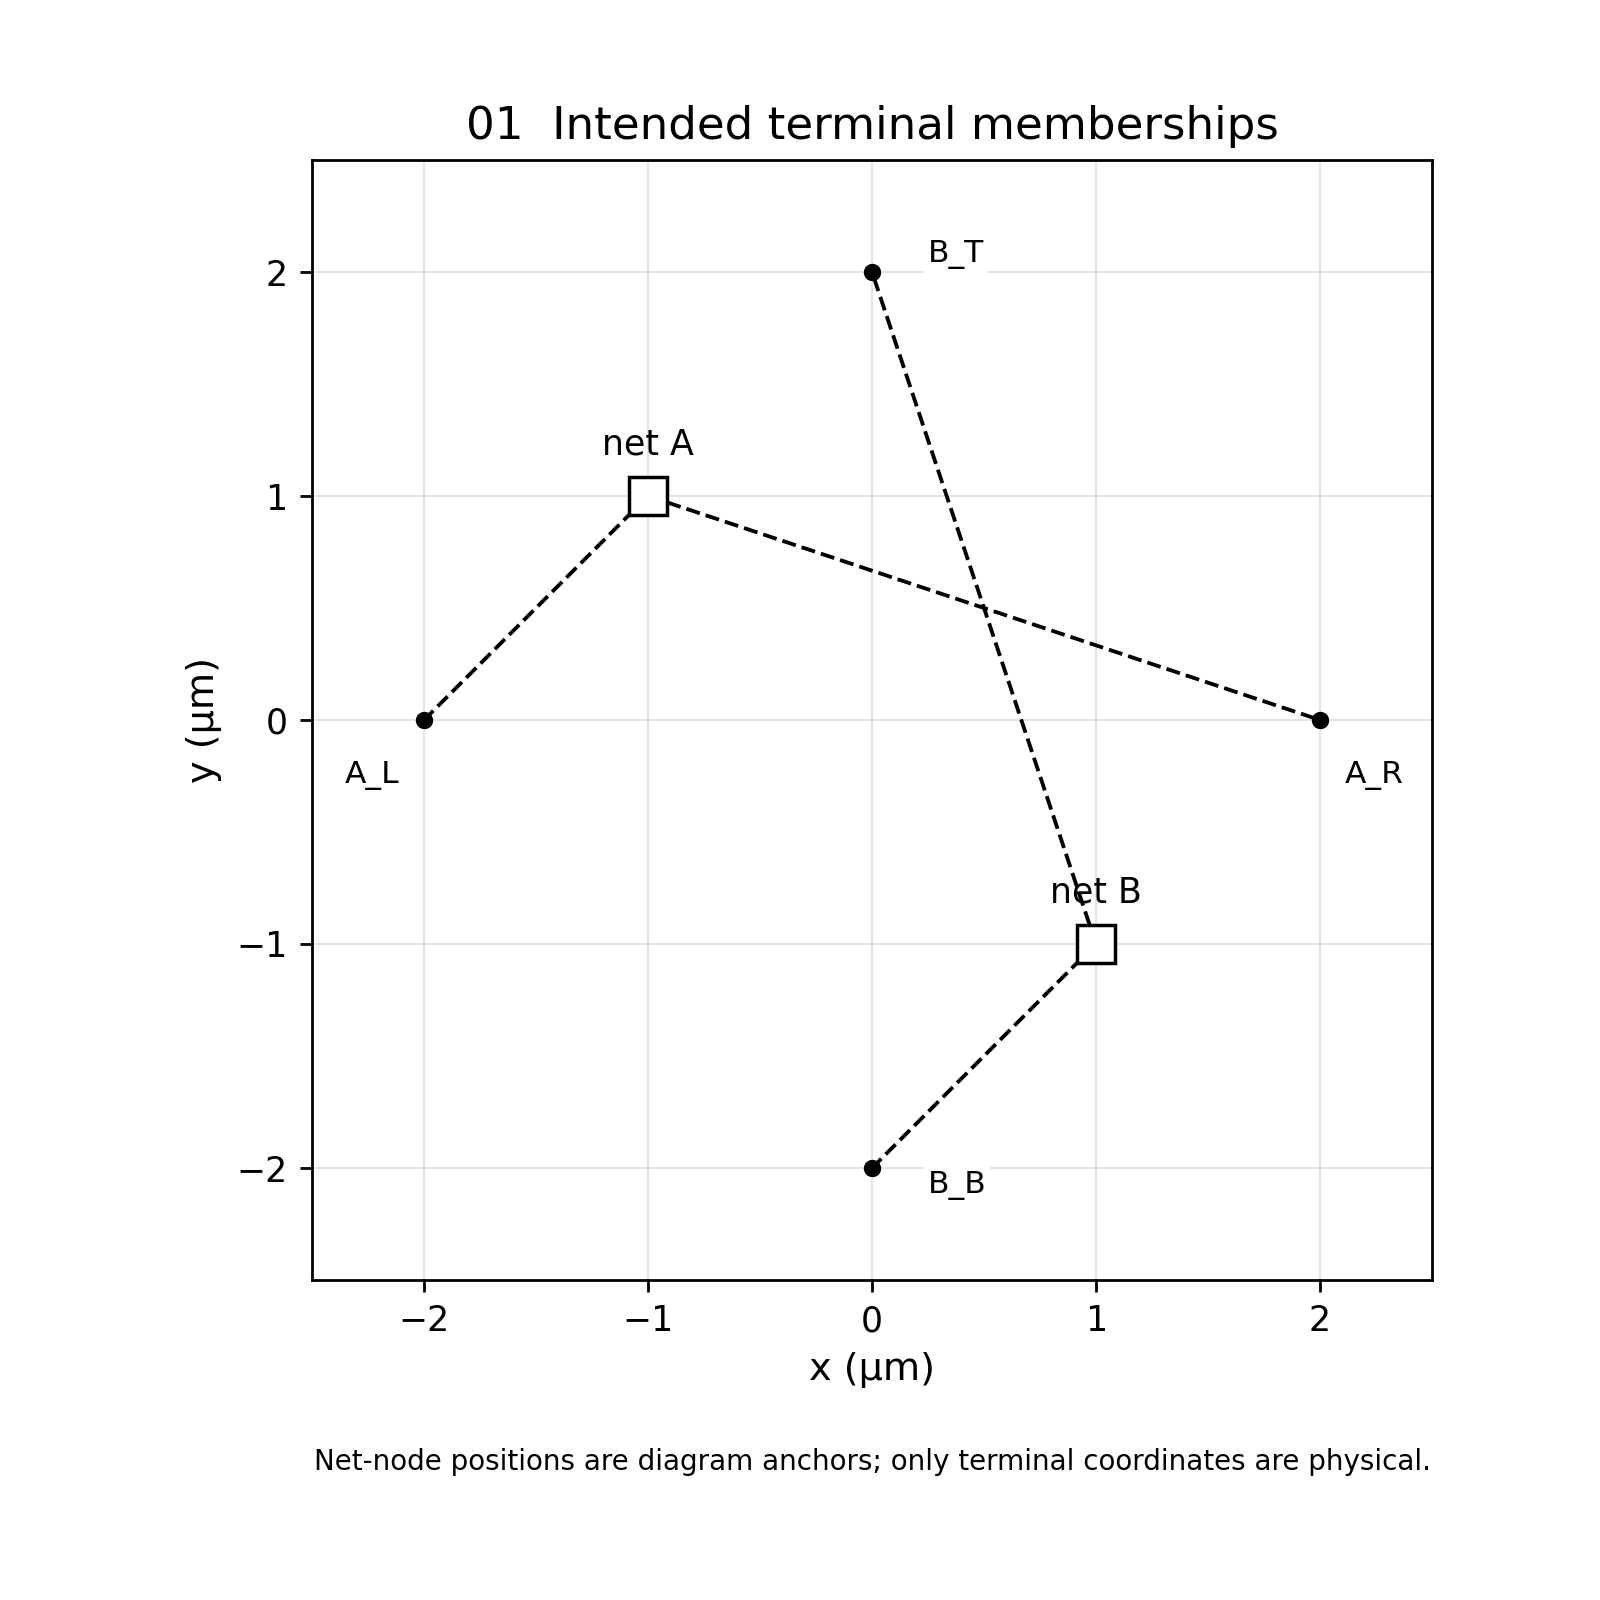
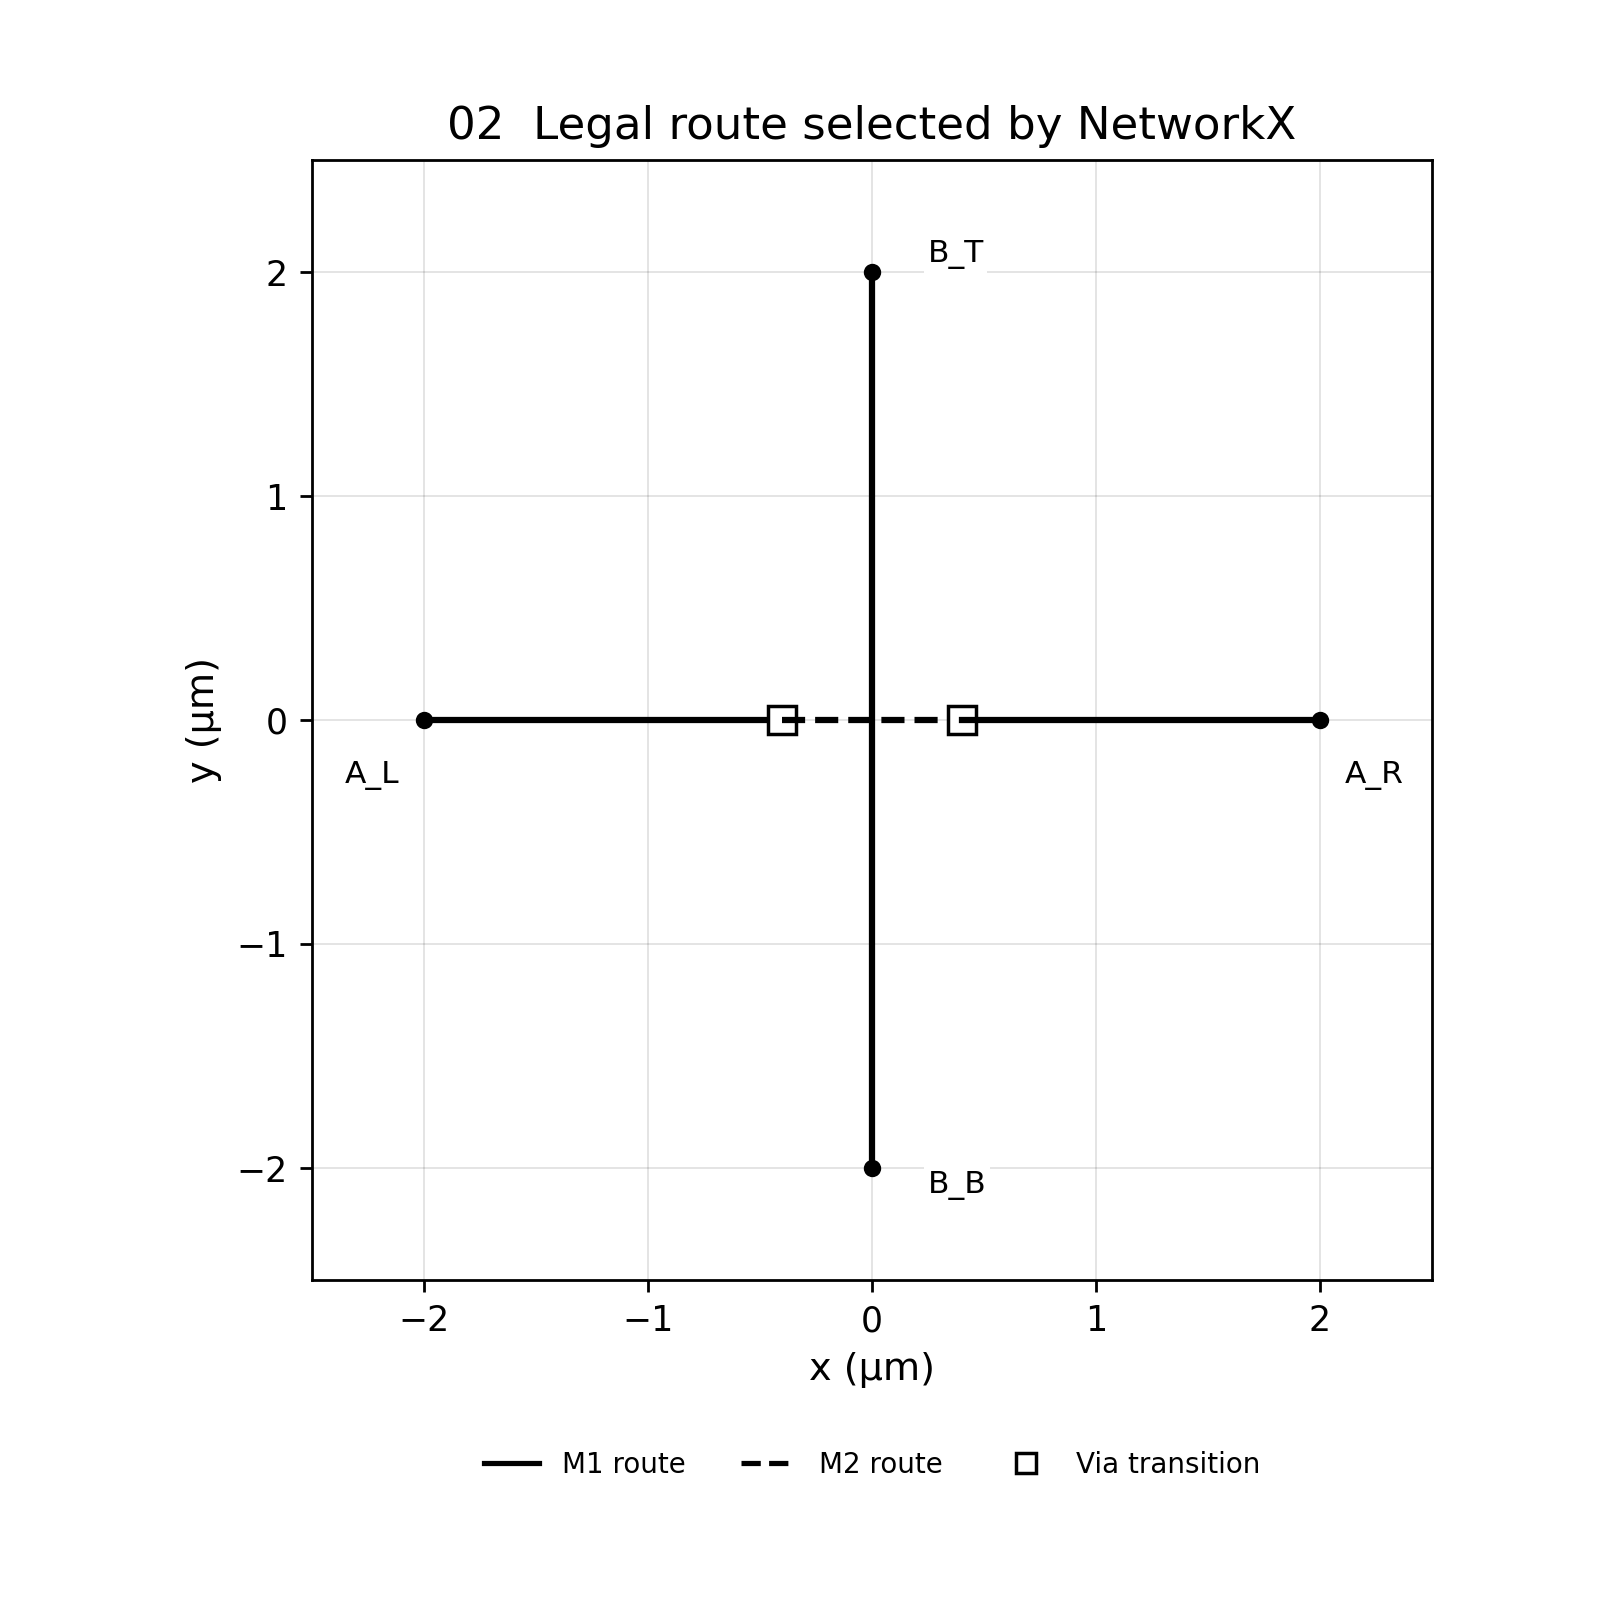
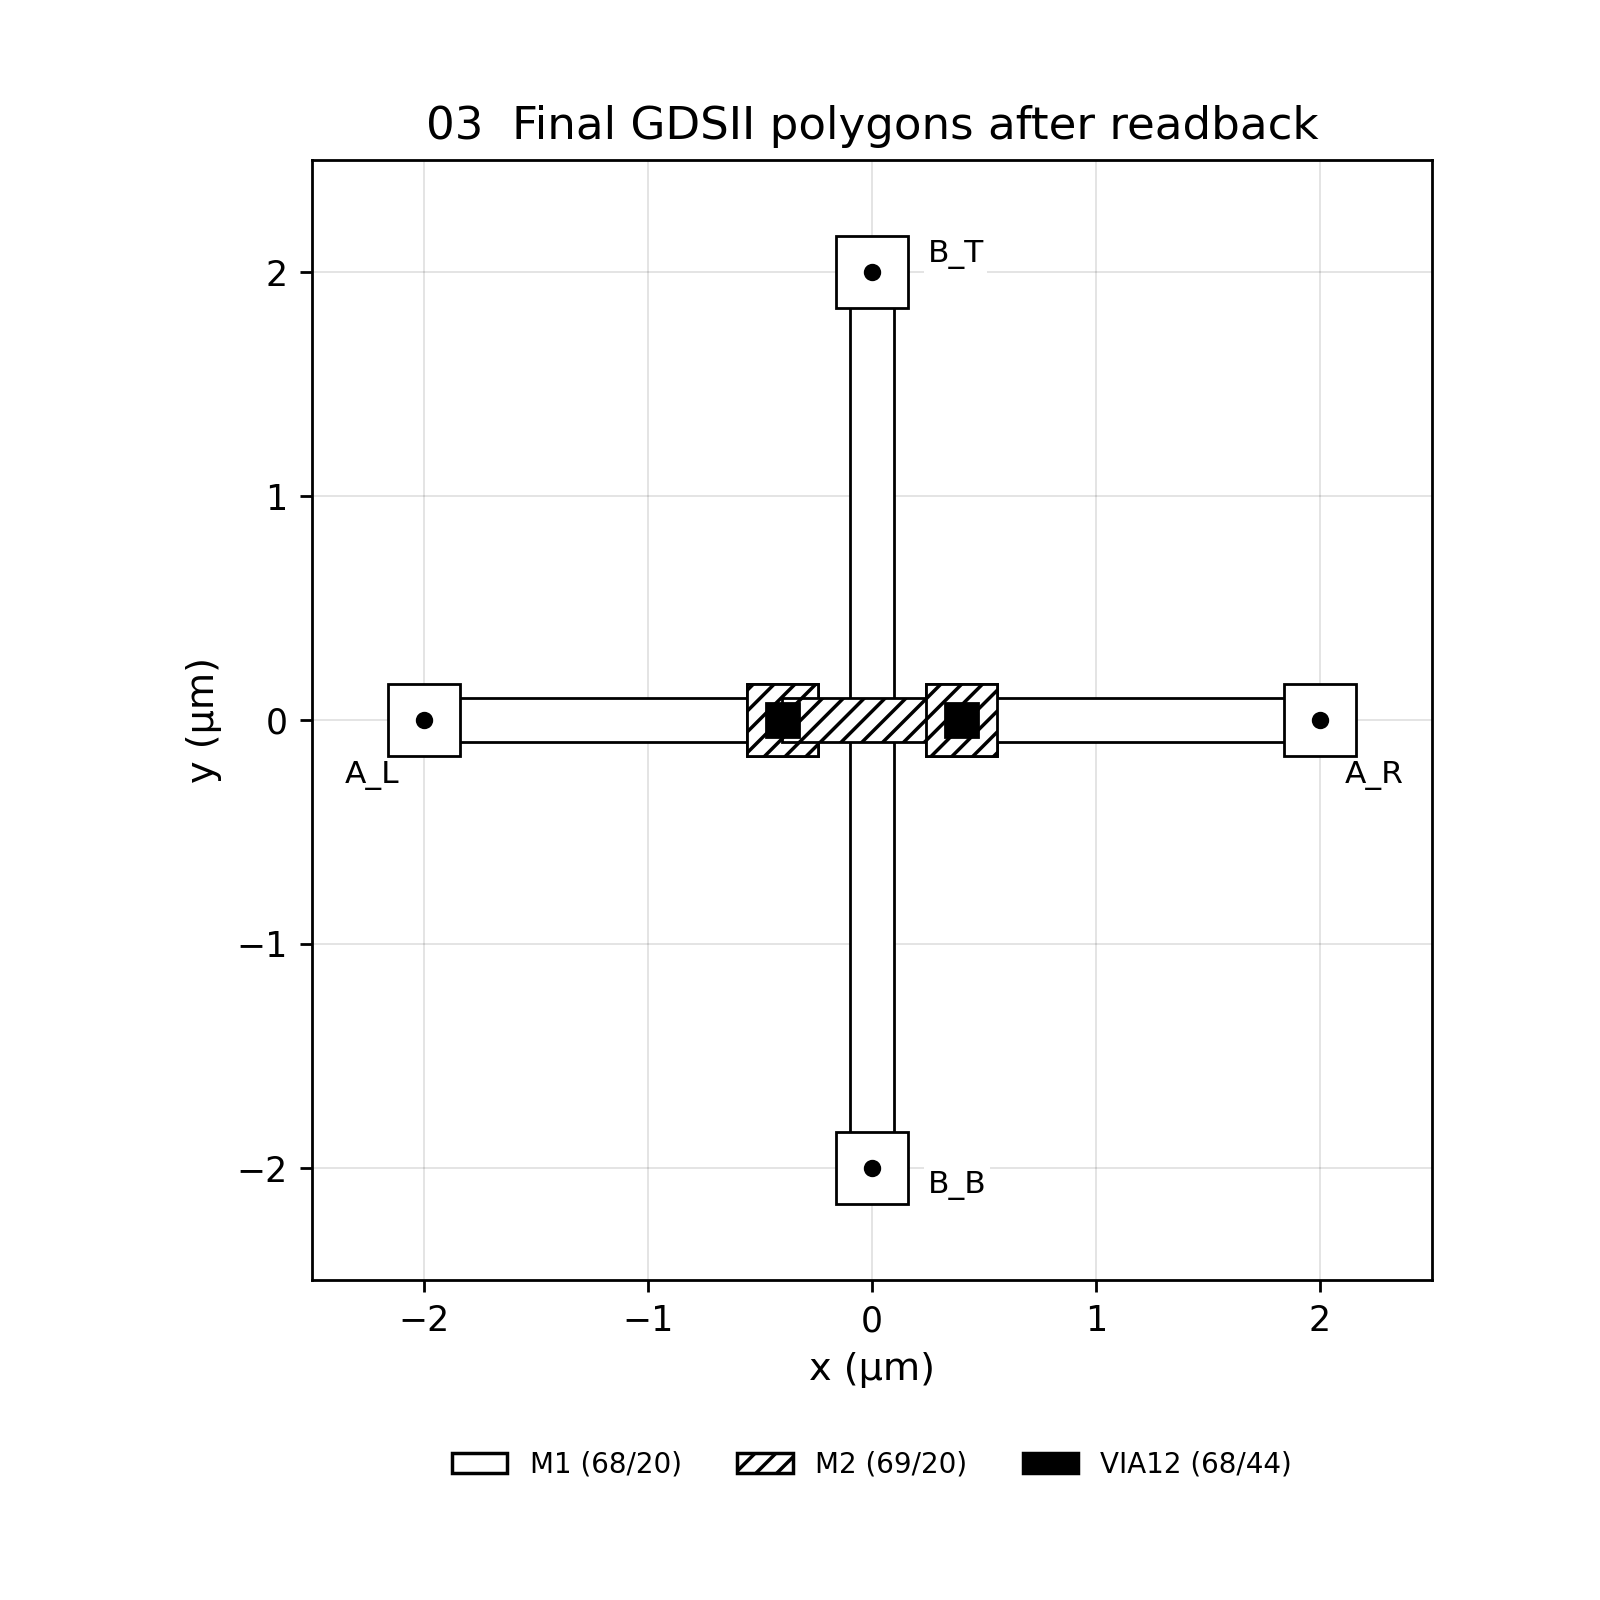
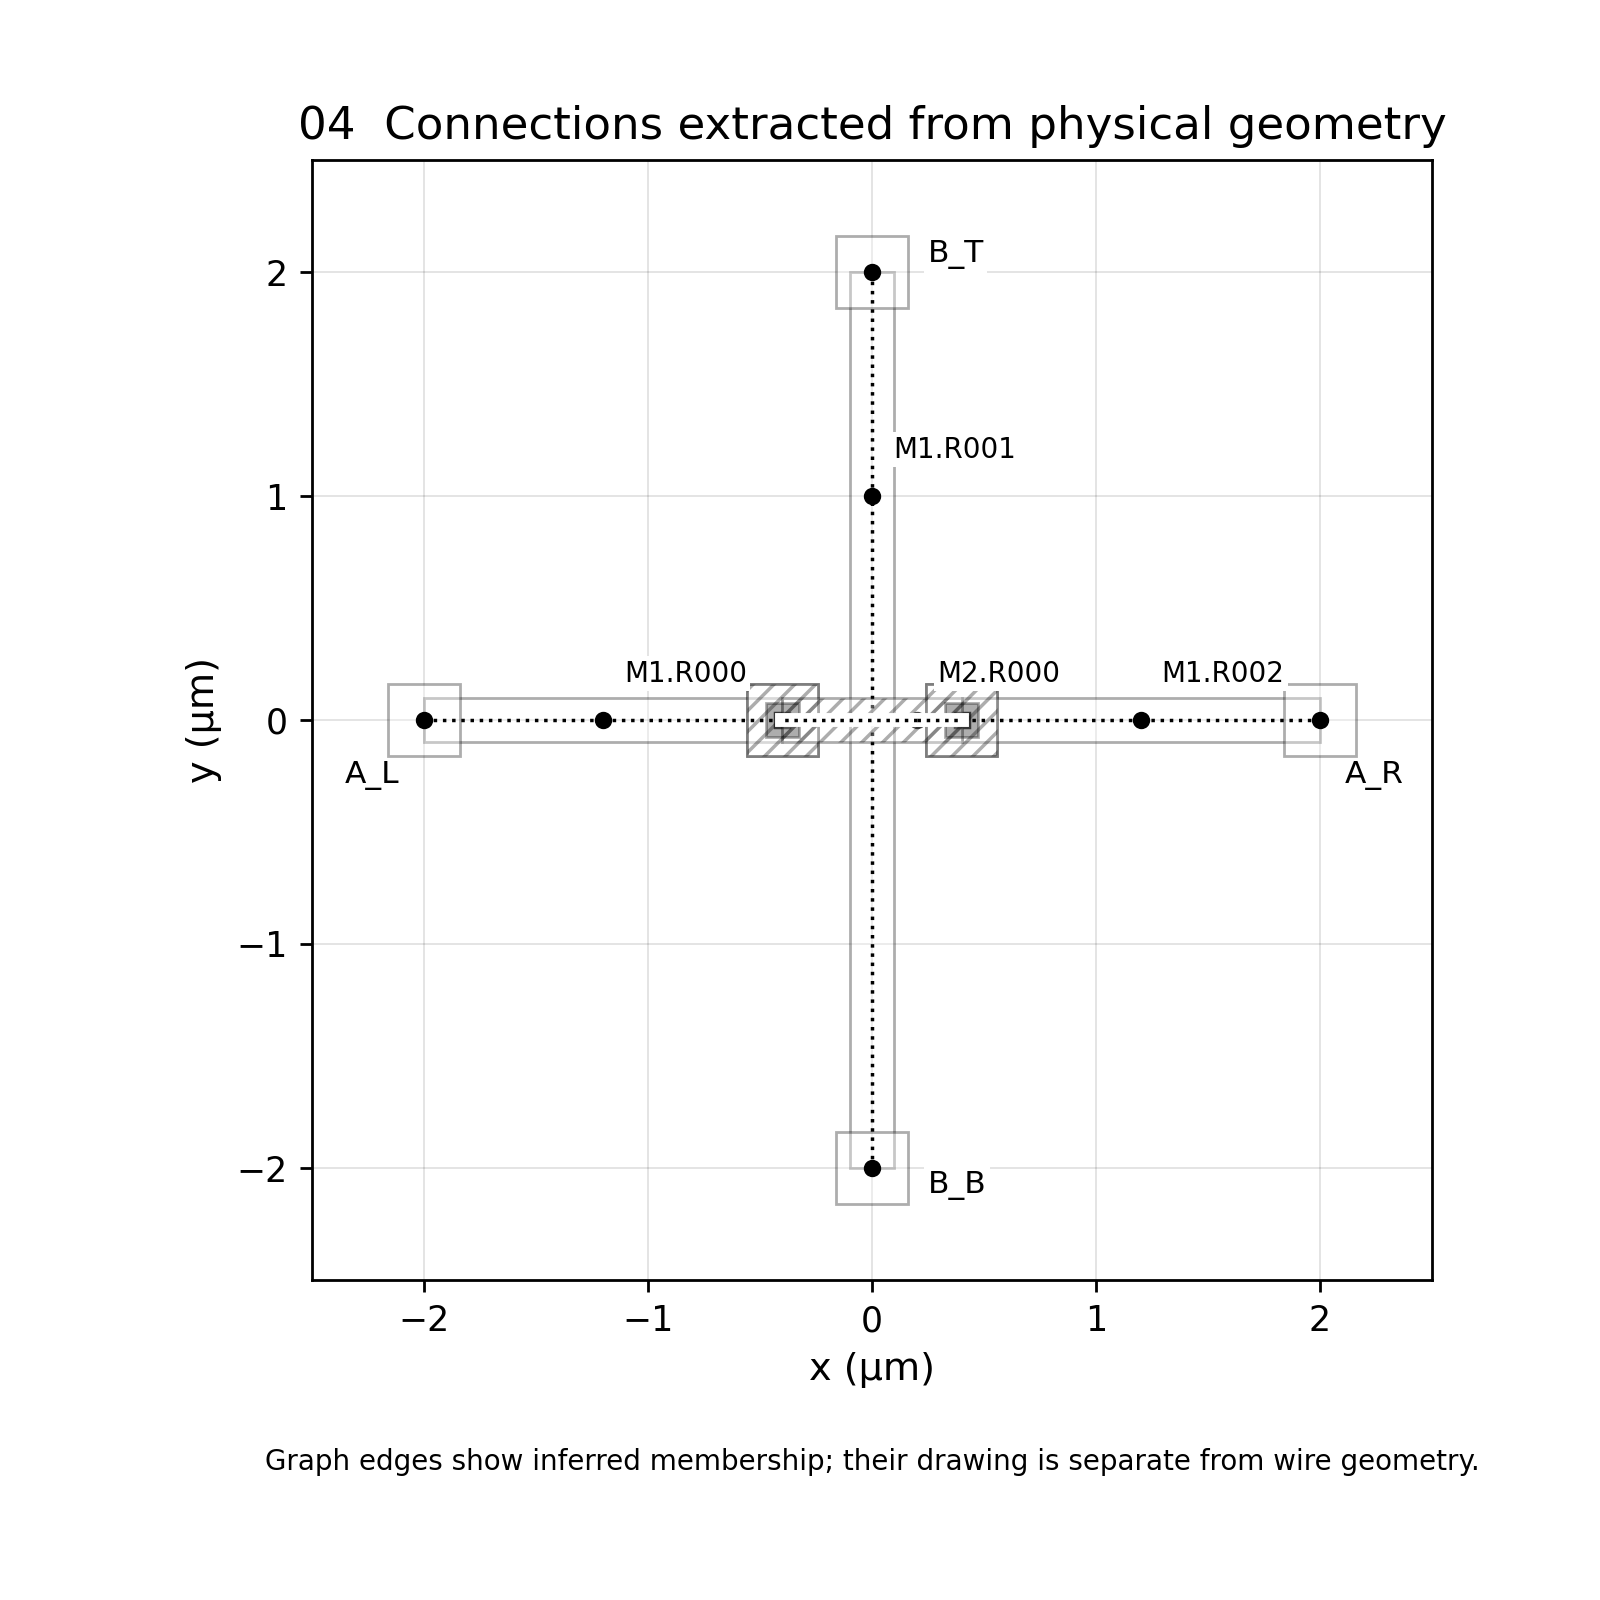

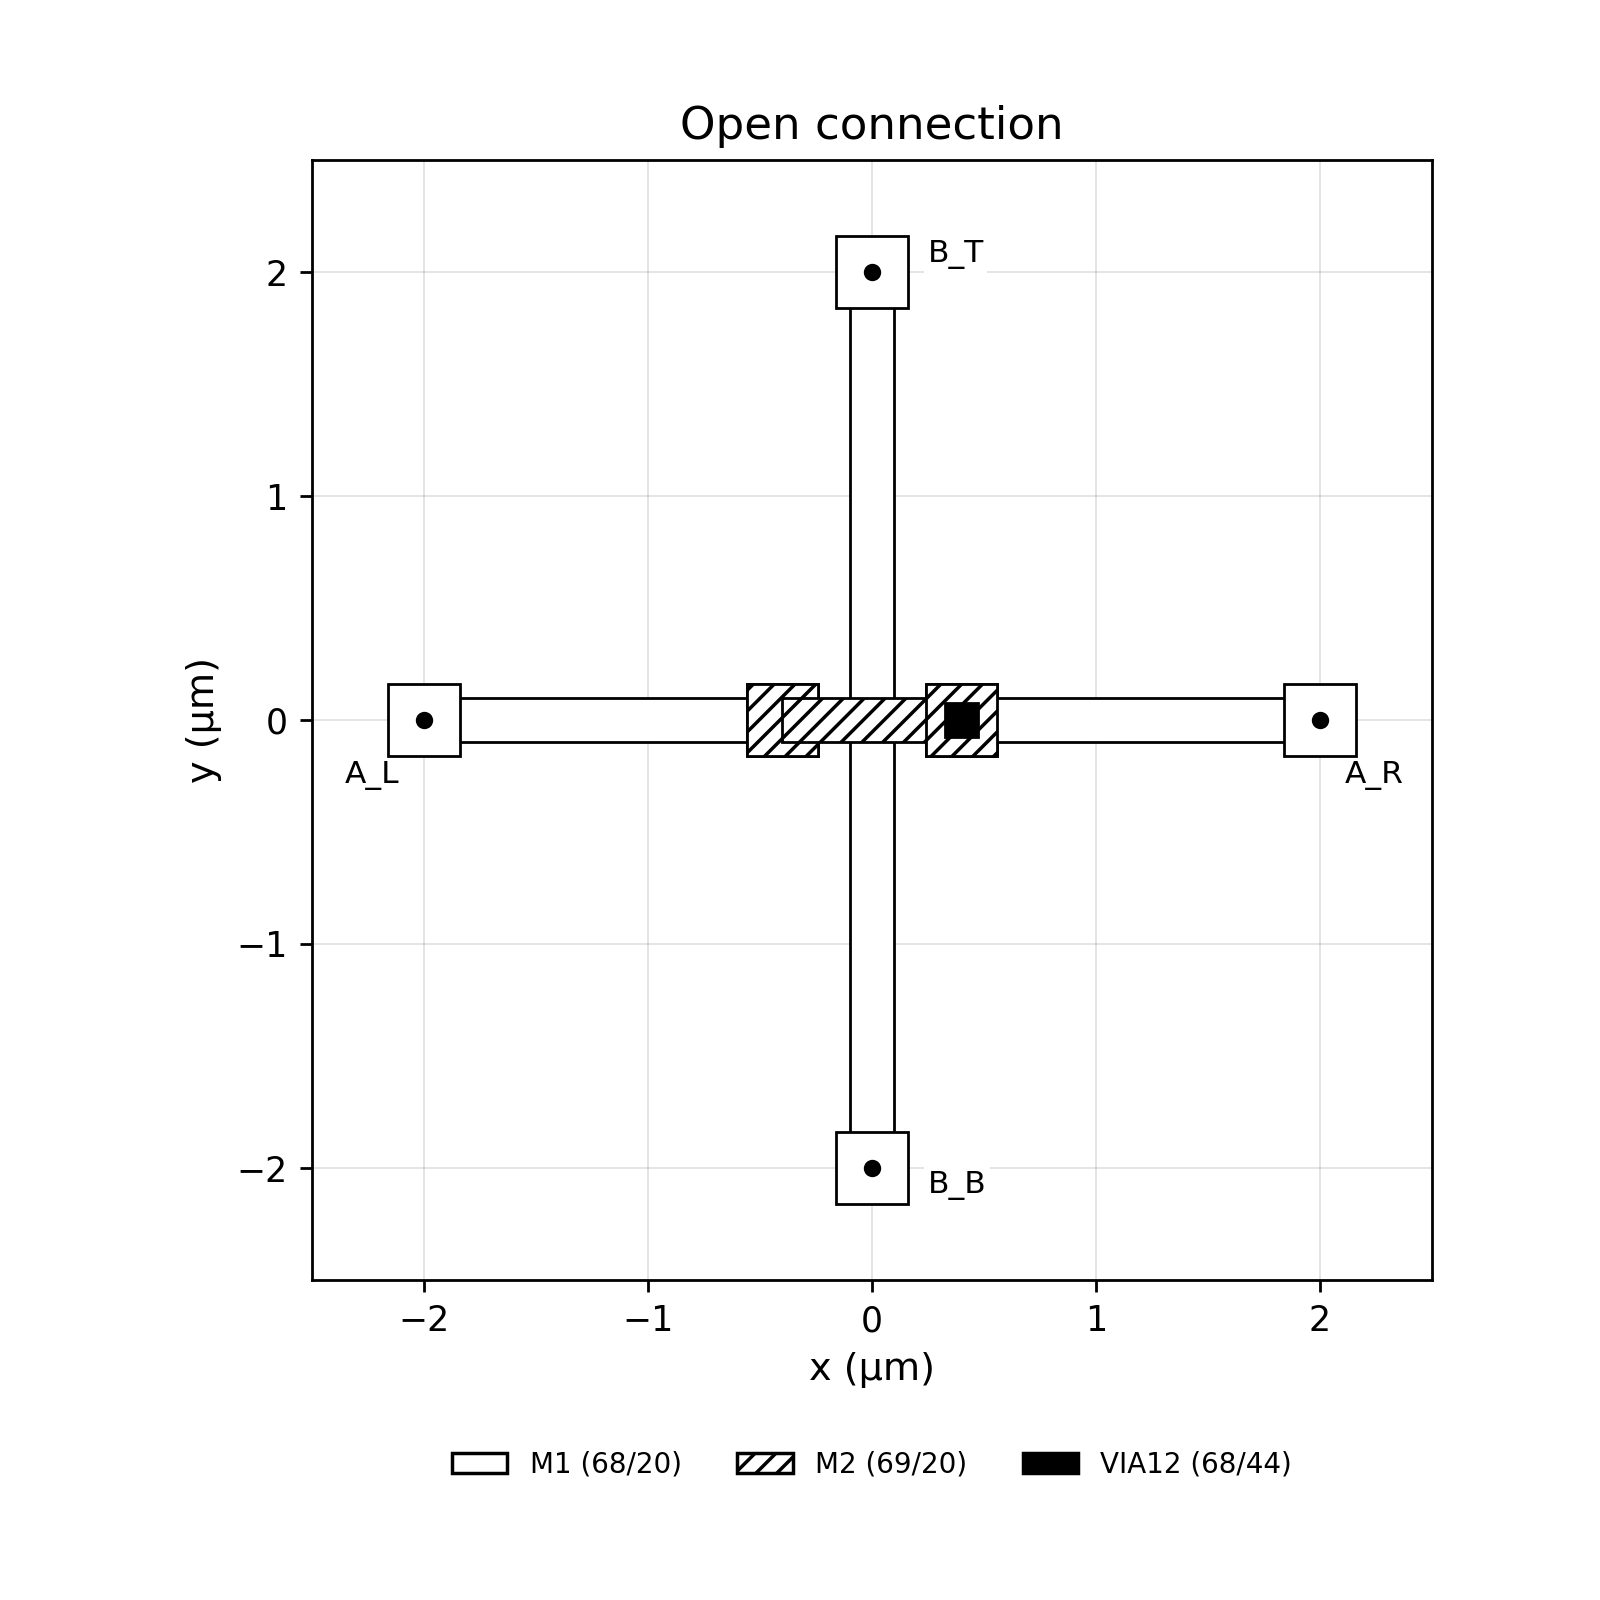

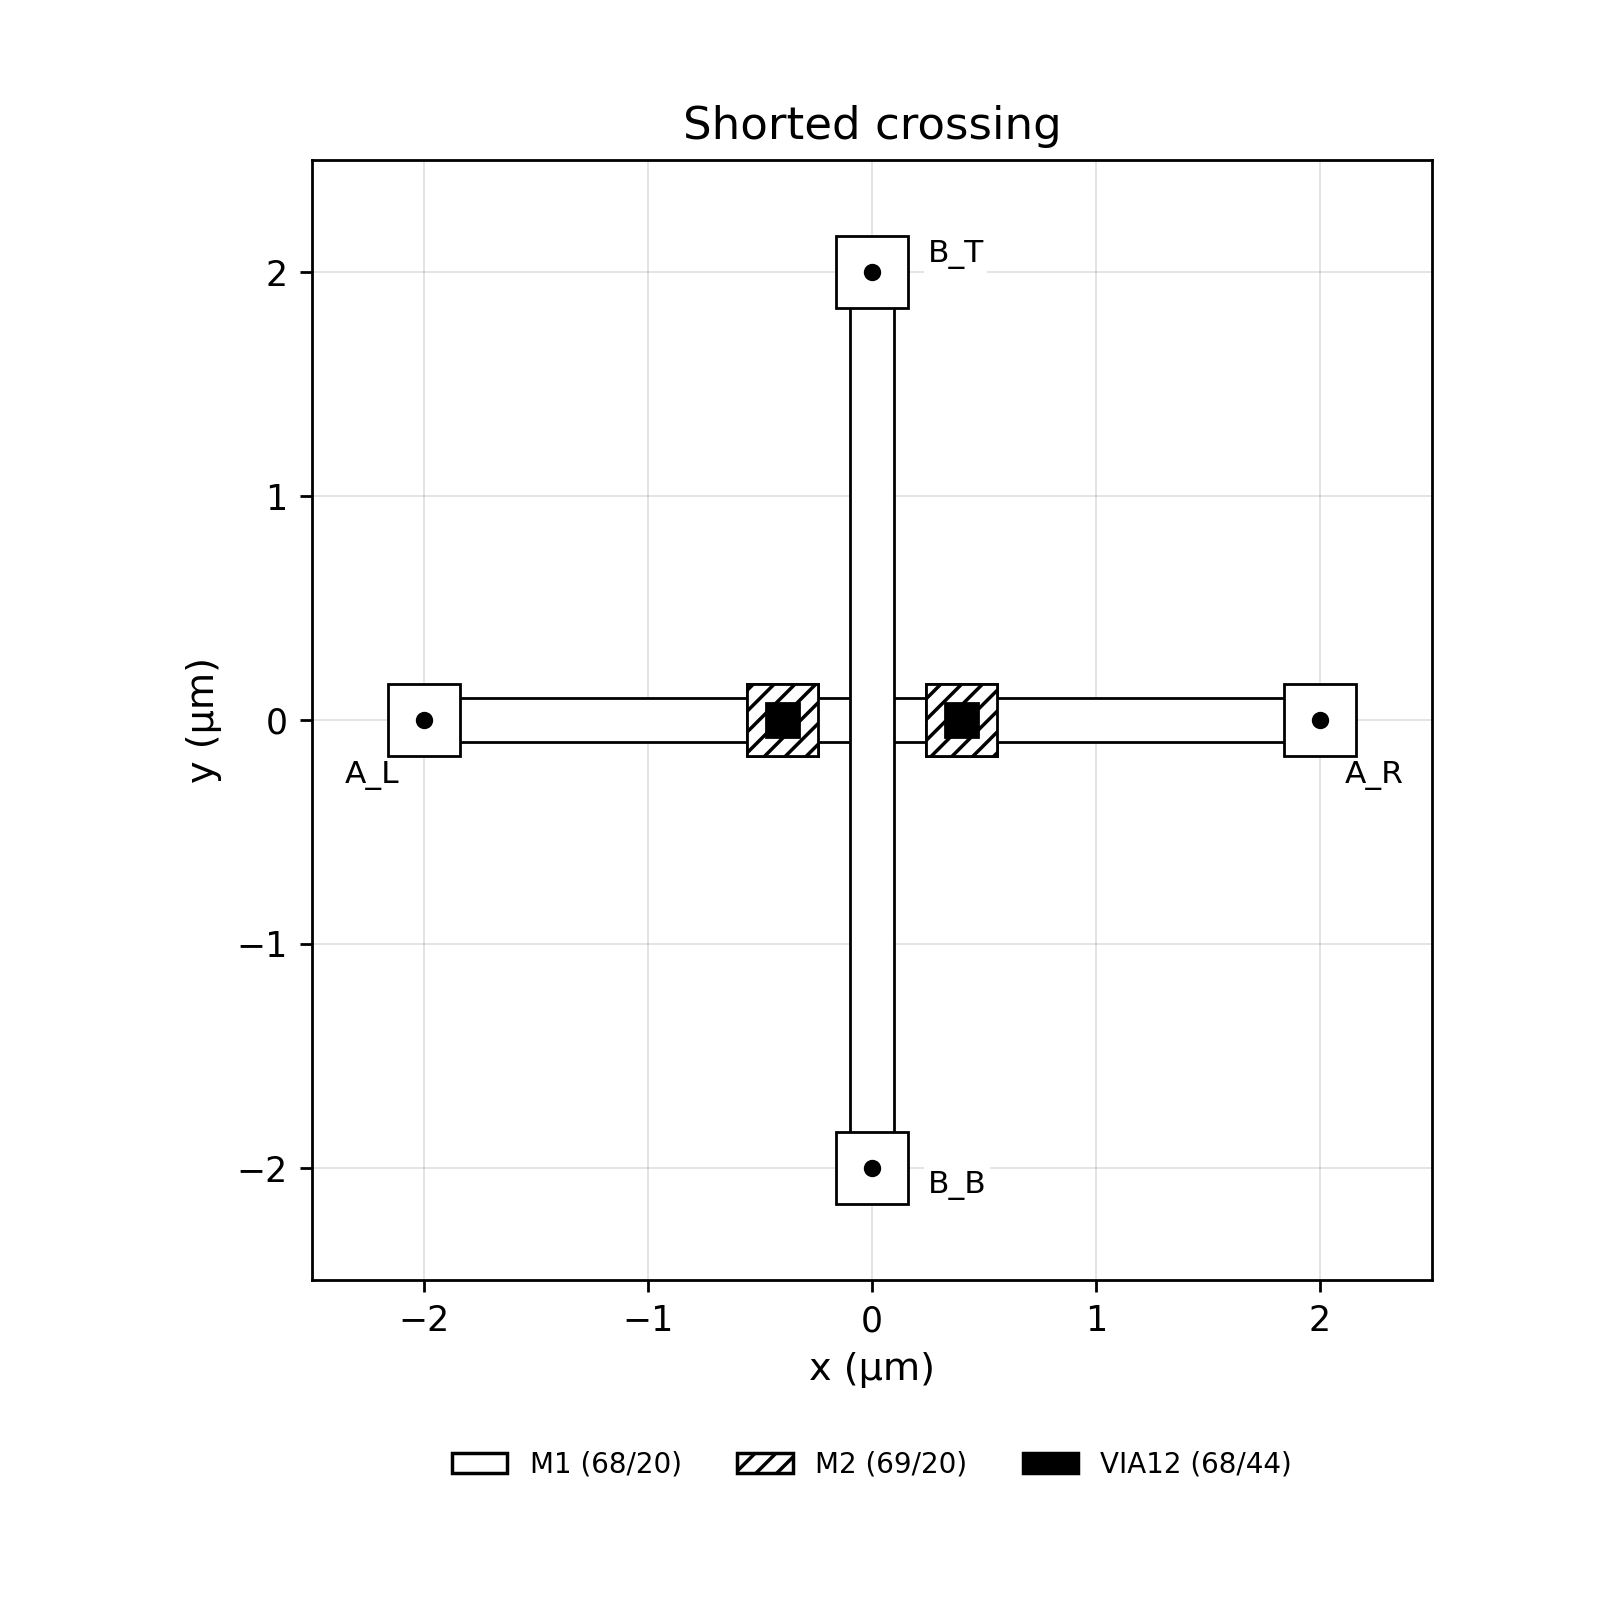

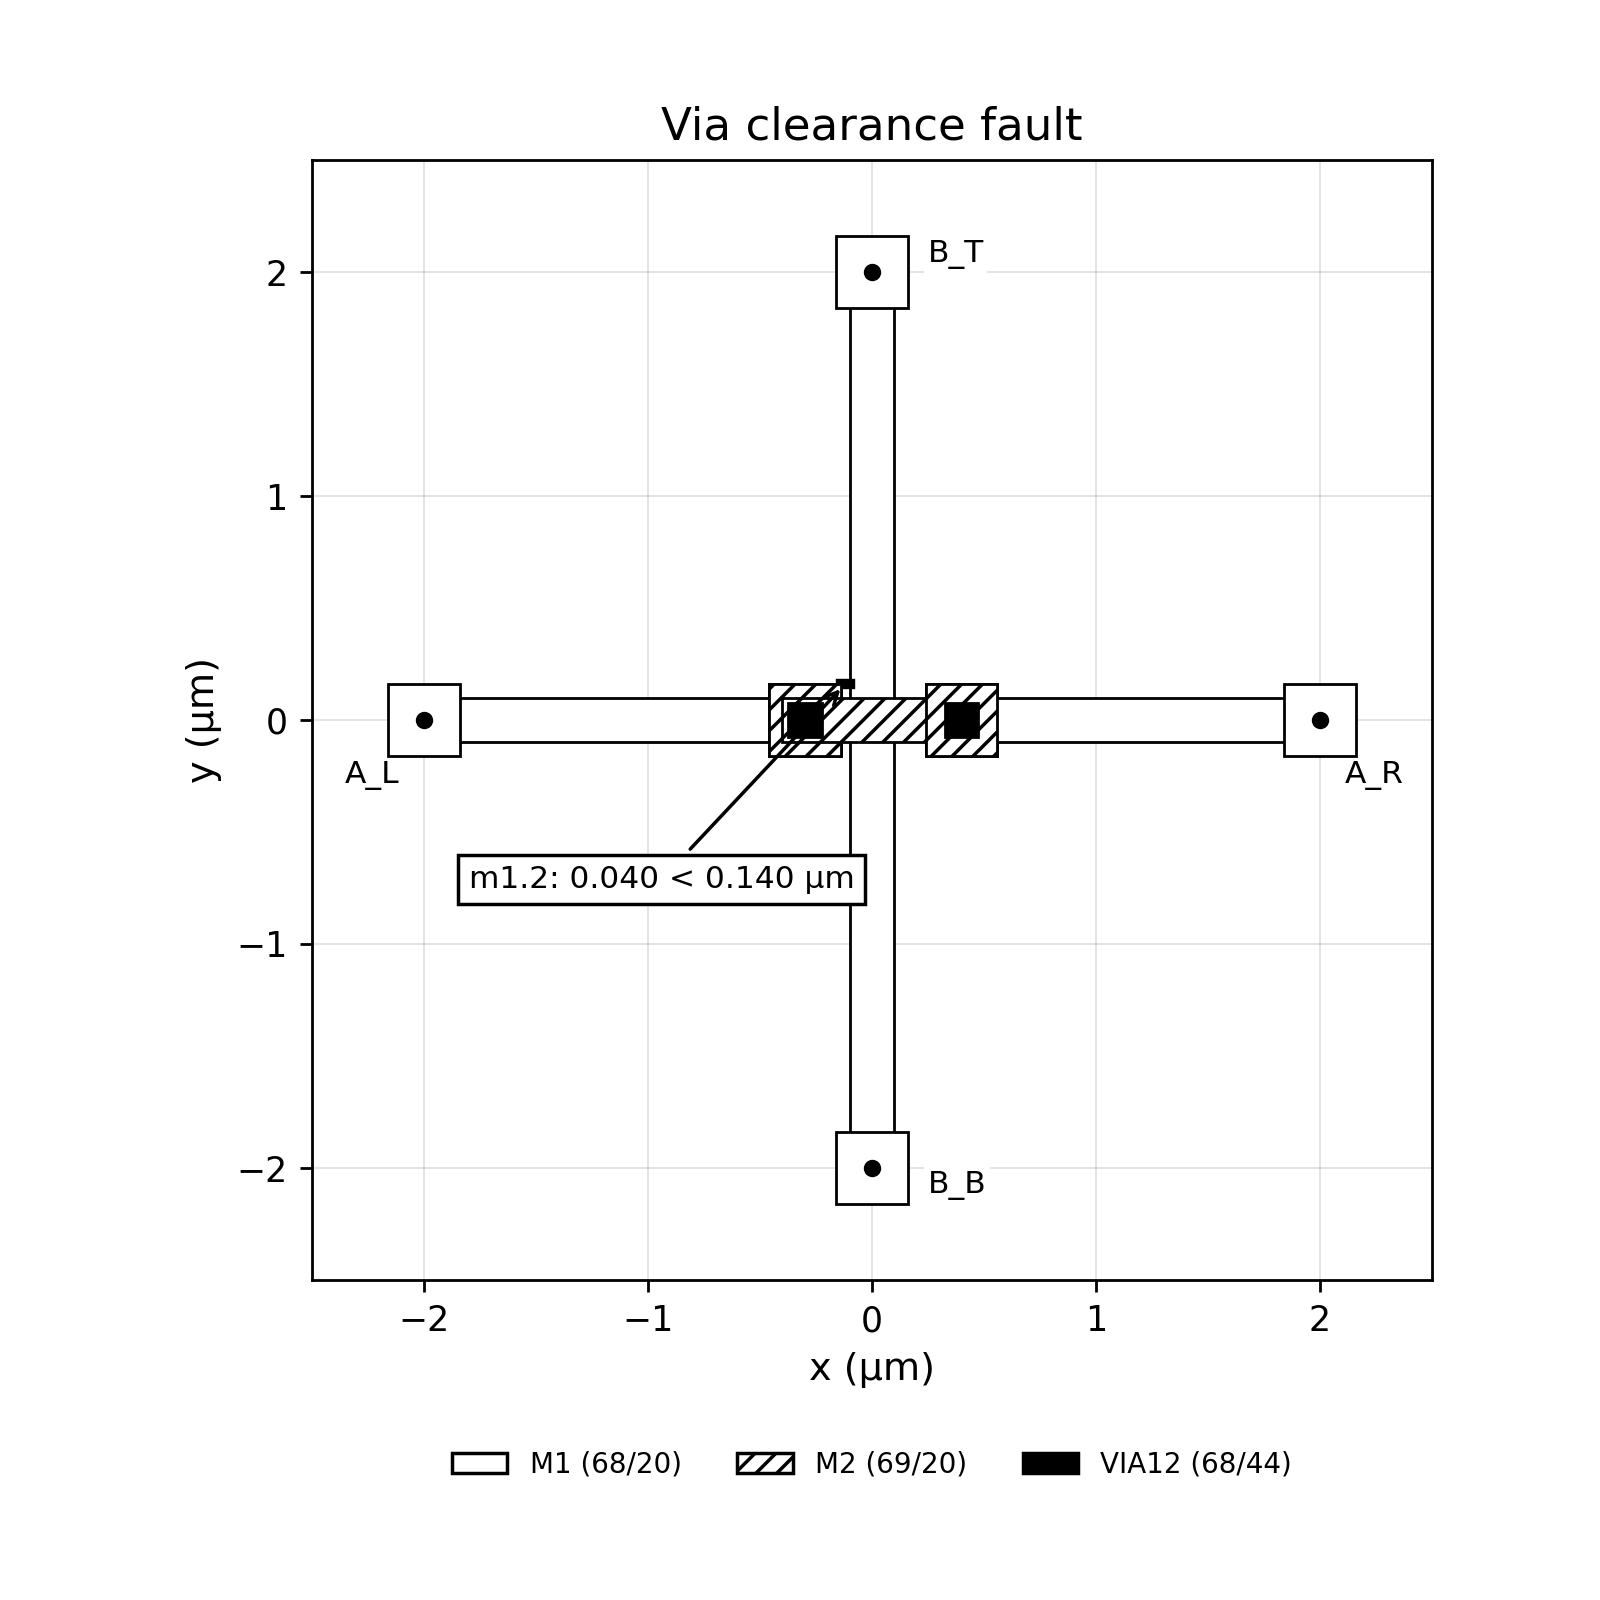

In [16]:
import base64

panels = []
for name in ("01_intent.png", "02_route.png", "03_polygons.png", "04_extracted.png"):
    payload = base64.b64encode((OUTPUT_PATH / "figures" / name).read_bytes()).decode()
    panels.append(f'<img alt="{name}" style="width:100%" src="data:image/png;base64,{payload}">')
display(HTML(
    '<div style="display:grid;grid-template-columns:1fr 1fr;gap:10px">'
    + "".join(panels) + "</div>"
))
for name in ("case_open_connection.png", "case_shorted_crossing.png", "case_via_clearance_fault.png"):
    display(Image(filename=str(OUTPUT_PATH / "figures" / name), width=650))


## 8. Inspect the synthetic stack

The stack follows the manuscript's declared display values. M1 occupies z = 0.0 to 0.2 µm, the via occupies z = 0.2 to 0.5 µm, and M2 occupies z = 0.5 to 0.7 µm. The unscaled mesh files retain those coordinates. The exaggerated scene scales only displayed height and reports that factor beside the view.

Static figures are available regardless of PyVista installation or browser support. PyVista executes in a separate process so a backend crash leaves the completed core checks intact. Its exported HTML scene supports geometric inspection; browser interaction still requires an actual frontend check.

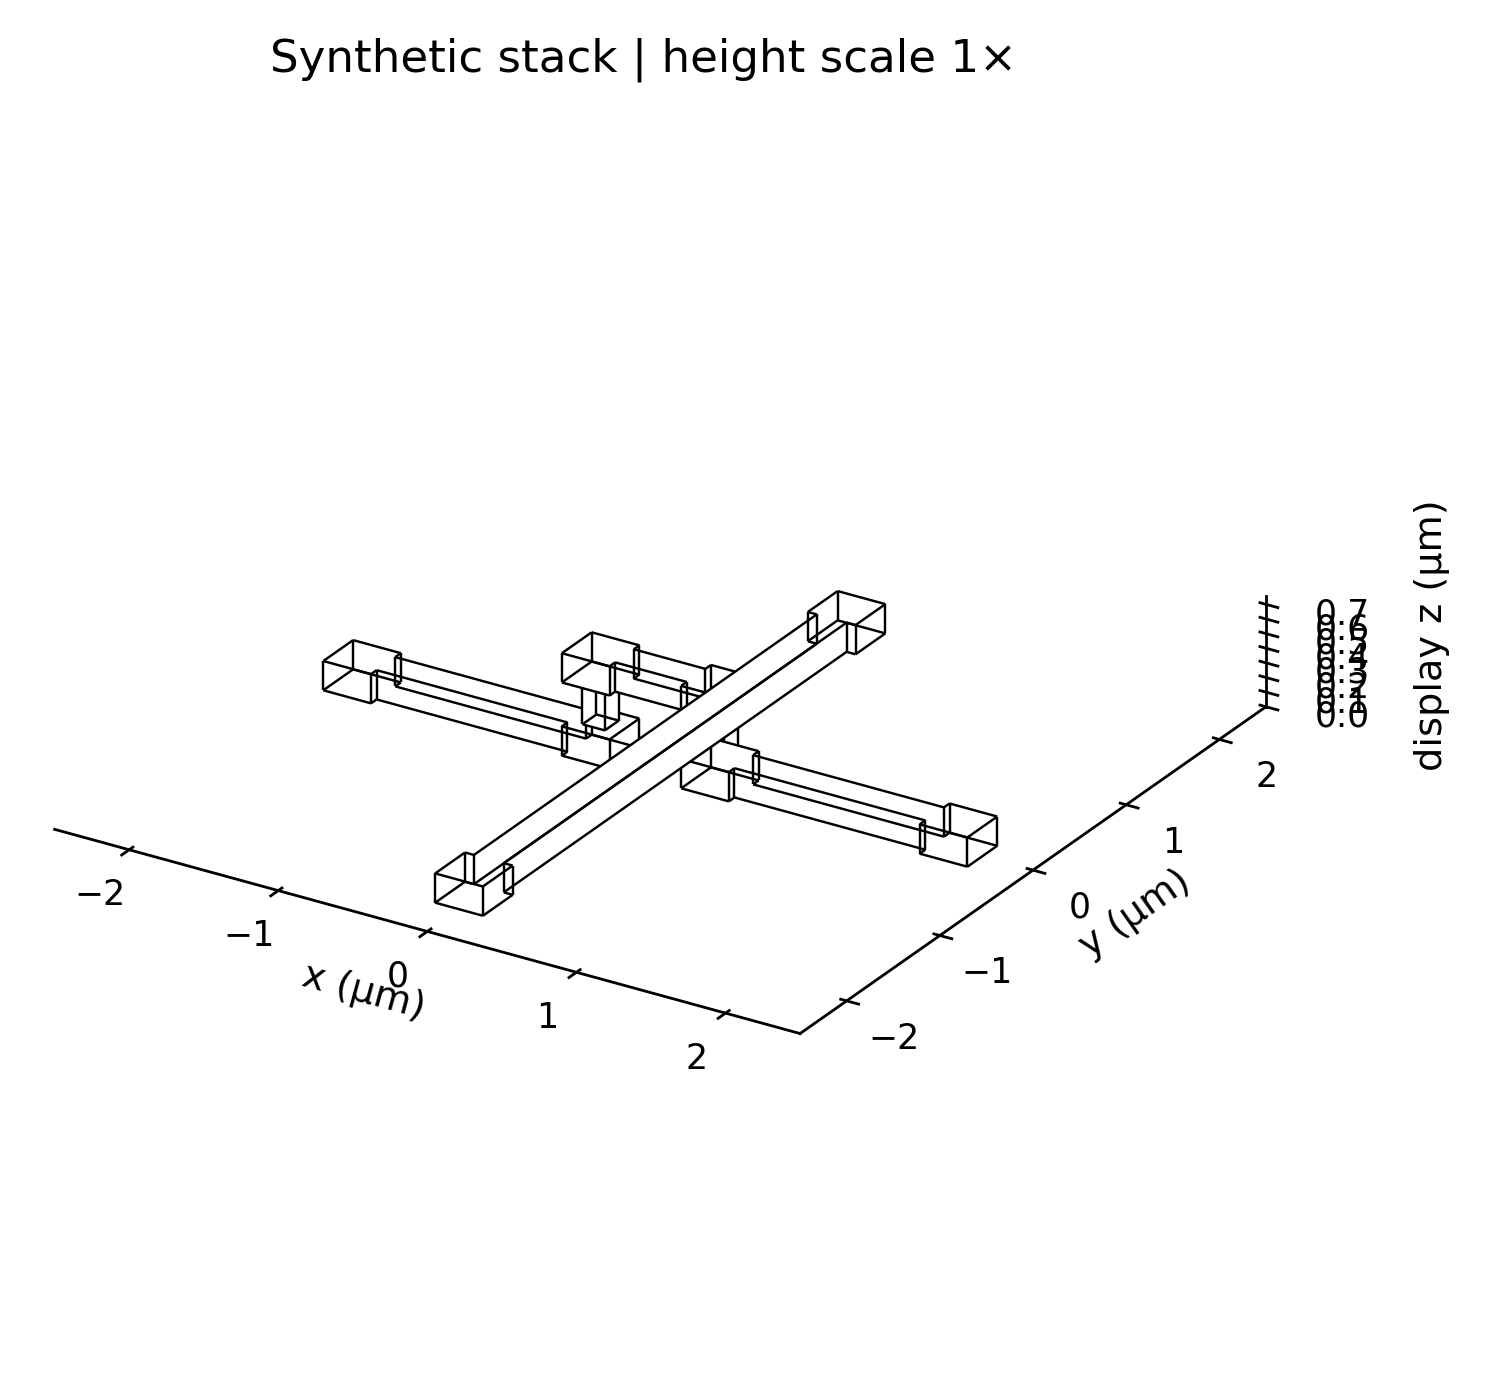

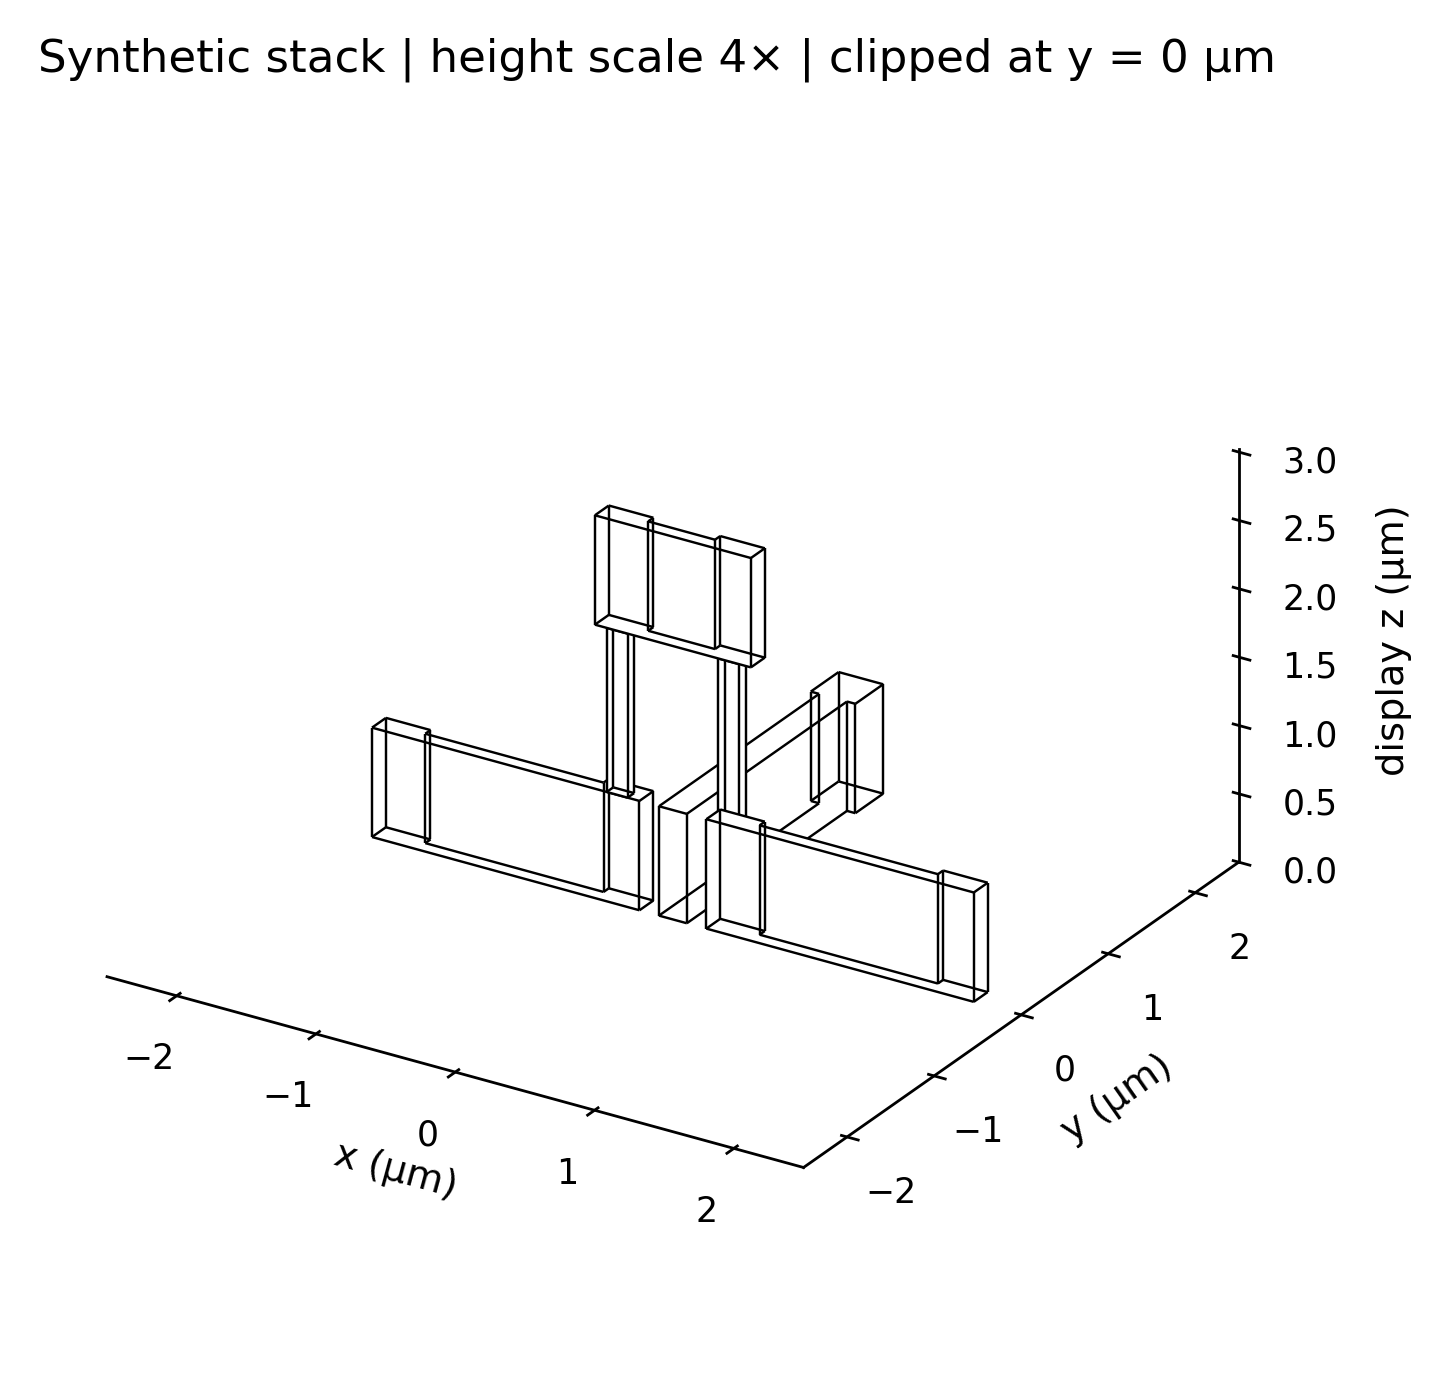

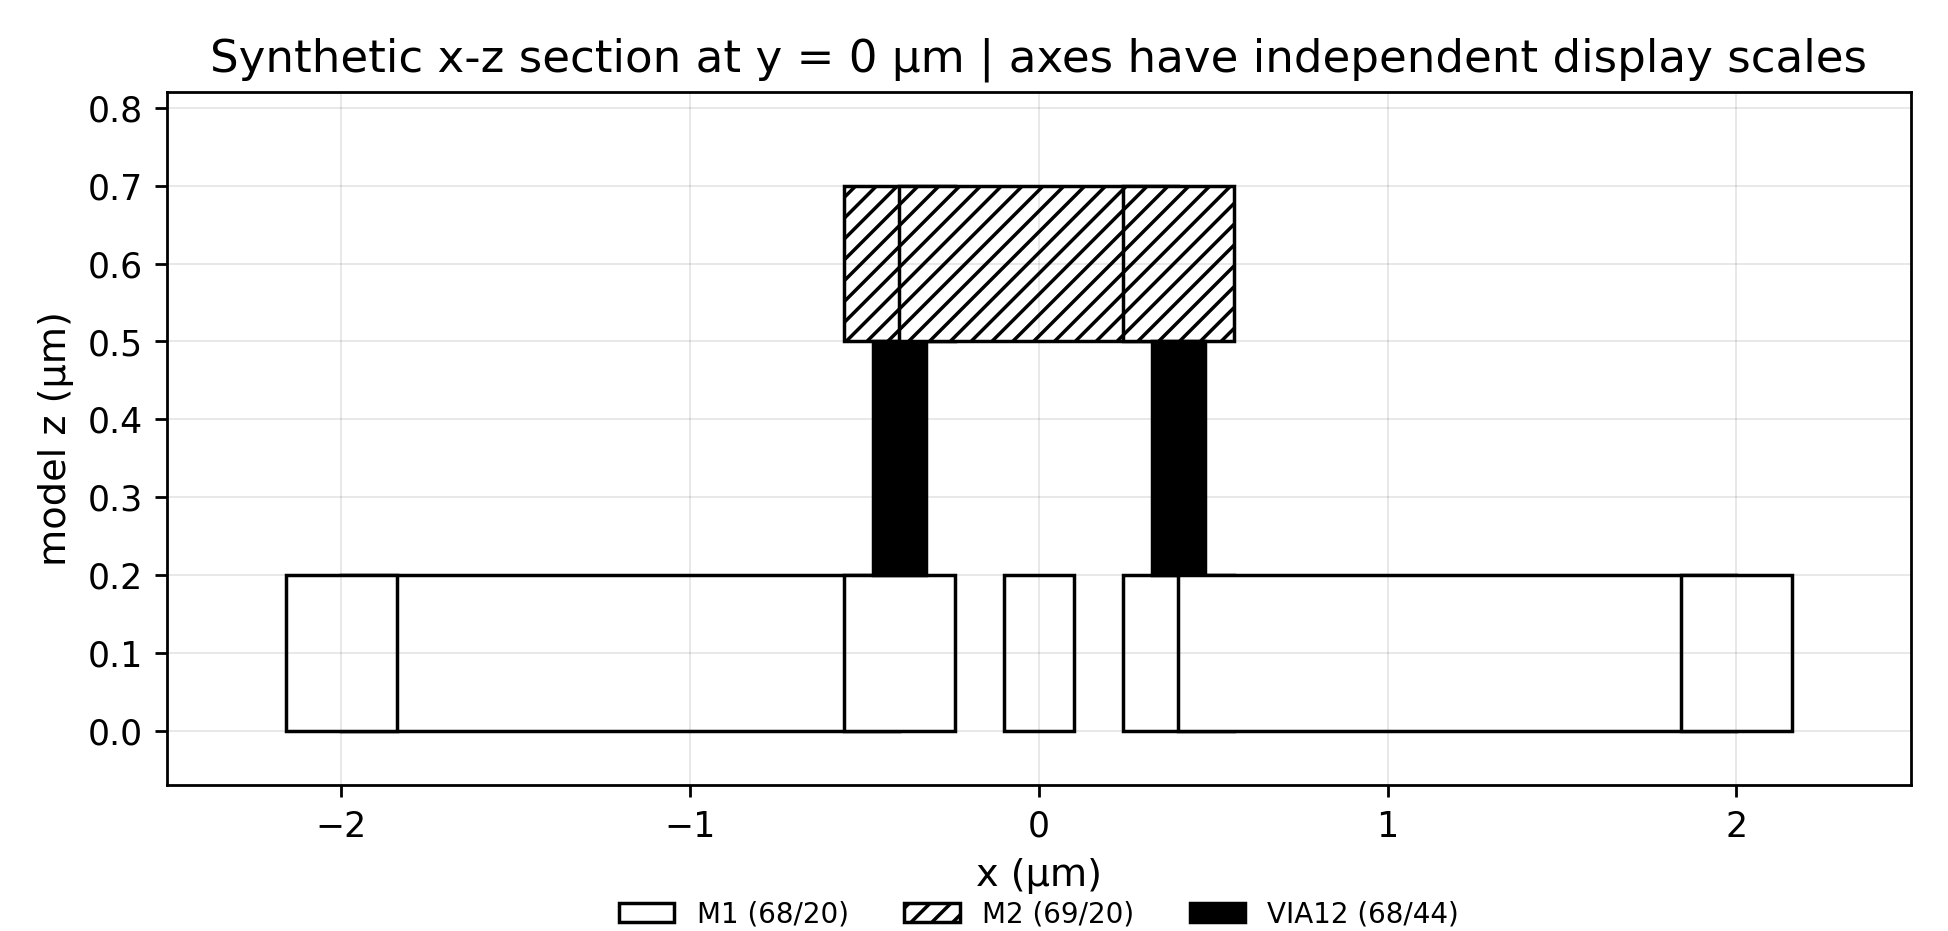

/usr/local/lib/python3.13/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


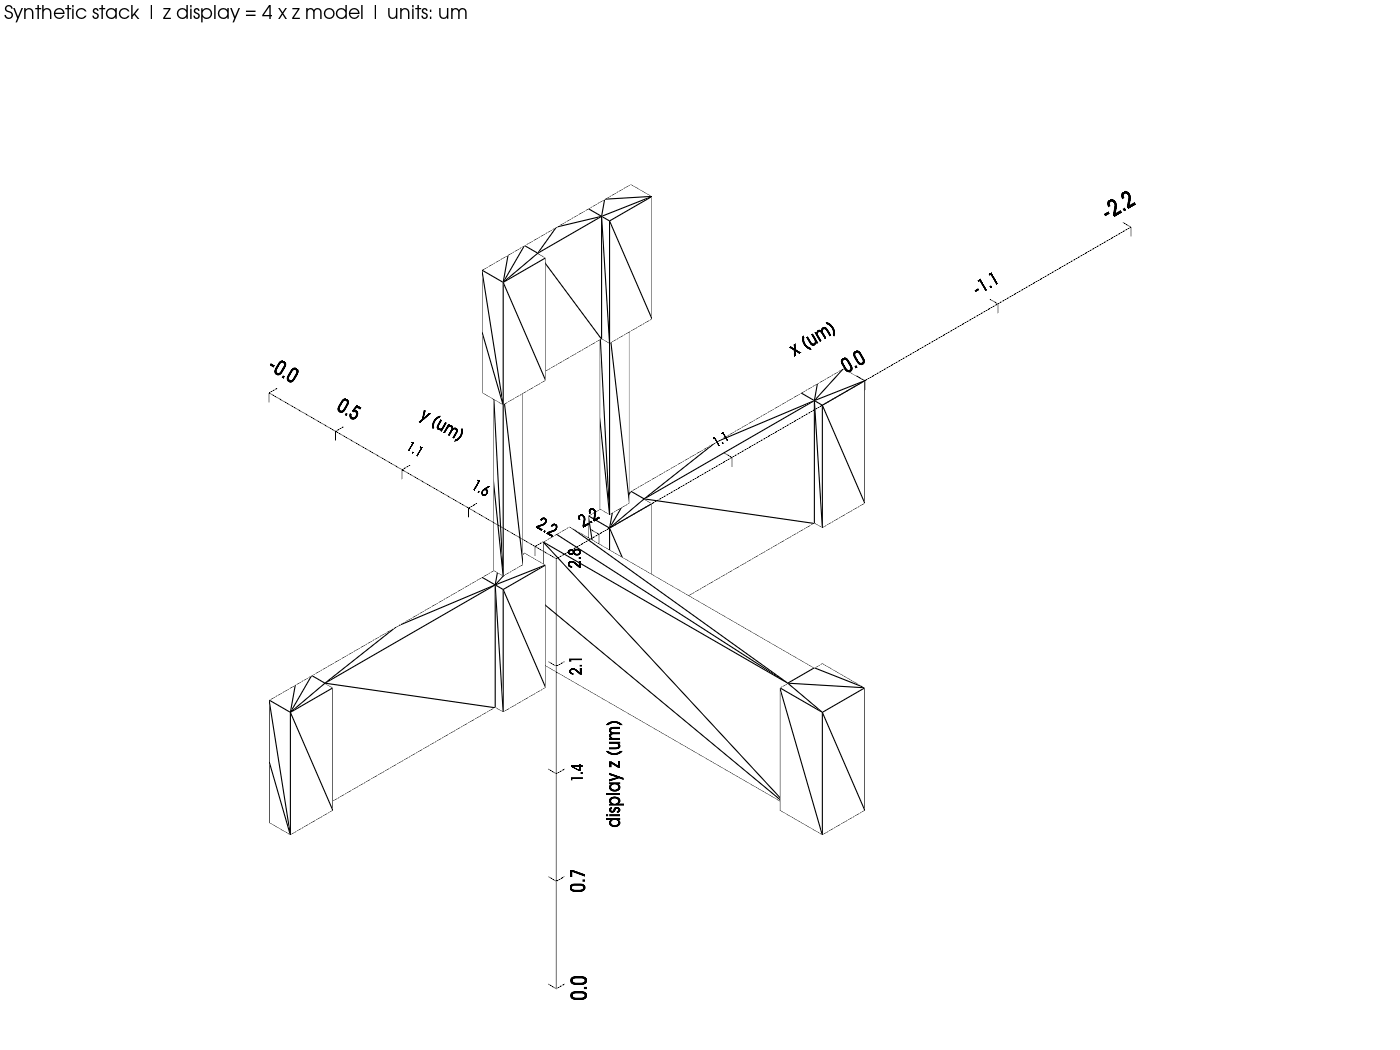

PyVista viewer completed via egl-offscreen.
Viewer status: COMPLETED


In [17]:
for name in ("05_stack_unscaled.png", "06_stack_clipped.png", "07_via_section.png"):
    display(Image(filename=str(OUTPUT_PATH / "figures" / name), width=850))

viewer_status = {"status": "DISABLED", "installation": viewer_install}
if ENABLE_PYVISTA:
    viewer_log_path = OUTPUT_PATH / "viewer.log"
    viewer_script = [
        str(PROJECT_PYTHON),
        str(PROJECT_PATH / "render_pyvista.py"),
        "--output",
        str(OUTPUT_PATH),
    ]

    # Use the render mode that already passed the miniature export_html test.
    preferred_mode = viewer_install.get("render_preflight_mode", "egl-offscreen")
    attempts = []

    direct_env = PROJECT_ENV.copy()
    direct_env["PYVISTA_OFF_SCREEN"] = "true"
    direct_env["VTK_DEFAULT_OPENGL_WINDOW"] = "vtkEGLRenderWindow"
    direct_env.pop("DISPLAY", None)
    direct_env.pop("LIBGL_ALWAYS_SOFTWARE", None)
    attempts.append(("egl-offscreen", viewer_script, direct_env))

    xvfb_run = shutil.which("xvfb-run")
    if xvfb_run:
        xvfb_env = PROJECT_ENV.copy()
        xvfb_env["PYVISTA_OFF_SCREEN"] = "true"
        xvfb_env["LIBGL_ALWAYS_SOFTWARE"] = "1"
        xvfb_env["VTK_DEFAULT_OPENGL_WINDOW"] = "vtkXOpenGLRenderWindow"
        attempts.append(
            (
                "xvfb-software-opengl",
                [
                    xvfb_run,
                    "-a",
                    "-s",
                    "-screen 0 1400x1050x24 -nolisten tcp",
                    *viewer_script,
                ],
                xvfb_env,
            )
        )

    attempts.sort(key=lambda item: item[0] != preferred_mode)
    rendered = None
    logs = []
    viewer_mode = None

    for mode, command, environment in attempts:
        try:
            candidate = subprocess.run(
                command,
                env=environment,
                cwd=PROJECT_PATH,
                capture_output=True,
                text=True,
                check=False,
                timeout=240,
            )
        except subprocess.TimeoutExpired as exc:
            partial = (exc.stdout or "") + (exc.stderr or "")
            logs.append(f"===== {mode}: TIMEOUT =====\n{partial}")
            continue

        logs.append(
            f"===== {mode}: returncode={candidate.returncode} =====\n"
            + candidate.stdout
            + candidate.stderr
        )
        if (
            candidate.returncode == 0
            and (OUTPUT_PATH / "pyvista_scene.html").is_file()
            and (OUTPUT_PATH / "pyvista_scene.png").is_file()
        ):
            rendered = candidate
            viewer_mode = mode
            break

    _ = viewer_log_path.write_text("\n\n".join(logs), encoding="utf-8")

    if rendered is None:
        raise RuntimeError(
            "PyVista passed its setup preflight but failed on the real checked "
            f"layout. Inspect {viewer_log_path}."
        )

    viewer_status = json.loads(
        (OUTPUT_PATH / "viewer_status.json").read_text(encoding="utf-8")
    )
    viewer_status["launch_mode"] = viewer_mode
    viewer_status["installation"] = viewer_install

    scene = base64.b64encode(
        (OUTPUT_PATH / "pyvista_scene.html").read_bytes()
    ).decode("ascii")
    display(
        HTML(
            '<iframe style="width:100%;height:750px;border:1px solid black" '
            f'src="data:text/html;base64,{scene}"></iframe>'
        )
    )
    display(
        Image(
            filename=str(OUTPUT_PATH / "pyvista_scene.png"),
            width=850,
        )
    )
    print(f"PyVista viewer completed via {viewer_mode}.")

_ = (OUTPUT_PATH / "viewer_status.json").write_text(
    json.dumps(viewer_status, indent=2) + "\n",
    encoding="utf-8",
)
print("Viewer status:", viewer_status["status"])


## 9. Check detector sensitivity and repeatability

The regression suite exercises independently sized width, area, spacing, and enclosure examples, plus wrong terminal memberships, missing interlayer contacts, transformed GDS references, coordinate controls, a holed mesh, and a separate-process replay. These are explicitly reference-backend unit tests. The main five-case comparison above independently records whether native PHIDL and GDSTK executed.

A second core process consumes the same saved configuration and compares all case files and physical geometry digests. This replay isolates Python process state; a fresh hosted runtime adds a separate environment reproduction step using the saved lockfile and interpreter record.

In [18]:
if RUN_REGRESSION_TESTS:
    tested = run_project(
        [str(PROJECT_PYTHON), "-m", "pytest", "-q", str(PROJECT_PATH / "test_layout_demo.py"),
         "--junitxml", str(OUTPUT_PATH / "pytest_results.xml")],
        cwd=PROJECT_PATH, capture_output=True, text=True, check=False,
    )
    (OUTPUT_PATH / "pytest_output.txt").write_text(
        tested.stdout + tested.stderr, encoding="utf-8"
    )
    print(tested.stdout)
    if tested.returncode:
        raise RuntimeError("A regression failed; inspect pytest_output.txt.")


..........................                                               [100%]
26 passed in 49.79s



In [19]:
import hashlib

if RUN_FRESH_PROCESS_REPLAY:
    repeat_path = PROJECT_PATH / "fresh_process_replay"
    replay = run_project(
        [str(PROJECT_PYTHON), str(PROJECT_PATH / "layout_demo.py"),
         "--config", str(CONFIG_PATH), "--output", str(repeat_path), "--skip-figures"],
        capture_output=True, text=True, check=False,
    )
    if replay.returncode:
        print(replay.stderr)
        raise RuntimeError("The fresh-process replay failed.")
    repeated = json.loads((repeat_path / "comparison_report.json").read_text())
    comparisons = {}
    for name, first in REPORT["cases"].items():
        second = repeated["cases"][name]
        comparisons[name] = {
            "gds_bytes_equal": (OUTPUT_PATH / first["gds_file"]).read_bytes()
                == (repeat_path / second["gds_file"]).read_bytes(),
            "physical_geometry_equal": first["readback_integrity"]["actual"]["geometry_sha256"]
                == second["readback_integrity"]["actual"]["geometry_sha256"],
            "expected_outcome_equal": first["expectation_met"] == second["expectation_met"],
        }
    reproducibility = {
        "scope": "Separate Python processes in the same recorded environment.",
        "backend": BACKEND, "cases": comparisons,
        "passed": all(all(row.values()) for row in comparisons.values()),
        "fresh_hosted_runtime_tested": False,
    }
    (OUTPUT_PATH / "reproducibility.json").write_text(
        json.dumps(reproducibility, indent=2) + "\n", encoding="utf-8"
    )
    assert reproducibility["passed"], reproducibility
    print(json.dumps(reproducibility, indent=2))

if INSTALL_DEPENDENCIES:
    frozen = run_project(
        UV_COMMAND + ["pip", "freeze", "--python", str(PROJECT_PYTHON)],
        capture_output=True, text=True, check=True,
    )
    (OUTPUT_PATH / "environment.lock.txt").write_text(frozen.stdout, encoding="utf-8")
else:
    print("Installation skipped; the report records the actual installed package versions.")


{
  "scope": "Separate Python processes in the same recorded environment.",
  "backend": "native",
  "cases": {
    "baseline": {
      "gds_bytes_equal": true,
      "physical_geometry_equal": true,
      "expected_outcome_equal": true
    },
    "export_integrity_fault": {
      "gds_bytes_equal": true,
      "physical_geometry_equal": true,
      "expected_outcome_equal": true
    },
    "open_connection": {
      "gds_bytes_equal": true,
      "physical_geometry_equal": true,
      "expected_outcome_equal": true
    },
    "shorted_crossing": {
      "gds_bytes_equal": true,
      "physical_geometry_equal": true,
      "expected_outcome_equal": true
    },
    "via_clearance_fault": {
      "gds_bytes_equal": true,
      "physical_geometry_equal": true,
      "expected_outcome_equal": true
    }
  },
  "passed": true,
  "fresh_hosted_runtime_tested": false
}


## 10. Save the reproducible output package

The runtime ZIP contains the generated baseline, diagnostic exports, configuration, per-case reports, figures, unscaled meshes, optional viewer scene, checksums, and implementation scripts. Successful native execution names its accepted baseline `baseline.gds`; reference execution names it `reference_baseline.gds` and records the separate backend.

The comparison report states the bounded geometric scope and preserves the native-execution flag. Processor behavior, HDL simulation, and standard-cell physical implementation continue as separate workstreams under the manuscript's interface requirements.

In [20]:
import zipfile
from IPython.display import FileLink

checksums = {}
for path in sorted(OUTPUT_PATH.rglob("*")):
    if path.is_file() and path.name != "checksums.json":
        checksums[str(path.relative_to(OUTPUT_PATH))] = hashlib.sha256(path.read_bytes()).hexdigest()
(OUTPUT_PATH / "checksums.json").write_text(
    json.dumps(checksums, indent=2) + "\n", encoding="utf-8"
)
archive_path = PROJECT_PATH / "open_microchip_runtime_outputs.zip"
with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(OUTPUT_PATH.rglob("*")):
        if path.is_file():
            archive.write(path, str(Path("outputs") / path.relative_to(OUTPUT_PATH)))
    for name in ("layout_demo.py", "reference_gds.py", "render_pyvista.py", "test_layout_demo.py",
                 "requirements-core.txt", "requirements-reference.txt", "requirements-viewer.txt"):
        archive.write(PROJECT_PATH / name, name)
print(f"Saved {archive_path.name}")
display(FileLink(str(archive_path)))
try:
    from google.colab import files as colab_files
    colab_files.download(str(archive_path))
except ImportError:
    pass


Saved open_microchip_runtime_outputs.zip


/content/open_microchip_project/open_microchip_runtime_outputs.zip

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## References and scope

[1] *Designing a Microchip with Open Source Tools*. Working manuscript dated September 11, 2026, supplied as `Open_Source_Semiconductor_Microchip_Design.pdf`. Sections 7.2, 8, 9, 11, and 12.2 supply the bounded layout, rule, extraction, and inspection requirements. Terminal positions, route-search implementation, fault displacements, and executable regression tests are additions developed for this demonstrator.

[2] GDSTK official documentation. `Library`, `read_gds`, `Reference`, and polygon properties. https://heitzmann.github.io/gdstk/

[3] PHIDL official API documentation. `Device`, ports, polygon construction, and GDSII export. https://phidl.readthedocs.io/en/latest/API.html

[4] NetworkX official shortest-path documentation. https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html

[5] Shapely official documentation. Planar geometry, unions, distances, and constrained triangulation. https://shapely.readthedocs.io/en/stable/

[6] PyVista official Jupyter documentation. https://docs.pyvista.org/user-guide/jupyter/index.html